# Animal threatened-status risk prediction and Data-Deficient reassessment prioritization

**Analysis Notebook**
It consists of:

1. Clean data audit and leakage-safe feature construction.
2. Benchmark models for transparency.
3. **LightGBM as the primary final model** because it performed best in the previous analysis.
4. Held-out test evaluation with PR-AUC, ROC-AUC, Brier score, threshold metrics, and bootstrap confidence intervals.
5. Sensitivity audits for geography, GBIF sampling intensity, and assessment metadata.
6.  Family-level blocked validation to assess taxonomic generalization.
7. Data-Deficient taxa scored only as **reassessment priorities**, not as literal extinction probabilities.
8. Tables and static figures.



## 1. Setup
Execute this cell once. It installs only the packages required for this analysis.

# **CELL 1: INSTALL LIBRARIES, IMPORT PACKAGES, AND CONFIGURE PATHS**

In [ ]:
# ================================================================
# CELL 1 | Setup: install packages, import libraries, set theme
# ================================================================
import sys, subprocess, importlib.util, warnings, os, gc, json, math, random
from pathlib import Path
from datetime import datetime

warnings.filterwarnings("ignore")

# Set to False if the runtime environment already has these packages installed.
INSTALL_MISSING_PACKAGES = True

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
    "xgboost": "xgboost",
    "lightgbm": "lightgbm",
    "catboost": "catboost",
    "shap": "shap",
    "pycountry": "pycountry",
    "cartopy": "cartopy",
}

if INSTALL_MISSING_PACKAGES:
    for import_name, pip_name in required_packages.items():
        if importlib.util.find_spec(import_name) is None:
            print(f"Installing {pip_name} ...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

import numpy as np
import pandas as pd
from scipy import sparse
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter, FuncFormatter
from scipy.stats import gaussian_kde

import pycountry

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MaxAbsScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    roc_curve, brier_score_loss, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import GroupShuffleSplit

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

try:
    import shap
    SHAP_AVAILABLE = True
except Exception as e:
    print("SHAP unavailable:", e)
    SHAP_AVAILABLE = False

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    CARTOPY_AVAILABLE = True
except Exception as e:
    print("Cartopy unavailable; maps will use lon/lat axes instead.", e)
    CARTOPY_AVAILABLE = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

OUTPUT_DIR = Path("extinction_risk_outputs")
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
for d in [OUTPUT_DIR, FIG_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 450,
    "font.family": "DejaVu Sans",
    "font.size": 10.5,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "legend.fontsize": 9.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#E6EAF2",
    "grid.linewidth": 0.7,
    "grid.alpha": 0.9,
})

IUCN_COLORS = {
    "Extinct": "#111111",
    "Extinct in the Wild": "#4B0082",
    "Critically Endangered": "#8B0000",
    "Endangered": "#D7301F",
    "Vulnerable": "#FC8D59",
    "Near Threatened": "#FDD049",
    "Least Concern": "#1A9850",
    "Data Deficient": "#8C8C8C",
    "Lower Risk/near threatened": "#BDB76B",
    "Lower Risk/least concern": "#91CF60",
    "Lower Risk/conservation dependent": "#66BD63",
    "Missing": "#BFBFBF",
}
GROUP_COLORS = {
    "Non-threatened": "#1B9E77",
    "Threatened": "#D73027",
    "Data Deficient": "#6A3D9A",
    "Extinct/EW": "#111111",
    "Other/Unknown": "#BFBFBF",
}
MODEL_COLORS = {
    "ElasticNet Logistic": "#7B8DAB",
    "ExtraTrees": "#60A5FA",
    "XGBoost": "#F59E0B",
    "LightGBM": "#10B981",
    "CatBoost": "#8B5CF6",
}
RISK_CMAP = mpl.colors.LinearSegmentedColormap.from_list(
    "threatened_status_priority", ["#1B9E77", "#FDDC5C", "#F46D43", "#7F0000"], N=256
)

def save_pubfig(fig, filename, tight=True):
    stem = FIG_DIR / filename
    if tight:
        fig.savefig(stem.with_suffix(".png"), dpi=450, bbox_inches="tight", facecolor="white")
        fig.savefig(stem.with_suffix(".pdf"), bbox_inches="tight", facecolor="white")
    else:
        fig.savefig(stem.with_suffix(".png"), dpi=450, facecolor="white")
        fig.savefig(stem.with_suffix(".pdf"), facecolor="white")


def clean_axis(ax, grid_axis="x"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if grid_axis == "x":
        ax.grid(True, axis="x", color="#E6EAF2", linewidth=0.7)
        ax.grid(False, axis="y")
    elif grid_axis == "y":
        ax.grid(True, axis="y", color="#E6EAF2", linewidth=0.7)
        ax.grid(False, axis="x")


def risk_group(category):
    if pd.isna(category):
        return "Other/Unknown"
    c = str(category)
    if c in ["Vulnerable", "Endangered", "Critically Endangered"]:
        return "Threatened"
    if c == "Data Deficient":
        return "Data Deficient"
    if c in ["Extinct", "Extinct in the Wild"]:
        return "Extinct/EW"
    if c in ["Least Concern", "Near Threatened", "Lower Risk/near threatened", "Lower Risk/least concern", "Lower Risk/conservation dependent"]:
        return "Non-threatened"
    return "Other/Unknown"


def shorten_feature_name(s, max_len=62):
    s = str(s)
    replacements = {
        "num__": "", "cat__": "", "feat_gbif_": "GBIF ", "feat_system_": "system: ",
        "feat_": "", "geo_": "geo ", "target_": "", "country_iso2_": "country: ",
        "class_": "class: ", "order_": "order: ", "phylum_": "phylum: ", "family_": "family: ", "genus_": "genus: ",
        "_": " "
    }
    for old, new in replacements.items():
        s = s.replace(old, new)
    return s[:max_len] + "…" if len(s) > max_len else s

print("Setup complete.")
print("Outputs will be saved to:", OUTPUT_DIR.resolve())

Installing catboost ...
Installing pycountry ...
Installing cartopy ...
Setup complete.
Outputs will be saved to: /content/extinction_risk_outputs


## 2. Locate and load data
The notebook expects the two CSV files:

- `extinction_modeling_base_v2.csv`
- `species_geo.csv`

In Colab, upload them when prompted if they are not already in the working directory.

# **CELL 2: LOCATE PROJECT CSV FILES**

In [ ]:
# ================================================================
# CELL 2 | Locate project CSV files
# ================================================================
BASE_CSV_NAME = "extinction_modeling_base_v2.csv"
GEO_CSV_NAME = "species_geo.csv"

SEARCH_DIRS = [Path("."), Path("/content"), Path("/content/drive/MyDrive"), Path("/mnt/data")]

def find_file(filename, search_dirs=SEARCH_DIRS):
    for d in search_dirs:
        p = d / filename
        if p.exists():
            return p
    return None

BASE_PATH = find_file(BASE_CSV_NAME)
GEO_PATH = find_file(GEO_CSV_NAME)

if BASE_PATH is None or GEO_PATH is None:
    print("One or both CSV files were not found. Upload the missing file(s) before proceeding.")
    try:
        from google.colab import files
        files.upload()
        BASE_PATH = find_file(BASE_CSV_NAME)
        GEO_PATH = find_file(GEO_CSV_NAME)
    except Exception as e:
        print("Upload helper unavailable:", e)

if BASE_PATH is None:
    raise FileNotFoundError(f"Could not find {BASE_CSV_NAME}")
if GEO_PATH is None:
    raise FileNotFoundError(f"Could not find {GEO_CSV_NAME}")

print("Main data:", BASE_PATH)
print("Geographic data:", GEO_PATH)

One or both CSV files were not found. Upload the missing file(s) before proceeding.


Saving extinction_modeling_base_v2.csv to extinction_modeling_base_v2.csv
Saving species_geo.csv to species_geo.csv
Main data: extinction_modeling_base_v2.csv
Geographic data: species_geo.csv


# **CELL 3: LOAD MAIN MODELING DATA AND GEOGRAPHIC DATA**

In [ ]:
# ================================================================
# CELL 3 | Load main modeling data and geographic data
# ================================================================
df_raw = pd.read_csv(BASE_PATH, low_memory=False)
geo_raw = pd.read_csv(GEO_PATH, low_memory=False)

print("Main data shape:", df_raw.shape)
print("Geographic data shape:", geo_raw.shape)

print("\nMain data preview:")
display(df_raw.head())
print("\nGeographic data preview:")
display(geo_raw.head())

Main data shape: (95898, 77)
Geographic data shape: (895836, 5)

Main data preview:


,internalTaxonId,assessmentId,scientificName,phylum,class,order,family,genus,is_infraspecific,is_subpopulation,...,target_threat_pollution,target_threat_geological,target_threat_climate_change,target_threat_habitat_loss_generic,target_action_protected_areas,target_action_land_water_mgmt,target_action_species_mgmt,target_action_education_awareness,target_action_law_policy,target_action_research_monitoring
0,22722133,210887765,Conothraupis speculigera,CHORDATA,AVES,PASSERIFORMES,THRAUPIDAE,Conothraupis,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,22722263,264367077,Thlypopsis sordida,CHORDATA,AVES,PASSERIFORMES,THRAUPIDAE,Thlypopsis,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,22722444,138420190,Piranga bidentata,CHORDATA,AVES,PASSERIFORMES,CARDINALIDAE,Piranga,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,22722630,132016782,Anisognathus lacrymosus,CHORDATA,AVES,PASSERIFORMES,THRAUPIDAE,Anisognathus,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,22722712,264332105,Euphonia concinna,CHORDATA,AVES,PASSERIFORMES,FRINGILLIDAE,Euphonia,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Geographic data preview:


,specieskey,lat_mean,lon_mean,n_coords,country_iso2
0,4990720,31.205714,-103.452707,35,US
1,8980698,-42.750000,171.250000,1,NZ
2,5191862,33.849180,-118.388410,1,US
3,10623358,17.177777,-89.113889,6,BZ
4,9053371,21.054820,-156.847133,3,US


## 3. Data audit, geographic join, and feature engineering
This section validates the schema, joins the GBIF-derived geographic summary, and creates geographic covariates. The maps later use mean GBIF coordinates only, not official species ranges.

# **CELL 4: VALIDATE SCHEMA AND JOIN GEOGRAPHIC INFORMATION**

In [ ]:
# ================================================================
# CELL 4 | Validate schema and join geographic information
# ================================================================
TARGET = "target_threatened_extant"
SPLIT_COL = "split"
GBIF_KEY_MAIN = "gbif_specieskey"
GBIF_KEY_GEO = "specieskey"

required_main = [
    "internalTaxonId", "scientificName", "phylum", "class", "order", "family",
    "genus", GBIF_KEY_MAIN, SPLIT_COL, "target_risk_category", TARGET
]
required_geo = [GBIF_KEY_GEO, "lat_mean", "lon_mean", "n_coords", "country_iso2"]

missing_main = [c for c in required_main if c not in df_raw.columns]
missing_geo = [c for c in required_geo if c not in geo_raw.columns]
if missing_main:
    raise ValueError(f"Missing required main-data columns: {missing_main}")
if missing_geo:
    raise ValueError(f"Missing required geographic columns: {missing_geo}")

df = df_raw.copy()
geo = geo_raw.copy()

df[GBIF_KEY_MAIN] = pd.to_numeric(df[GBIF_KEY_MAIN], errors="coerce")
geo[GBIF_KEY_GEO] = pd.to_numeric(geo[GBIF_KEY_GEO], errors="coerce")

geo = geo[required_geo].copy()
geo["n_coords_numeric"] = pd.to_numeric(geo["n_coords"], errors="coerce").fillna(-1)
geo = (
    geo.sort_values([GBIF_KEY_GEO, "n_coords_numeric"], ascending=[True, False])
       .drop_duplicates(subset=[GBIF_KEY_GEO], keep="first")
       .drop(columns="n_coords_numeric")
       .rename(columns={"n_coords": "geo_n_coords"})
)

before_rows = len(df)
df = df.merge(geo, how="left", left_on=GBIF_KEY_MAIN, right_on=GBIF_KEY_GEO, validate="m:1")
after_rows = len(df)
if before_rows != after_rows:
    raise RuntimeError(f"Merge changed row count from {before_rows} to {after_rows}. Check geographic duplicates.")

coverage = pd.DataFrame({
    "Metric": ["Total taxa", "Taxa with mean coordinates", "Taxa with country ISO2", "Taxa without coordinates"],
    "Count": [len(df), int(df["lat_mean"].notna().sum()), int(df["country_iso2"].notna().sum()), int(df["lat_mean"].isna().sum())]
})
coverage["Percent"] = 100 * coverage["Count"] / len(df)
display(coverage)
coverage.to_csv(TABLE_DIR / "geographic_join_coverage.csv", index=False)

print("Joined shape:", df.shape)
print("Unique countries in joined data:", df["country_iso2"].nunique(dropna=True))

,Metric,Count,Percent
0,Total taxa,95898,100.000000
1,Taxa with mean coordinates,84106,87.703602
2,Taxa with country ISO2,83665,87.243738
3,Taxa without coordinates,11792,12.296398


Joined shape: (95898, 82)
Unique countries in joined data: 238


# **CELL 5: ENGINEER GEOGRAPHIC VARIABLES FOR MODELING AND MAPPING**

In [ ]:
# ================================================================
# CELL 5 | Engineer geographic variables for modeling and mapping
# ================================================================
def iso2_to_iso3(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().upper()
    if x == "UNKNOWN" or not x:
        return np.nan
    try:
        obj = pycountry.countries.get(alpha_2=x)
        return obj.alpha_3 if obj is not None else np.nan
    except Exception:
        return np.nan


def add_geo_features(data):
    out = data.copy()
    out["geo_has_coords"] = out["lat_mean"].notna().astype(int)
    out["geo_log_n_coords"] = np.log1p(pd.to_numeric(out["geo_n_coords"], errors="coerce").fillna(0))
    out["geo_abs_lat"] = out["lat_mean"].abs()
    out["geo_lat_rad"] = np.deg2rad(out["lat_mean"])
    out["geo_lon_rad"] = np.deg2rad(out["lon_mean"])
    out["geo_lat_sin"] = np.sin(out["geo_lat_rad"])
    out["geo_lat_cos"] = np.cos(out["geo_lat_rad"])
    out["geo_lon_sin"] = np.sin(out["geo_lon_rad"])
    out["geo_lon_cos"] = np.cos(out["geo_lon_rad"])
    out["geo_hemisphere_ns"] = np.where(out["lat_mean"].isna(), "Unknown", np.where(out["lat_mean"] >= 0, "Northern", "Southern"))
    out["geo_hemisphere_ew"] = np.where(out["lon_mean"].isna(), "Unknown", np.where(out["lon_mean"] >= 0, "Eastern", "Western"))
    out["geo_lat_band"] = pd.cut(
        out["geo_abs_lat"],
        bins=[-0.001, 23.5, 35, 50, 66.5, 90],
        labels=["Tropical", "Subtropical", "Temperate", "Subpolar", "Polar"]
    ).astype("object").fillna("Unknown")
    out["geo_lon_zone"] = pd.cut(
        out["lon_mean"],
        bins=[-180, -120, -60, 0, 60, 120, 180],
        labels=["W180-W120", "W120-W60", "W60-0", "E0-E60", "E60-E120", "E120-E180"],
        include_lowest=True
    ).astype("object").fillna("Unknown")
    out["country_iso2"] = out["country_iso2"].astype("object").where(out["country_iso2"].notna(), "Unknown")
    out["country_iso3"] = out["country_iso2"].replace("Unknown", np.nan).map(iso2_to_iso3)
    out["risk_group"] = out["target_risk_category"].map(risk_group)
    return out

df = add_geo_features(df)
preview_cols = [
    "scientificName", "gbif_specieskey", "lat_mean", "lon_mean", "geo_n_coords",
    "country_iso2", "country_iso3", "geo_lat_band", "geo_hemisphere_ns", "geo_log_n_coords"
]
display(df[preview_cols].head(10))

,scientificName,gbif_specieskey,lat_mean,lon_mean,geo_n_coords,country_iso2,country_iso3,geo_lat_band,geo_hemisphere_ns,geo_log_n_coords
0,Conothraupis speculigera,2488775.0,-5.036816,-78.562983,823.0,EC,ECU,Tropical,Southern,6.714171
1,Thlypopsis sordida,2488692.0,-18.721467,-53.325691,30002.0,BR,BRA,Tropical,Southern,10.309053
2,Piranga bidentata,2488488.0,13.138886,-88.447154,79483.0,CR,CRI,Tropical,Northern,11.283311
3,Anisognathus lacrymosus,5230558.0,2.879867,-76.018694,38836.0,CO,COL,Tropical,Northern,10.567129
4,Euphonia concinna,2487974.0,4.406837,-74.875972,9691.0,CO,COL,Tropical,Northern,9.179056
5,Tangara schrankii,2488133.0,-5.198158,-74.452171,25615.0,EC,ECU,Tropical,Southern,10.150972
6,Dacnis hartlaubi,2488350.0,5.203800,-75.002781,5267.0,CO,COL,Tropical,Northern,8.569406
7,Dacnis flaviventer,2488370.0,-4.192885,-71.572169,17461.0,PE,PER,Tropical,Southern,9.767782
8,Urothraupis stolzmanni,2492180.0,1.975283,-76.881133,3973.0,EC,ECU,Tropical,Northern,8.287528
9,Phrygilus punensis,5231100.0,-12.984546,-72.961075,20568.0,PE,PER,Tropical,Southern,9.931540


# **CELL 6: DEFINE TARGET AND AUDIT TRAIN / VALIDATION / TEST SPLITS**

In [ ]:
# ================================================================
# CELL 6 | Define target and audit train/validation/test splits
# ================================================================
target_audit = (
    df.groupby("target_risk_category", dropna=False)[TARGET]
      .agg(n_nonmissing="count", threatened_rate="mean")
      .reset_index()
      .sort_values("n_nonmissing", ascending=False)
)
split_audit = (
    df.groupby(SPLIT_COL, dropna=False)[TARGET]
      .agg(total_rows="size", labeled_rows="count", threatened_rate="mean")
      .reset_index()
)

df_labeled = df[df[TARGET].notna()].copy()
df_dd = df[df.get("target_is_data_deficient", pd.Series(0, index=df.index)).fillna(0).astype(int).eq(1)].copy()
df_extinct = df[df.get("target_is_extinct", pd.Series(0, index=df.index)).fillna(0).astype(int).eq(1)].copy()

print("Category audit:")
display(target_audit)
print("\nSplit audit:")
display(split_audit)
print("Labeled extant taxa used for supervised training:", df_labeled.shape)
print("Data-Deficient taxa available for priority scoring:", df_dd.shape)
print("Extinct/Extinct-in-the-wild taxa excluded from supervised binary training:", df_extinct.shape)

target_audit.to_csv(TABLE_DIR / "target_category_audit.csv", index=False)
split_audit.to_csv(TABLE_DIR / "split_audit.csv", index=False)

Category audit:


,target_risk_category,n_nonmissing,threatened_rate
5,Least Concern,54130,0.0
10,Vulnerable,7362,1.0
2,Endangered,7269,1.0
9,Near Threatened,5289,0.0
0,Critically Endangered,4435,1.0
8,Lower Risk/near threatened,198,0.0
7,Lower Risk/least concern,44,0.0
6,Lower Risk/conservation dependent,14,0.0
1,Data Deficient,0,NaN
3,Extinct,0,NaN



Split audit:


,split,total_rows,labeled_rows,threatened_rate
0,test,14383,12134,0.226141
1,train,67128,54741,0.244990
2,val,14387,11866,0.245323


Labeled extant taxa used for supervised training: (78741, 97)
Data-Deficient taxa available for priority scoring: (16293, 97)
Extinct/Extinct-in-the-wild taxa excluded from supervised binary training: (864, 97)


## 4. Descriptive target figure
This figure supports the manuscript's target construction section. It avoids implying literal extinction prediction.

# **CELL 7: RED LIST CATEGORY DISTRIBUTION AND BINARY TARGET CONSTRUCTION**

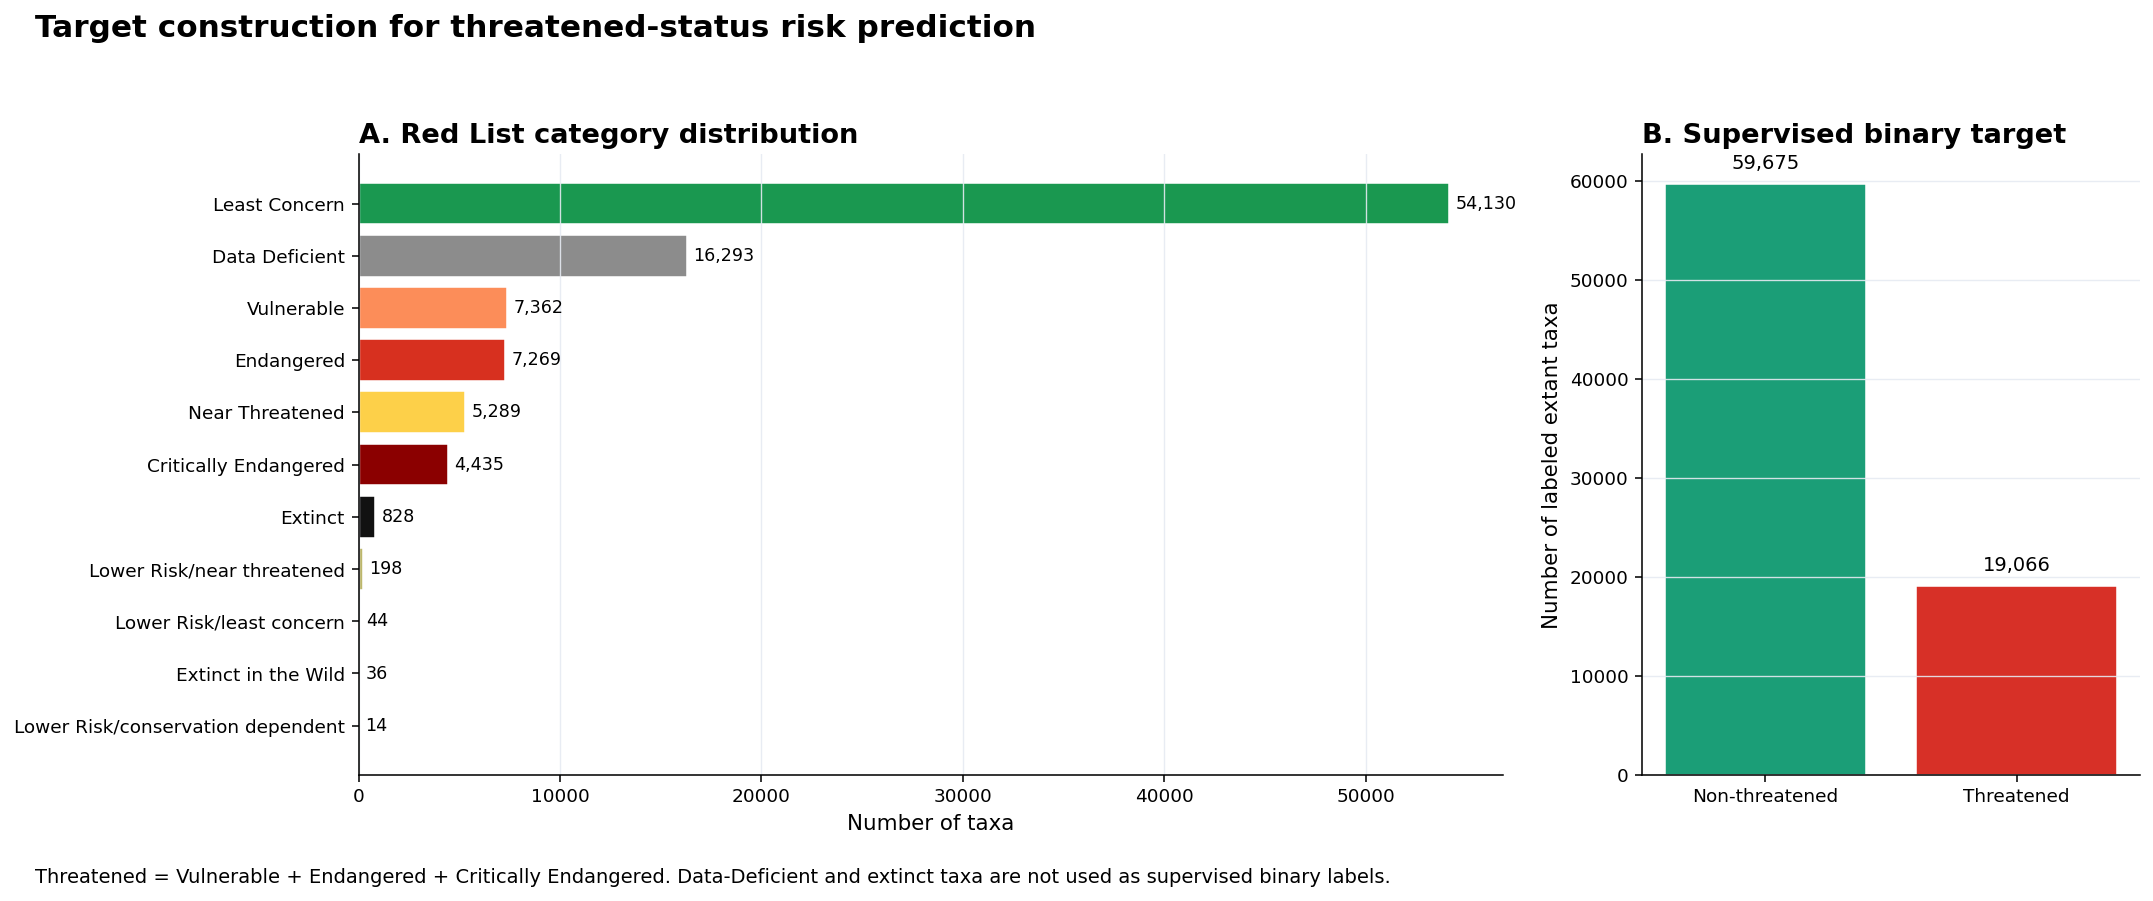

In [ ]:
# ================================================================
# CELL 7 | Figure 1: Red List category distribution and binary target
# ================================================================
cat_counts = (
    df["target_risk_category"].fillna("Missing")
      .value_counts()
      .rename_axis("risk_category")
      .reset_index(name="n_taxa")
)
cat_counts["color"] = cat_counts["risk_category"].map(IUCN_COLORS).fillna("#BFBFBF")
cat_counts = cat_counts.sort_values("n_taxa", ascending=True)

binary_counts = df[df[TARGET].notna()].copy()
binary_counts["binary_group"] = np.where(binary_counts[TARGET].astype(int).eq(1), "Threatened", "Non-threatened")
binary_summary = binary_counts["binary_group"].value_counts().reindex(["Non-threatened", "Threatened"]).reset_index()
binary_summary.columns = ["binary_group", "n_taxa"]

fig, axes = plt.subplots(1, 2, figsize=(15.5, 6.4), gridspec_kw={"width_ratios": [2.3, 1]})
ax = axes[0]
ax.barh(cat_counts["risk_category"], cat_counts["n_taxa"], color=cat_counts["color"], edgecolor="white", linewidth=0.8)
for y, n in enumerate(cat_counts["n_taxa"]):
    ax.text(n + max(cat_counts["n_taxa"]) * 0.006, y, f"{n:,}", va="center", fontsize=9)
ax.set_title("A. Red List category distribution", loc="left", fontweight="bold")
ax.set_xlabel("Number of taxa")
ax.set_ylabel("")
clean_axis(ax)

ax = axes[1]
ax.bar(binary_summary["binary_group"], binary_summary["n_taxa"],
       color=[GROUP_COLORS[g] for g in binary_summary["binary_group"]], edgecolor="white", linewidth=0.8)
for x, n in enumerate(binary_summary["n_taxa"]):
    ax.text(x, n + binary_summary["n_taxa"].max() * 0.025, f"{n:,}", ha="center", fontsize=10)
ax.set_title("B. Supervised binary target", loc="left", fontweight="bold")
ax.set_ylabel("Number of labeled extant taxa")
ax.set_xlabel("")
clean_axis(ax, grid_axis="y")

fig.suptitle("Target construction for threatened-status risk prediction", fontsize=16, fontweight="bold", x=0.02, ha="left")
fig.text(0.02, 0.01, "Threatened = Vulnerable + Endangered + Critically Endangered. Data-Deficient and extinct taxa are not used as supervised binary labels.", fontsize=10)
plt.tight_layout(rect=[0, 0.04, 1, 0.94])
save_pubfig(fig, "figure_01_target_distribution")
plt.show()

## 5. Leakage-safe feature sets
The final model excludes identifiers, target columns, leakage columns, threat labels, and action labels. Threat/action labels are used only later for descriptive context, not prediction.

# **CELL 8: BUILD STRICT LEAKAGE-SAFE FEATURE SETS**

In [ ]:
# ================================================================
# CELL 8 | Build strict leakage-safe feature sets
# ================================================================
ID_COLS = {"internalTaxonId", "assessmentId", "scientificName", "gbif_specieskey", "specieskey", "split"}
TARGET_OR_LEAK_PREFIXES = ("target_", "leak_")

STRICT_NO_GEO_FEATURES = [
    "phylum", "class", "order", "family", "genus",
    "is_infraspecific", "is_subpopulation", "functional_group",
    "feat_gbif_occurrence_count", "feat_gbif_coordinate_count", "feat_gbif_recent_10y_count",
    "feat_gbif_first_year", "feat_gbif_last_year", "feat_gbif_year_span",
    "feat_gbif_georef_fraction", "feat_gbif_recent_fraction", "feat_gbif_log_occurrence",
    "feat_gbif_name_candidate_count", "feat_has_gbif_occurrences", "feat_no_snapshot_occurrences",
    "feat_match_method", "feat_system_terrestrial", "feat_system_freshwater", "feat_system_marine",
    "feat_realm", "feat_assessment_year",
]
GEO_FEATURES = [
    "lat_mean", "lon_mean", "geo_n_coords", "country_iso2", "geo_has_coords", "geo_log_n_coords",
    "geo_abs_lat", "geo_lat_rad", "geo_lon_rad", "geo_lat_sin", "geo_lat_cos", "geo_lon_sin", "geo_lon_cos",
    "geo_hemisphere_ns", "geo_hemisphere_ew", "geo_lat_band", "geo_lon_zone",
]

STRICT_NO_GEO_FEATURES = [c for c in STRICT_NO_GEO_FEATURES if c in df_labeled.columns]
STRICT_GEO_FEATURES = [c for c in STRICT_NO_GEO_FEATURES + GEO_FEATURES if c in df_labeled.columns]

SAMPLING_PROXY_FEATURES = [
    "feat_gbif_occurrence_count", "feat_gbif_coordinate_count", "feat_gbif_recent_10y_count",
    "feat_gbif_first_year", "feat_gbif_last_year", "feat_gbif_year_span", "feat_gbif_georef_fraction",
    "feat_gbif_recent_fraction", "feat_gbif_log_occurrence", "feat_has_gbif_occurrences",
    "feat_no_snapshot_occurrences", "geo_n_coords", "geo_log_n_coords", "geo_has_coords"
]
ASSESSMENT_PROCESS_FEATURES = ["feat_assessment_year"]
STRICT_GEO_NO_SAMPLING_FEATURES = [c for c in STRICT_GEO_FEATURES if c not in set(SAMPLING_PROXY_FEATURES + ASSESSMENT_PROCESS_FEATURES)]

selected_features = STRICT_GEO_FEATURES
feature_set_name = "Strict geo-enhanced"

bad_features = [c for c in selected_features if c in ID_COLS or c.startswith(TARGET_OR_LEAK_PREFIXES)]
if bad_features:
    raise ValueError(f"Leakage/ID columns found in selected features: {bad_features}")

feature_set_summary = pd.DataFrame({
    "feature_set": ["Strict no geography", "Strict geo-enhanced", "No GBIF intensity / no assessment year"],
    "n_features": [len(STRICT_NO_GEO_FEATURES), len(STRICT_GEO_FEATURES), len(STRICT_GEO_NO_SAMPLING_FEATURES)]
})
display(feature_set_summary)
feature_set_summary.to_csv(TABLE_DIR / "feature_set_summary.csv", index=False)

print("Selected final feature set:", feature_set_name)
print("Selected feature count:", len(selected_features))
print("\nSelected features:")
for c in selected_features:
    print(" -", c)

,feature_set,n_features
0,Strict no geography,26
1,Strict geo-enhanced,43
2,No GBIF intensity / no assessment year,28


Selected final feature set: Strict geo-enhanced
Selected feature count: 43

Selected features:
 - phylum
 - class
 - order
 - family
 - genus
 - is_infraspecific
 - is_subpopulation
 - functional_group
 - feat_gbif_occurrence_count
 - feat_gbif_coordinate_count
 - feat_gbif_recent_10y_count
 - feat_gbif_first_year
 - feat_gbif_last_year
 - feat_gbif_year_span
 - feat_gbif_georef_fraction
 - feat_gbif_recent_fraction
 - feat_gbif_log_occurrence
 - feat_gbif_name_candidate_count
 - feat_has_gbif_occurrences
 - feat_no_snapshot_occurrences
 - feat_match_method
 - feat_system_terrestrial
 - feat_system_freshwater
 - feat_system_marine
 - feat_realm
 - feat_assessment_year
 - lat_mean
 - lon_mean
 - geo_n_coords
 - country_iso2
 - geo_has_coords
 - geo_log_n_coords
 - geo_abs_lat
 - geo_lat_rad
 - geo_lon_rad
 - geo_lat_sin
 - geo_lat_cos
 - geo_lon_sin
 - geo_lon_cos
 - geo_hemisphere_ns
 - geo_hemisphere_ew
 - geo_lat_band
 - geo_lon_zone


# **CELL 9: PREPARE TRAIN, VALIDATION, TEST, AND DATA-DEFICIENT MATRICES**

In [ ]:
# =====================================================================
# CELL 9 | Prepare train, validation, test, and Data-Deficient matrices
# =====================================================================
valid_splits = {"train", "val", "test"}
missing_splits = valid_splits - set(df_labeled[SPLIT_COL].dropna().unique())
if missing_splits:
    raise ValueError(f"Missing expected split values: {missing_splits}")

train_df = df_labeled[df_labeled[SPLIT_COL].eq("train")].copy()
val_df = df_labeled[df_labeled[SPLIT_COL].eq("val")].copy()
test_df = df_labeled[df_labeled[SPLIT_COL].eq("test")].copy()

X_train = train_df[selected_features].copy()
y_train = train_df[TARGET].astype(int)
X_val = val_df[selected_features].copy()
y_val = val_df[TARGET].astype(int)
X_test = test_df[selected_features].copy()
y_test = test_df[TARGET].astype(int)
X_dd = df_dd[selected_features].copy() if len(df_dd) else pd.DataFrame(columns=selected_features)

split_model_audit = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n": [len(y_train), len(y_val), len(y_test)],
    "n_threatened": [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
    "threatened_rate": [float(y_train.mean()), float(y_val.mean()), float(y_test.mean())],
})
display(split_model_audit)
split_model_audit.to_csv(TABLE_DIR / "model_split_audit.csv", index=False)

print("Train:", X_train.shape, "positive rate:", round(y_train.mean(), 4))
print("Validation:", X_val.shape, "positive rate:", round(y_val.mean(), 4))
print("Test:", X_test.shape, "positive rate:", round(y_test.mean(), 4))
print("Data-Deficient scoring matrix:", X_dd.shape)

,split,n,n_threatened,threatened_rate
0,train,54741,13411,0.244990
1,validation,11866,2911,0.245323
2,test,12134,2744,0.226141


Train: (54741, 43) positive rate: 0.245
Validation: (11866, 43) positive rate: 0.2453
Test: (12134, 43) positive rate: 0.2261
Data-Deficient scoring matrix: (16293, 43)


## 6. Preprocessing and model benchmark
LightGBM is the primary final model. Other models are retained only as transparent benchmarks.

# **CELL 10: CREATE PREPROCESSING PIPELINE AND DEFINE BENCHMARK MODELS**

In [ ]:
# ================================================================
# CELL 10 | Create preprocessing pipeline and benchmark models
# ================================================================
numeric_features = [c for c in selected_features if pd.api.types.is_numeric_dtype(df_labeled[c])]
categorical_features = [c for c in selected_features if c not in numeric_features]

print("Numeric features:", len(numeric_features))
print(numeric_features)
print("\nCategorical features:", len(categorical_features))
print(categorical_features)

def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=10, sparse_output=True)
    except TypeError:
        try:
            return OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=10, sparse=True)
        except TypeError:
            return OneHotEncoder(handle_unknown="ignore", sparse=True)


def make_preprocessor(num_cols=None, cat_cols=None):
    if num_cols is None:
        num_cols = numeric_features
    if cat_cols is None:
        cat_cols = categorical_features
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imp", SimpleImputer(strategy="median")),
                ("scale", MaxAbsScaler())
            ]), num_cols),
            ("cat", Pipeline([
                ("imp", SimpleImputer(strategy="constant", fill_value="Missing")),
                ("ohe", make_ohe())
            ]), cat_cols),
        ],
        remainder="drop",
        sparse_threshold=0.3
    )

neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
scale_pos_weight = neg / max(pos, 1)
print("Training negatives:", neg)
print("Training positives:", pos)
print("scale_pos_weight:", round(scale_pos_weight, 3))


def make_primary_lightgbm(num_cols=None, cat_cols=None):
    return Pipeline([
        ("pre", make_preprocessor(num_cols, cat_cols)),
        ("clf", LGBMClassifier(
            n_estimators=900,
            learning_rate=0.025,
            num_leaves=48,
            min_child_samples=35,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=3.0,
            class_weight="balanced",
            objective="binary",
            n_jobs=-1,
            random_state=RANDOM_STATE,
            verbose=-1,
        ))
    ])


def make_benchmark_models(num_cols=None, cat_cols=None):
    if num_cols is None:
        num_cols = numeric_features
    if cat_cols is None:
        cat_cols = categorical_features
    pre = lambda: make_preprocessor(num_cols, cat_cols)
    return {
        "ElasticNet Logistic": Pipeline([
            ("pre", pre()),
            ("clf", LogisticRegression(
                penalty="elasticnet", solver="saga", l1_ratio=0.15,
                C=0.7, class_weight="balanced", max_iter=2500,
                n_jobs=-1, random_state=RANDOM_STATE
            ))
        ]),
        "ExtraTrees": Pipeline([
            ("pre", pre()),
            ("clf", ExtraTreesClassifier(
                n_estimators=600, max_features="sqrt", min_samples_leaf=2,
                class_weight="balanced_subsample", n_jobs=-1,
                random_state=RANDOM_STATE
            ))
        ]),
        "XGBoost": Pipeline([
            ("pre", pre()),
            ("clf", XGBClassifier(
                n_estimators=650, max_depth=5, learning_rate=0.035,
                subsample=0.85, colsample_bytree=0.85,
                reg_lambda=3.0, reg_alpha=0.2,
                scale_pos_weight=scale_pos_weight,
                eval_metric="logloss", tree_method="hist",
                n_jobs=-1, random_state=RANDOM_STATE
            ))
        ]),
        "LightGBM": make_primary_lightgbm(num_cols, cat_cols),
        "CatBoost": Pipeline([
            ("pre", pre()),
            ("clf", CatBoostClassifier(
                iterations=850, depth=6, learning_rate=0.035,
                loss_function="Logloss", eval_metric="AUC",
                auto_class_weights="Balanced", random_seed=RANDOM_STATE,
                verbose=False, allow_writing_files=False
            ))
        ]),
    }

benchmark_models = make_benchmark_models()
PRIMARY_MODEL_NAME = "LightGBM"
print("Primary final model:", PRIMARY_MODEL_NAME)
print("Benchmark models:")
for name in benchmark_models:
    print(" -", name)

Numeric features: 30
['is_infraspecific', 'is_subpopulation', 'feat_gbif_occurrence_count', 'feat_gbif_coordinate_count', 'feat_gbif_recent_10y_count', 'feat_gbif_first_year', 'feat_gbif_last_year', 'feat_gbif_year_span', 'feat_gbif_georef_fraction', 'feat_gbif_recent_fraction', 'feat_gbif_log_occurrence', 'feat_gbif_name_candidate_count', 'feat_has_gbif_occurrences', 'feat_no_snapshot_occurrences', 'feat_system_terrestrial', 'feat_system_freshwater', 'feat_system_marine', 'feat_assessment_year', 'lat_mean', 'lon_mean', 'geo_n_coords', 'geo_has_coords', 'geo_log_n_coords', 'geo_abs_lat', 'geo_lat_rad', 'geo_lon_rad', 'geo_lat_sin', 'geo_lat_cos', 'geo_lon_sin', 'geo_lon_cos']

Categorical features: 13
['phylum', 'class', 'order', 'family', 'genus', 'functional_group', 'feat_match_method', 'feat_realm', 'country_iso2', 'geo_hemisphere_ns', 'geo_hemisphere_ew', 'geo_lat_band', 'geo_lon_zone']
Training negatives: 41330
Training positives: 13411
scale_pos_weight: 3.082
Primary final model:

# **CELL 11: TRAIN BENCHMARK MODELS AND SELECT PRIMARY LIGHTGBM MODEL**

In [ ]:
# ================================================================
# CELL 11 | Benchmark models and select LightGBM as primary model
# ================================================================
fitted_models = {}
pred_val = {}
pred_test = {}
leaderboard_rows = []

for name, model in benchmark_models.items():
    print(f"\nTraining {name}...")
    try:
        model.fit(X_train, y_train)
        pv = model.predict_proba(X_val)[:, 1]
        pt = model.predict_proba(X_test)[:, 1]
        fitted_models[name] = model
        pred_val[name] = pv
        pred_test[name] = pt
        row = {
            "model": name,
            "val_roc_auc": roc_auc_score(y_val, pv),
            "val_pr_auc": average_precision_score(y_val, pv),
            "val_brier": brier_score_loss(y_val, pv),
            "test_roc_auc": roc_auc_score(y_test, pt),
            "test_pr_auc": average_precision_score(y_test, pt),
            "test_brier": brier_score_loss(y_test, pt),
        }
        leaderboard_rows.append(row)
        print(f" Validation PR-AUC: {row['val_pr_auc']:.4f}; Test PR-AUC: {row['test_pr_auc']:.4f}")
    except Exception as e:
        print(f" {name} failed: {e}")

leaderboard = pd.DataFrame(leaderboard_rows).sort_values("val_pr_auc", ascending=False).reset_index(drop=True)
if leaderboard.empty:
    raise RuntimeError("No models trained successfully.")

display(leaderboard)
leaderboard.to_csv(TABLE_DIR / "model_benchmark_leaderboard.csv", index=False)

if PRIMARY_MODEL_NAME not in fitted_models:
    raise RuntimeError(f"Primary model {PRIMARY_MODEL_NAME} did not train successfully.")

primary_model = fitted_models[PRIMARY_MODEL_NAME]
primary_val_score = pred_val[PRIMARY_MODEL_NAME]
primary_test_score = pred_test[PRIMARY_MODEL_NAME]

best_by_val = leaderboard.iloc[0]["model"]
if best_by_val != PRIMARY_MODEL_NAME:
    print(f"Note: {best_by_val} had the highest validation PR-AUC in this run. Review before manuscript finalization.")
else:
    print("LightGBM is the top validation PR-AUC model in this run and is retained as the primary model.")


Training ElasticNet Logistic...
 Validation PR-AUC: 0.5511; Test PR-AUC: 0.4910

Training ExtraTrees...
 Validation PR-AUC: 0.6292; Test PR-AUC: 0.5753

Training XGBoost...
 Validation PR-AUC: 0.6812; Test PR-AUC: 0.6004

Training LightGBM...
 Validation PR-AUC: 0.7056; Test PR-AUC: 0.6351

Training CatBoost...
 Validation PR-AUC: 0.6917; Test PR-AUC: 0.6099


,model,val_roc_auc,val_pr_auc,val_brier,test_roc_auc,test_pr_auc,test_brier
0,LightGBM,0.868388,0.705560,0.143608,0.858068,0.635051,0.152462
1,CatBoost,0.859451,0.691737,0.148191,0.846507,0.609888,0.158034
2,XGBoost,0.852969,0.681190,0.150859,0.840448,0.600388,0.159902
3,ExtraTrees,0.841824,0.629228,0.149107,0.833571,0.575313,0.152634
4,ElasticNet Logistic,0.793669,0.551138,0.197722,0.791632,0.491021,0.207853


LightGBM is the top validation PR-AUC model in this run and is retained as the primary model.


# **CELL 12: MODEL BENCHMARK LEADERBOARD**

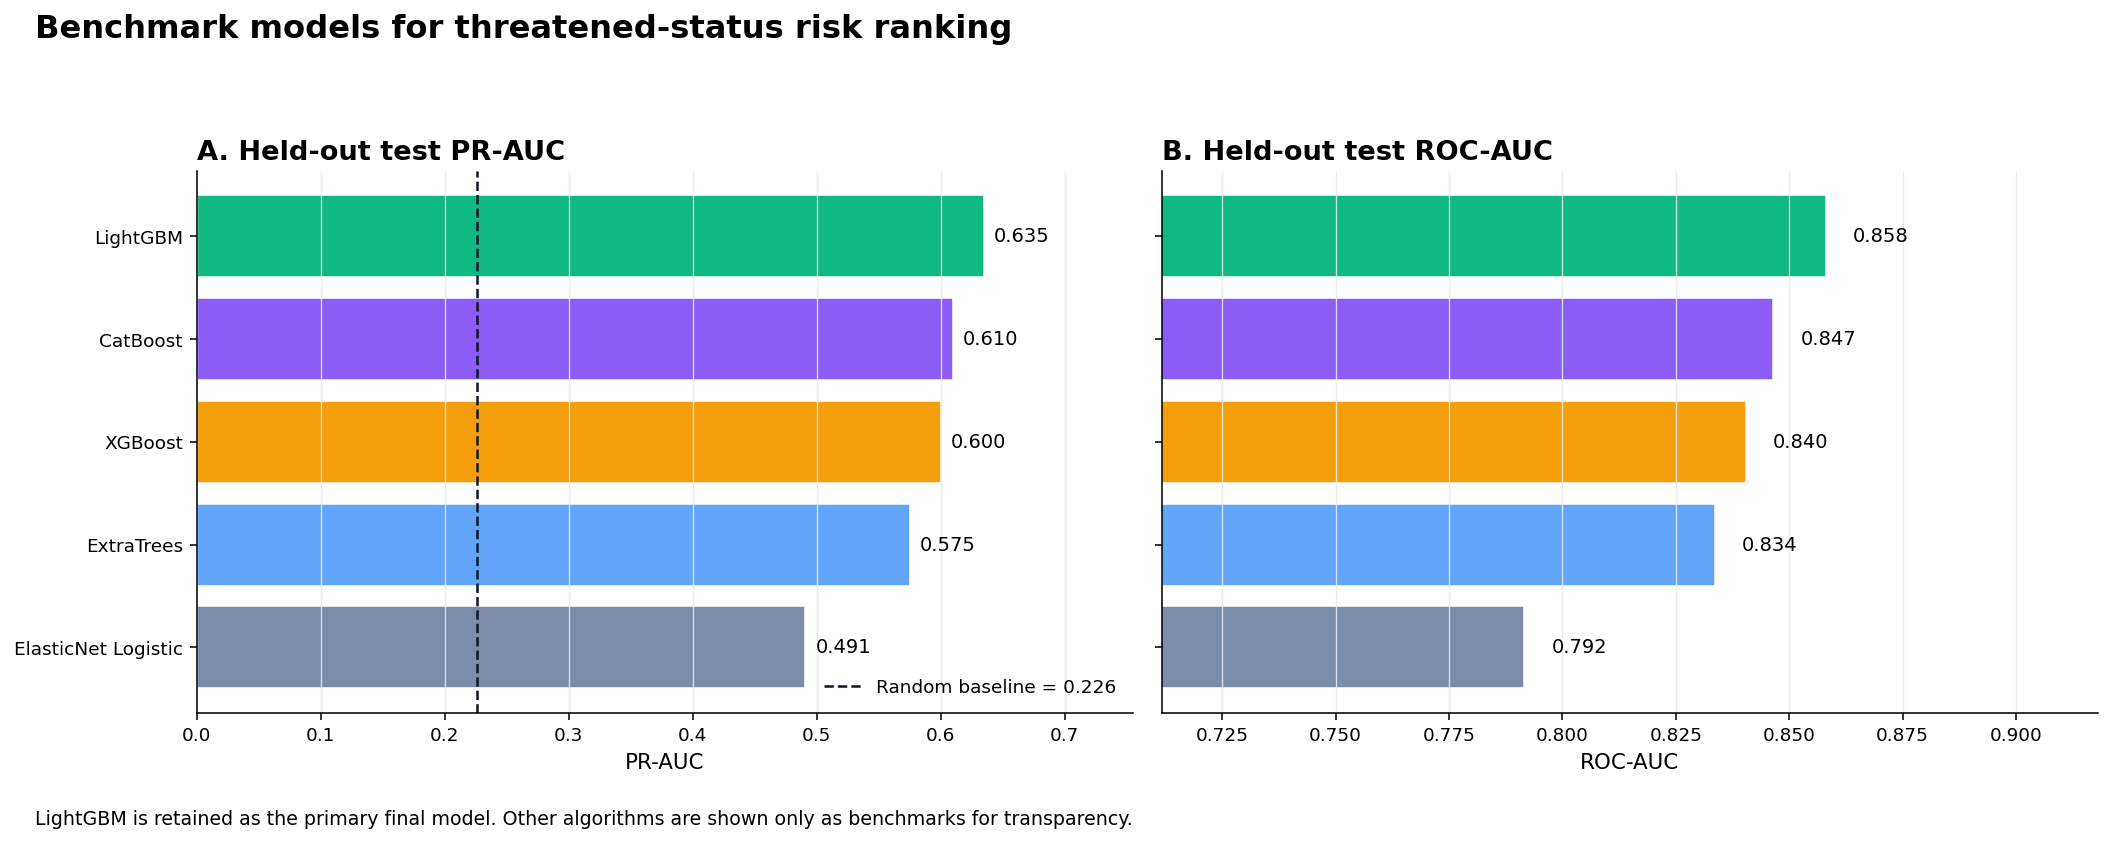

In [ ]:
# ================================================================
# CELL 12 | Figure 2: Model benchmark leaderboard
# ================================================================
plot_df = leaderboard.sort_values("test_pr_auc", ascending=True).copy()
random_pr_baseline = float(y_test.mean())

fig, axes = plt.subplots(1, 2, figsize=(15.2, 6.0), gridspec_kw={"width_ratios": [1, 1]})

ax = axes[0]
colors = [MODEL_COLORS.get(m, "#9CA3AF") for m in plot_df["model"]]
ax.barh(plot_df["model"], plot_df["test_pr_auc"], color=colors, edgecolor="white", linewidth=0.8)
ax.axvline(random_pr_baseline, color="#111827", linestyle="--", linewidth=1.3, label=f"Random baseline = {random_pr_baseline:.3f}")
for y, v in enumerate(plot_df["test_pr_auc"]):
    ax.text(v + 0.008, y, f"{v:.3f}", va="center", fontsize=10)
ax.set_title("A. Held-out test PR-AUC", loc="left", fontweight="bold")
ax.set_xlabel("PR-AUC")
ax.set_xlim(0, min(1.0, plot_df["test_pr_auc"].max() + 0.12))
ax.legend(frameon=False, loc="lower right")
clean_axis(ax)

ax = axes[1]
ax.barh(plot_df["model"], plot_df["test_roc_auc"], color=colors, edgecolor="white", linewidth=0.8)
for y, v in enumerate(plot_df["test_roc_auc"]):
    ax.text(v + 0.006, y, f"{v:.3f}", va="center", fontsize=10)
ax.set_title("B. Held-out test ROC-AUC", loc="left", fontweight="bold")
ax.set_xlabel("ROC-AUC")
ax.set_xlim(max(0.5, plot_df["test_roc_auc"].min() - 0.08), min(1.0, plot_df["test_roc_auc"].max() + 0.06))
ax.set_yticklabels([])
clean_axis(ax)

fig.suptitle("Benchmark models for threatened-status risk ranking", fontsize=16.5, fontweight="bold", x=0.02, ha="left")
fig.text(0.02, 0.015, "LightGBM is retained as the primary final model. Other algorithms are shown only as benchmarks for transparency.", fontsize=9.8)
plt.tight_layout(rect=[0, 0.05, 1, 0.92])
save_pubfig(fig, "figure_02_model_benchmark_leaderboard")
plt.show()

## 7. Primary LightGBM evaluation, calibration, threshold, and bootstrap uncertainty
Ranking metrics use the raw LightGBM score. Calibration is used for calibration curves and threshold-based risk stratification, not as a claim of literal extinction probability. The held-out test split is the primary performance estimate because the validation split is used for model selection, calibration, and threshold selection.

# **CELL 13: PRIMARY MODEL PERFORMANCE, CALIBRATION, AND THRESHOLD SELECTION**

In [ ]:
# ================================================================
# CELL 13 | Primary model performance, calibration, and threshold
# ================================================================
calibrator = IsotonicRegression(out_of_bounds="clip")
calibrator.fit(primary_val_score, y_val)
primary_val_cal = calibrator.transform(primary_val_score)
primary_test_cal = calibrator.transform(primary_test_score)

primary_metric_rows = [
    {
        "model": PRIMARY_MODEL_NAME,
        "score_type": "raw ranking score",
        "split": "validation",
        "roc_auc": roc_auc_score(y_val, primary_val_score),
        "pr_auc": average_precision_score(y_val, primary_val_score),
        "brier": brier_score_loss(y_val, primary_val_score),
    },
    {
        "model": PRIMARY_MODEL_NAME,
        "score_type": "isotonic-calibrated score",
        "split": "validation",
        "roc_auc": roc_auc_score(y_val, primary_val_cal),
        "pr_auc": average_precision_score(y_val, primary_val_cal),
        "brier": brier_score_loss(y_val, primary_val_cal),
    },
    {
        "model": PRIMARY_MODEL_NAME,
        "score_type": "raw ranking score",
        "split": "test",
        "roc_auc": roc_auc_score(y_test, primary_test_score),
        "pr_auc": average_precision_score(y_test, primary_test_score),
        "brier": brier_score_loss(y_test, primary_test_score),
    },
    {
        "model": PRIMARY_MODEL_NAME,
        "score_type": "isotonic-calibrated score",
        "split": "test",
        "roc_auc": roc_auc_score(y_test, primary_test_cal),
        "pr_auc": average_precision_score(y_test, primary_test_cal),
        "brier": brier_score_loss(y_test, primary_test_cal),
    },
]
primary_metrics = pd.DataFrame(primary_metric_rows)
display(primary_metrics)
primary_metrics.to_csv(TABLE_DIR / "primary_lightgbm_raw_vs_calibrated_metrics.csv", index=False)

# Threshold selection is done on validation data using calibrated scores.
precision, recall, thresholds = precision_recall_curve(y_val, primary_val_cal)
p_thr = precision[:-1]
r_thr = recall[:-1]
beta = 2
f2 = (1 + beta**2) * p_thr * r_thr / (beta**2 * p_thr + r_thr + 1e-12)
best_idx = int(np.nanargmax(f2))
BEST_F2_THRESHOLD = float(thresholds[best_idx])

# A second high-recall option is reported for conservation triage.
target_recall = 0.85
eligible = np.where(r_thr >= target_recall)[0]
if len(eligible):
    high_recall_idx = int(eligible[np.argmax(p_thr[eligible])])
    HIGH_RECALL_THRESHOLD = float(thresholds[high_recall_idx])
else:
    HIGH_RECALL_THRESHOLD = BEST_F2_THRESHOLD

FINAL_THRESHOLD = BEST_F2_THRESHOLD

def metrics_at_threshold(y, score, thr):
    pred = (score >= thr).astype(int)
    p = precision_score(y, pred, zero_division=0)
    r = recall_score(y, pred, zero_division=0)
    f1 = f1_score(y, pred, zero_division=0)
    f2v = (1 + beta**2) * p * r / (beta**2 * p + r + 1e-12)
    return p, r, f1, f2v

threshold_rows = []
for name, thr in [
    ("Best F2 threshold", BEST_F2_THRESHOLD),
    ("High-recall threshold target 0.85", HIGH_RECALL_THRESHOLD),
    ("Conventional 0.50 threshold", 0.50),
]:
    p, r, f1, f2v = metrics_at_threshold(y_val, primary_val_cal, thr)
    threshold_rows.append({"threshold_name": name, "threshold": thr, "validation_precision": p, "validation_recall": r, "validation_f1": f1, "validation_f2": f2v})

threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table)
threshold_table.to_csv(TABLE_DIR / "validation_threshold_selection_lightgbm.csv", index=False)
print("FINAL_THRESHOLD selected for triage:", FINAL_THRESHOLD)

,model,score_type,split,roc_auc,pr_auc,brier
0,LightGBM,raw ranking score,validation,0.868388,0.705560,0.143608
1,LightGBM,isotonic-calibrated score,validation,0.869947,0.694062,0.116843
2,LightGBM,raw ranking score,test,0.858068,0.635051,0.152462
3,LightGBM,isotonic-calibrated score,test,0.856852,0.615904,0.121433


,threshold_name,threshold,validation_precision,validation_recall,validation_f1,validation_f2
0,Best F2 threshold,0.200000,0.492816,0.860186,0.626627,0.748580
1,High-recall threshold target 0.85,0.212885,0.493105,0.859842,0.626768,0.748505
2,Conventional 0.50 threshold,0.500000,0.721791,0.542769,0.619608,0.571098


FINAL_THRESHOLD selected for triage: 0.2


# **CELL 14: FINAL HELD-OUT TEST CLASSIFICATION AND BOOTSTRAP UNCERTAINTY**

In [ ]:
# ================================================================
# CELL 14 | Final held-out test classification and bootstrap CIs
# ================================================================
test_pred_label = (primary_test_cal >= FINAL_THRESHOLD).astype(int)
print("Final threshold:", FINAL_THRESHOLD)
print("\nClassification report on untouched test set:")
print(classification_report(y_test, test_pred_label, digits=4))

cm = confusion_matrix(y_test, test_pred_label)
cm_df = pd.DataFrame(
    cm,
    index=["Observed not threatened", "Observed threatened"],
    columns=["Predicted not threatened", "Predicted threatened"]
)
display(cm_df)

final_test_summary = pd.DataFrame([{
    "model": PRIMARY_MODEL_NAME,
    "threshold": FINAL_THRESHOLD,
    "test_roc_auc_raw": roc_auc_score(y_test, primary_test_score),
    "test_pr_auc_raw": average_precision_score(y_test, primary_test_score),
    "test_brier_raw": brier_score_loss(y_test, primary_test_score),
    "test_roc_auc_calibrated": roc_auc_score(y_test, primary_test_cal),
    "test_pr_auc_calibrated": average_precision_score(y_test, primary_test_cal),
    "test_brier_calibrated": brier_score_loss(y_test, primary_test_cal),
    "test_precision_at_threshold": precision_score(y_test, test_pred_label, zero_division=0),
    "test_recall_at_threshold": recall_score(y_test, test_pred_label, zero_division=0),
    "test_f1_at_threshold": f1_score(y_test, test_pred_label, zero_division=0),
    "test_n": len(y_test),
    "test_positive_rate": y_test.mean(),
}])
display(final_test_summary)
final_test_summary.to_csv(TABLE_DIR / "final_lightgbm_test_metrics.csv", index=False)
cm_df.to_csv(TABLE_DIR / "final_lightgbm_test_confusion_matrix.csv")

# Bootstrap confidence intervals for main test metrics.
def bootstrap_ci(y, score, metric_func, n_boot=1000, seed=RANDOM_STATE):
    y = np.asarray(y)
    score = np.asarray(score)
    rng = np.random.default_rng(seed)
    vals = []
    n = len(y)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        if len(np.unique(y[idx])) < 2:
            continue
        vals.append(metric_func(y[idx], score[idx]))
    vals = np.asarray(vals)
    return {
        "estimate": metric_func(y, score),
        "ci_lower": float(np.percentile(vals, 2.5)),
        "ci_upper": float(np.percentile(vals, 97.5)),
        "n_boot_used": int(len(vals))
    }

N_BOOTSTRAP = 1000
ci_rows = []
for metric_name, score, func in [
    ("ROC-AUC raw", primary_test_score, roc_auc_score),
    ("PR-AUC raw", primary_test_score, average_precision_score),
    ("Brier raw", primary_test_score, brier_score_loss),
    ("ROC-AUC calibrated", primary_test_cal, roc_auc_score),
    ("PR-AUC calibrated", primary_test_cal, average_precision_score),
    ("Brier calibrated", primary_test_cal, brier_score_loss),
]:
    out = bootstrap_ci(y_test, score, func, n_boot=N_BOOTSTRAP)
    out["metric"] = metric_name
    ci_rows.append(out)

bootstrap_ci_table = pd.DataFrame(ci_rows)[["metric", "estimate", "ci_lower", "ci_upper", "n_boot_used"]]
display(bootstrap_ci_table)
bootstrap_ci_table.to_csv(TABLE_DIR / "bootstrap_ci_primary_lightgbm_test_metrics.csv", index=False)

Final threshold: 0.2

Classification report on untouched test set:
              precision    recall  f1-score   support

           0     0.9433    0.6820    0.7916      9390
           1     0.4413    0.8597    0.5833      2744

    accuracy                         0.7222     12134
   macro avg     0.6923    0.7708    0.6875     12134
weighted avg     0.8298    0.7222    0.7445     12134



,Predicted not threatened,Predicted threatened
Observed not threatened,6404,2986
Observed threatened,385,2359


,model,threshold,test_roc_auc_raw,test_pr_auc_raw,test_brier_raw,test_roc_auc_calibrated,test_pr_auc_calibrated,test_brier_calibrated,test_precision_at_threshold,test_recall_at_threshold,test_f1_at_threshold,test_n,test_positive_rate
0,LightGBM,0.2,0.858068,0.635051,0.152462,0.856852,0.615904,0.121433,0.441347,0.859694,0.583261,12134,0.226141


,metric,estimate,ci_lower,ci_upper,n_boot_used
0,ROC-AUC raw,0.858068,0.851002,0.865545,1000
1,PR-AUC raw,0.635051,0.616495,0.655858,1000
2,Brier raw,0.152462,0.148553,0.156146,1000
3,ROC-AUC calibrated,0.856852,0.849694,0.864283,1000
4,PR-AUC calibrated,0.615904,0.597737,0.635484,1000
5,Brier calibrated,0.121433,0.117609,0.124809,1000


# **CELL 15: ROC CURVE, PRECISION–RECALL CURVE, CALIBRATION, AND CONFUSION MATRIX**

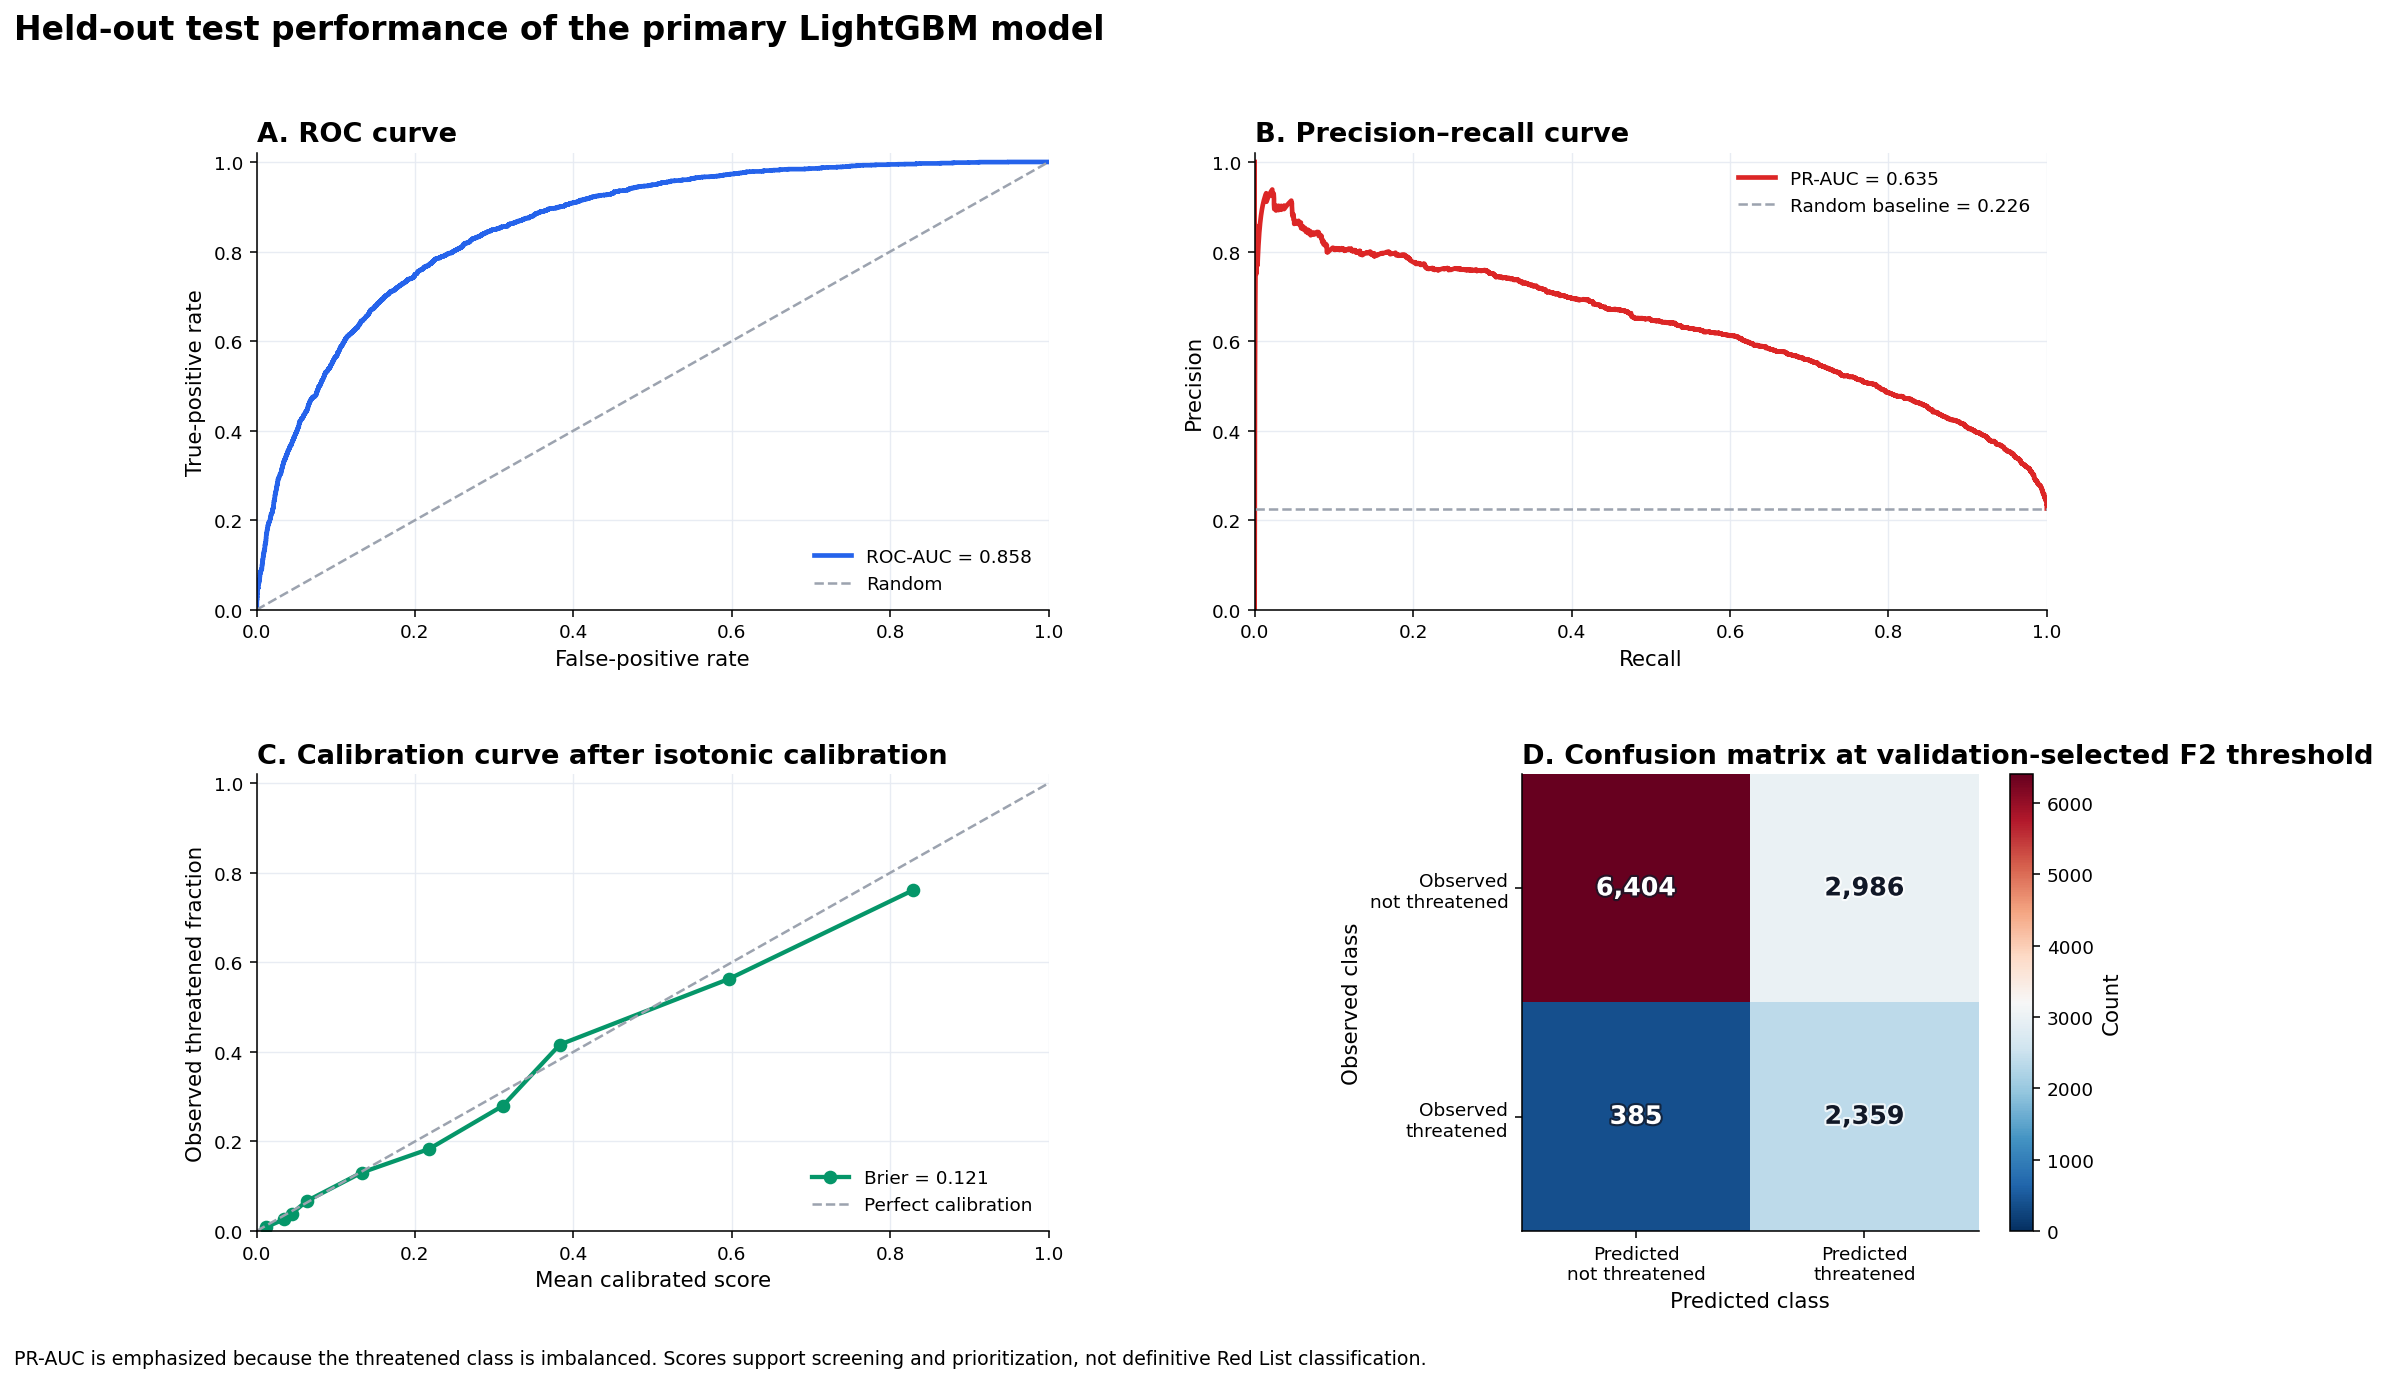

In [ ]:
# ================================================================
# CELL 15 | Figure 3: ROC, PR, calibration, and confusion matrix
# ================================================================

import matplotlib.patheffects as pe

fpr, tpr, _ = roc_curve(y_test, primary_test_score)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, primary_test_score)

roc_auc = roc_auc_score(y_test, primary_test_score)
pr_auc = average_precision_score(y_test, primary_test_score)
baseline_pr = float(y_test.mean())

frac_pos, mean_pred = calibration_curve(
    y_test,
    primary_test_cal,
    n_bins=10,
    strategy="quantile"
)

fig = plt.figure(figsize=(16.5, 10.0))
gs = fig.add_gridspec(2, 2, wspace=0.26, hspace=0.36)

# ------------------------------------------------------------
# A. ROC curve
# ------------------------------------------------------------
ax = fig.add_subplot(gs[0, 0])

ax.plot(
    fpr,
    tpr,
    linewidth=2.4,
    color="#2563EB",
    label=f"ROC-AUC = {roc_auc:.3f}"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="#9CA3AF",
    linewidth=1.3,
    label="Random"
)

ax.set_title("A. ROC curve", loc="left", fontweight="bold")
ax.set_xlabel("False-positive rate")
ax.set_ylabel("True-positive rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.legend(frameon=False, loc="lower right")

# ------------------------------------------------------------
# B. Precision–recall curve
# ------------------------------------------------------------
ax = fig.add_subplot(gs[0, 1])

ax.plot(
    rec_curve,
    prec_curve,
    linewidth=2.4,
    color="#DC2626",
    label=f"PR-AUC = {pr_auc:.3f}"
)

ax.axhline(
    baseline_pr,
    linestyle="--",
    color="#9CA3AF",
    linewidth=1.3,
    label=f"Random baseline = {baseline_pr:.3f}"
)

ax.set_title("B. Precision–recall curve", loc="left", fontweight="bold")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.legend(frameon=False, loc="upper right")

# ------------------------------------------------------------
# C. Calibration curve
# ------------------------------------------------------------
ax = fig.add_subplot(gs[1, 0])

ax.plot(
    mean_pred,
    frac_pos,
    marker="o",
    linewidth=2.2,
    color="#059669",
    label=f"Brier = {brier_score_loss(y_test, primary_test_cal):.3f}"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="#9CA3AF",
    linewidth=1.3,
    label="Perfect calibration"
)

ax.set_title("C. Calibration curve after isotonic calibration", loc="left", fontweight="bold")
ax.set_xlabel("Mean calibrated score")
ax.set_ylabel("Observed threatened fraction")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.legend(frameon=False, loc="lower right")

# ------------------------------------------------------------
# D. Confusion matrix
# ------------------------------------------------------------
ax = fig.add_subplot(gs[1, 1])

im = ax.imshow(
    cm,
    cmap="RdBu_r",
    vmin=0,
    vmax=cm.max()
)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    "Predicted\nnot threatened",
    "Predicted\nthreatened"
])

ax.set_yticklabels([
    "Observed\nnot threatened",
    "Observed\nthreatened"
])

# Choose annotation color from actual cell background luminance
for i in range(2):
    for j in range(2):
        value = cm[i, j]

        rgba = im.cmap(im.norm(value))
        r, g, b, _ = rgba

        # Perceptual luminance: higher value = lighter background
        luminance = 0.299 * r + 0.587 * g + 0.114 * b

        if luminance < 0.50:
            text_color = "white"
            stroke_color = "#111827"
        else:
            text_color = "#111827"
            stroke_color = "white"

        ax.text(
            j,
            i,
            f"{value:,}",
            ha="center",
            va="center",
            fontsize=13,
            fontweight="bold",
            color=text_color,
            path_effects=[
                pe.withStroke(linewidth=2.2, foreground=stroke_color, alpha=0.75)
            ]
        )

ax.set_title(
    "D. Confusion matrix at validation-selected F2 threshold",
    loc="left",
    fontweight="bold"
)

ax.set_xlabel("Predicted class")
ax.set_ylabel("Observed class")
ax.grid(False)

fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.04,
    label="Count"
)

fig.suptitle(
    "Held-out test performance of the primary LightGBM model",
    fontsize=17,
    fontweight="bold",
    x=0.02,
    ha="left"
)

fig.text(
    0.02,
    0.015,
    "PR-AUC is emphasized because the threatened class is imbalanced. "
    "Scores support screening and prioritization, not definitive Red List classification.",
    fontsize=9.8
)

plt.tight_layout(rect=[0, 0.04, 1, 0.94])

save_pubfig(fig, "figure_03_primary_lightgbm_test_performance")

plt.show()

## 8. Sensitivity and generalization audits
These checks evaluate whether GBIF sampling, geography, taxonomy, and assessment-process variables influence model performance and interpretation.

# **CELL 16: FEATURE-SET SENSITIVITY AUDIT**

,feature_set,n_features,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_brier,delta_test_pr_auc_vs_main,delta_test_roc_auc_vs_main
0,Main geo-enhanced,43,0.868388,0.705560,0.858068,0.635051,0.152462,0.000000,0.000000
1,No geography,26,0.850190,0.677236,0.840224,0.589710,0.168681,-0.045341,-0.017844
2,No assessment year,42,0.853755,0.672676,0.843800,0.593414,0.163251,-0.041638,-0.014268
3,No GBIF intensity or assessment year,28,0.816097,0.621015,0.806712,0.545473,0.179496,-0.089578,-0.051356


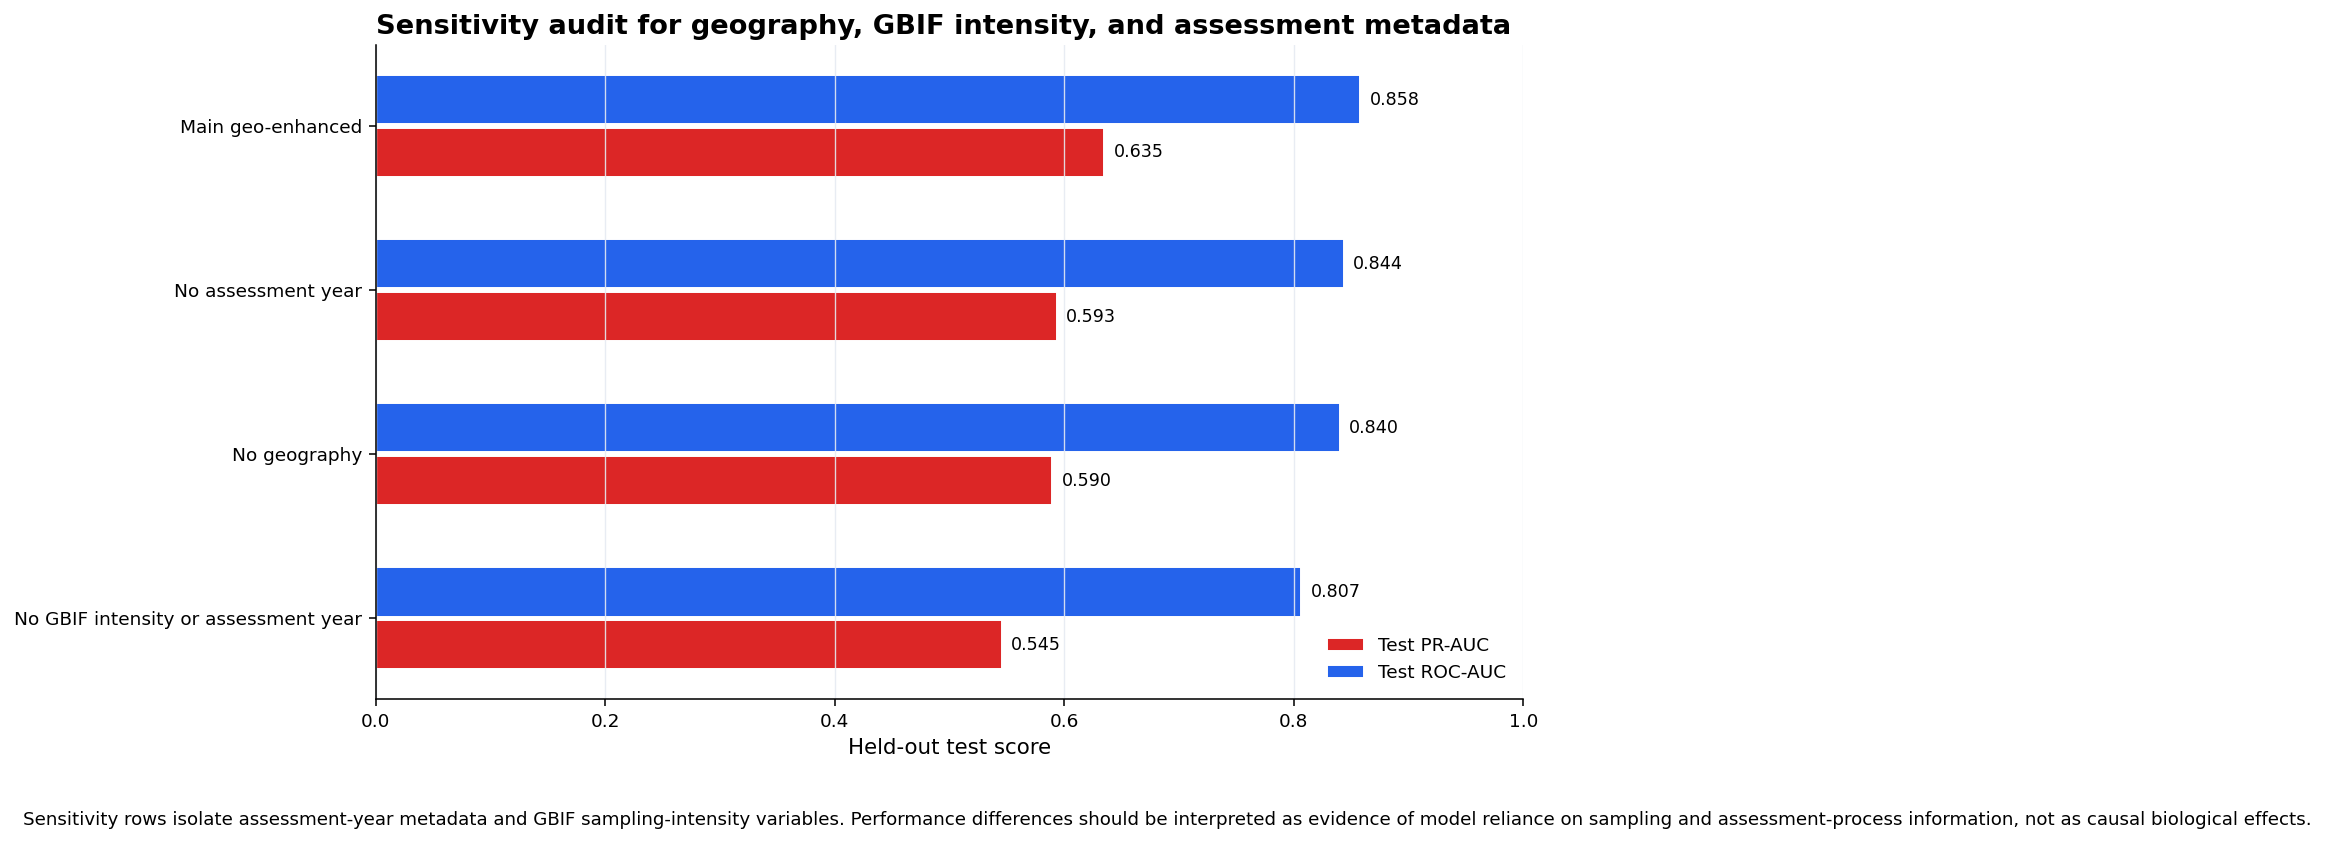

In [ ]:
# ================================================================
# CELL 16 | Feature-set sensitivity audit
# ================================================================
def quick_eval_lightgbm(feature_list, label):
    num_cols = [c for c in feature_list if pd.api.types.is_numeric_dtype(df_labeled[c])]
    cat_cols = [c for c in feature_list if c not in num_cols]
    pipe = make_primary_lightgbm(num_cols, cat_cols)
    pipe.fit(train_df[feature_list].copy(), y_train)
    pv = pipe.predict_proba(val_df[feature_list].copy())[:, 1]
    pt = pipe.predict_proba(test_df[feature_list].copy())[:, 1]
    return {
        "feature_set": label,
        "n_features": len(feature_list),
        "val_roc_auc": roc_auc_score(y_val, pv),
        "val_pr_auc": average_precision_score(y_val, pv),
        "test_roc_auc": roc_auc_score(y_test, pt),
        "test_pr_auc": average_precision_score(y_test, pt),
        "test_brier": brier_score_loss(y_test, pt),
    }

STRICT_GEO_NO_ASSESSMENT_YEAR_FEATURES = [
    c for c in STRICT_GEO_FEATURES
    if c not in set(ASSESSMENT_PROCESS_FEATURES)
]

sensitivity_specs = [
    (STRICT_GEO_FEATURES, "Main geo-enhanced"),
    (STRICT_NO_GEO_FEATURES, "No geography"),
    (STRICT_GEO_NO_ASSESSMENT_YEAR_FEATURES, "No assessment year"),
    (STRICT_GEO_NO_SAMPLING_FEATURES, "No GBIF intensity or assessment year"),
]

sensitivity = pd.DataFrame([
    quick_eval_lightgbm(features, label)
    for features, label in sensitivity_specs
])

main_pr = float(sensitivity.loc[sensitivity["feature_set"].eq("Main geo-enhanced"), "test_pr_auc"].iloc[0])
main_roc = float(sensitivity.loc[sensitivity["feature_set"].eq("Main geo-enhanced"), "test_roc_auc"].iloc[0])

sensitivity["delta_test_pr_auc_vs_main"] = sensitivity["test_pr_auc"] - main_pr
sensitivity["delta_test_roc_auc_vs_main"] = sensitivity["test_roc_auc"] - main_roc

display(sensitivity)
sensitivity.to_csv(TABLE_DIR / "feature_sensitivity_audit_lightgbm.csv", index=False)

plot_sens = sensitivity.sort_values("test_pr_auc", ascending=True)
fig, ax = plt.subplots(figsize=(11.2, 6.4))
ypos = np.arange(len(plot_sens))

ax.barh(
    ypos - 0.16,
    plot_sens["test_pr_auc"],
    height=0.30,
    color="#DC2626",
    edgecolor="white",
    label="Test PR-AUC"
)

ax.barh(
    ypos + 0.16,
    plot_sens["test_roc_auc"],
    height=0.30,
    color="#2563EB",
    edgecolor="white",
    label="Test ROC-AUC"
)

ax.set_yticks(ypos)
ax.set_yticklabels(plot_sens["feature_set"])

for y, pr, roc in zip(ypos, plot_sens["test_pr_auc"], plot_sens["test_roc_auc"]):
    ax.text(pr + 0.008, y - 0.16, f"{pr:.3f}", va="center", fontsize=9)
    ax.text(roc + 0.008, y + 0.16, f"{roc:.3f}", va="center", fontsize=9)

ax.set_xlim(0, 1)
ax.set_xlabel("Held-out test score")
ax.set_title(
    "Sensitivity audit for geography, GBIF intensity, and assessment metadata",
    loc="left",
    fontweight="bold"
)
ax.legend(frameon=False, loc="lower right")
clean_axis(ax)

fig.text(
    0.02,
    0.02,
    "Sensitivity rows isolate assessment-year metadata and GBIF sampling-intensity variables. "
    "Performance differences should be interpreted as evidence of model reliance on sampling and assessment-process information, "
    "not as causal biological effects.",
    fontsize=9.4
)

plt.tight_layout(rect=[0, 0.07, 1, 0.95])
save_pubfig(fig, "figure_04_feature_sensitivity_audit")
plt.show()


# **CELL 17: FAMILY-LEVEL BLOCKED VALIDATION**

In [ ]:
# ================================================================
# CELL 17 | Family-level blocked validation audit
# ================================================================
RUN_BLOCKED_VALIDATION = True

blocked_results = []
if RUN_BLOCKED_VALIDATION:
    group_col = "family"
    groups = df_labeled[group_col].fillna("Missing").astype(str)
    gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
    idx_train_block, idx_test_block = next(gss.split(df_labeled, df_labeled[TARGET].astype(int), groups=groups))
    block_train = df_labeled.iloc[idx_train_block].copy()
    block_test = df_labeled.iloc[idx_test_block].copy()

    X_block_train = block_train[selected_features].copy()
    y_block_train = block_train[TARGET].astype(int)
    X_block_test = block_test[selected_features].copy()
    y_block_test = block_test[TARGET].astype(int)

    block_model = make_primary_lightgbm()
    block_model.fit(X_block_train, y_block_train)
    p_block = block_model.predict_proba(X_block_test)[:, 1]

    blocked_results.append({
        "audit": "Family-level blocked holdout",
        "group_col": group_col,
        "n_train": len(y_block_train),
        "n_test": len(y_block_test),
        "n_train_groups": block_train[group_col].nunique(dropna=True),
        "n_test_groups": block_test[group_col].nunique(dropna=True),
        "test_positive_rate": y_block_test.mean(),
        "roc_auc": roc_auc_score(y_block_test, p_block),
        "pr_auc": average_precision_score(y_block_test, p_block),
        "brier": brier_score_loss(y_block_test, p_block),
    })

blocked_validation = pd.DataFrame(blocked_results)
display(blocked_validation)
blocked_validation.to_csv(TABLE_DIR / "family_level_blocked_validation_lightgbm.csv", index=False)

if RUN_BLOCKED_VALIDATION and len(blocked_validation) > 0:
    block_n = int(blocked_validation.loc[0, "n_test"])
    random_n = int(len(y_test))
    print(
        "Interpretation: Family-level blocked validation evaluates transfer to held-out taxonomic families. "
        f"The blocked holdout contains {block_n:,} observations, while the random held-out test set contains {random_n:,} observations. "
        "Because split composition and sample size differ, blocked and random-split metrics should be interpreted as complementary generalization audits rather than direct difficulty comparisons."
    )


,audit,group_col,n_train,n_test,n_train_groups,n_test_groups,test_positive_rate,roc_auc,pr_auc,brier
0,Family-level blocked holdout,family,60273,18468,1547,387,0.232077,0.872826,0.662896,0.153016


Interpretation: Family-level blocked validation evaluates transfer to held-out taxonomic families. The blocked holdout contains 18,468 observations, while the random held-out test set contains 12,134 observations. Because split composition and sample size differ, blocked and random-split metrics should be interpreted as complementary generalization audits rather than direct difficulty comparisons.


# **CELL 18: PERMUTATION IMPORTANCE FOR RAW INPUT FEATURES**

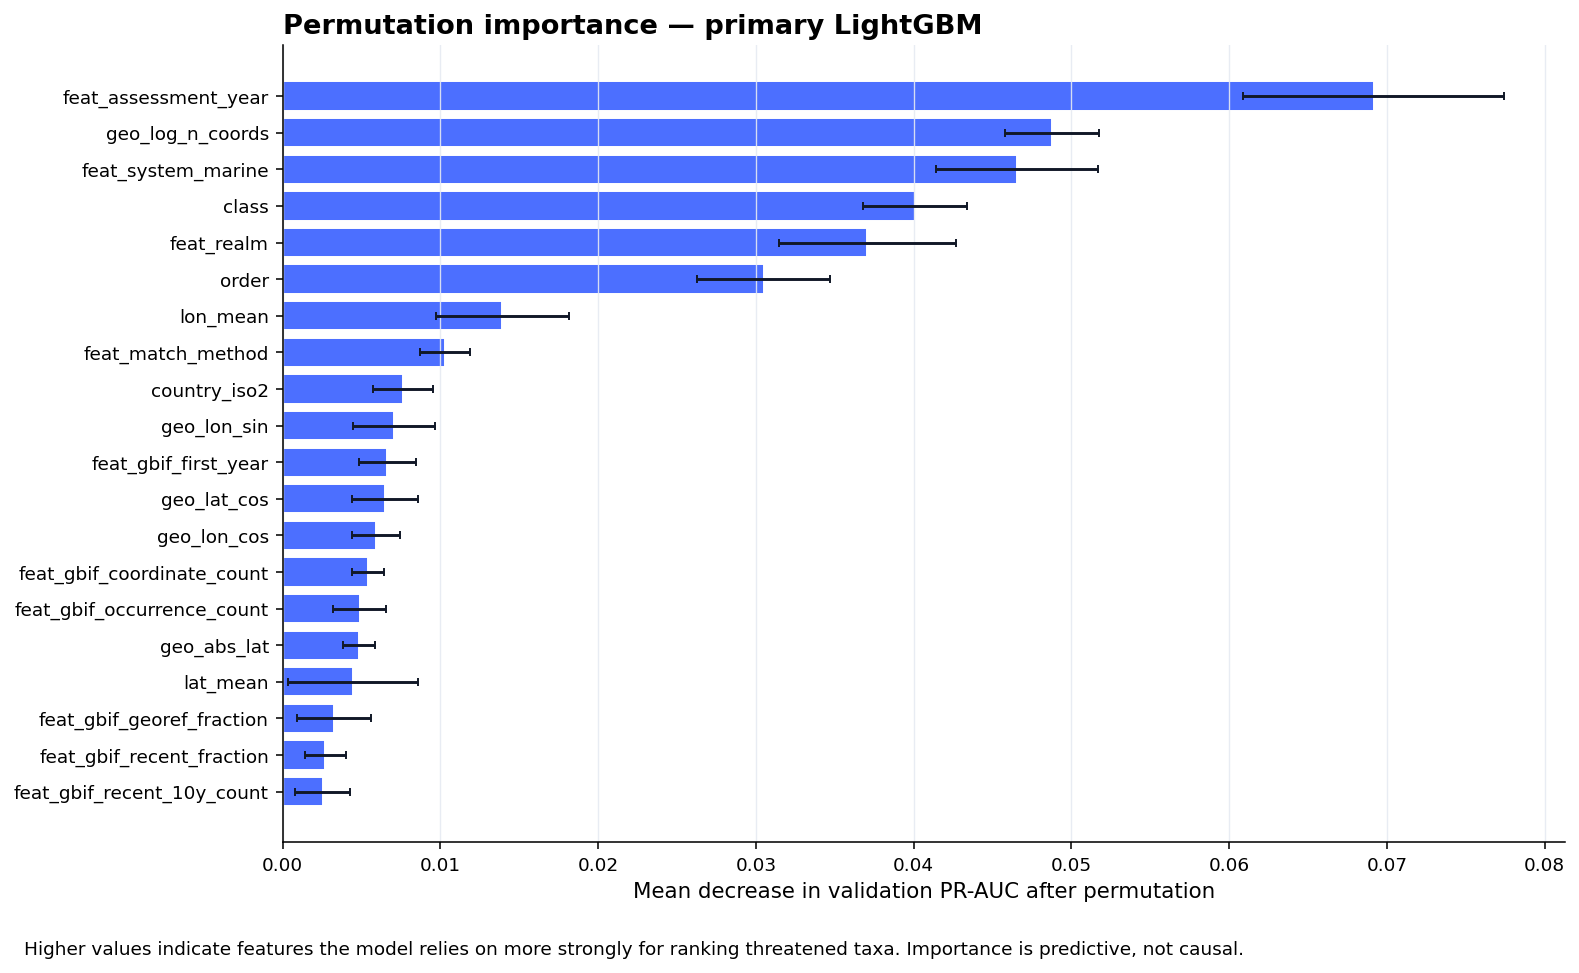

In [ ]:
# ================================================================
# CELL 18 | Permutation importance for raw input features
# ================================================================
perm_n = min(3000, len(X_val))
perm_idx = np.random.default_rng(RANDOM_STATE).choice(len(X_val), size=perm_n, replace=False)
X_perm = X_val.iloc[perm_idx].copy()
y_perm = y_val.iloc[perm_idx].copy() if hasattr(y_val, "iloc") else pd.Series(y_val).iloc[perm_idx]

perm = permutation_importance(
    primary_model, X_perm, y_perm,
    scoring="average_precision", n_repeats=5,
    random_state=RANDOM_STATE, n_jobs=-1
)
perm_df = pd.DataFrame({
    "feature": selected_features,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)
perm_df.to_csv(TABLE_DIR / "permutation_importance_primary_lightgbm.csv", index=False)

top = perm_df.head(20).sort_values("importance_mean", ascending=True).copy()
fig, ax = plt.subplots(figsize=(11.4, 7.4))
ax.barh(top["feature"], top["importance_mean"], xerr=top["importance_std"],
        color="#4C6FFF", edgecolor="white", ecolor="#111827", capsize=2)
ax.set_title("Permutation importance — primary LightGBM", loc="left", fontweight="bold")
ax.set_xlabel("Mean decrease in validation PR-AUC after permutation")
ax.set_ylabel("")
clean_axis(ax)
fig.text(0.02, 0.02, "Higher values indicate features the model relies on more strongly for ranking threatened taxa. Importance is predictive, not causal.", fontsize=9.5)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
save_pubfig(fig, "figure_05_permutation_importance_lightgbm")
plt.show()

## 9. Data-Deficient reassessment prioritization
Data-Deficient taxa are not classified as threatened here. They are ranked by similarity to assessed threatened taxa using the raw LightGBM ranking score.

# **CELL 19: SCORE LABELED AND DATA-DEFICIENT TAXA USING PRIMARY LIGHTGBM MODEL**

In [ ]:
# ================================================================
# CELL 19 | Score labeled and Data-Deficient taxa using primary LightGBM
# ================================================================
def primary_predict_scores(frame):
    X = frame[selected_features].copy()
    raw = primary_model.predict_proba(X)[:, 1]
    cal = calibrator.transform(raw)
    return raw, cal

labeled_raw, labeled_cal = primary_predict_scores(df_labeled)
labeled_predictions = df_labeled[[
    "internalTaxonId", "scientificName", "phylum", "class", "order", "family", "genus",
    "target_risk_category", "country_iso2", "country_iso3", "lat_mean", "lon_mean", "geo_n_coords",
    SPLIT_COL, TARGET
]].copy()
labeled_predictions["priority_score_raw"] = labeled_raw
labeled_predictions["calibrated_screening_score"] = labeled_cal
labeled_predictions["screen_positive_at_f2_threshold"] = (labeled_cal >= FINAL_THRESHOLD).astype(int)
labeled_predictions["priority_decile"] = pd.qcut(labeled_predictions["priority_score_raw"], q=10, labels=[f"D{i}" for i in range(1, 11)], duplicates="drop")
labeled_predictions.to_csv(TABLE_DIR / "all_labeled_taxa_lightgbm_priority_scores.csv", index=False)

if len(df_dd):
    dd_raw, dd_cal = primary_predict_scores(df_dd)
    dd_predictions = df_dd[[
        "internalTaxonId", "scientificName", "phylum", "class", "order", "family", "genus",
        "target_risk_category", "country_iso2", "country_iso3", "lat_mean", "lon_mean", "geo_n_coords",
        "feat_gbif_occurrence_count", "feat_gbif_coordinate_count"
    ]].copy()
    dd_predictions["priority_score_raw"] = dd_raw
    dd_predictions["calibrated_screening_score"] = dd_cal
    dd_predictions["screen_positive_at_f2_threshold"] = (dd_cal >= FINAL_THRESHOLD).astype(int)
    dd_predictions = dd_predictions.sort_values("priority_score_raw", ascending=False).reset_index(drop=True)
    dd_predictions["priority_rank"] = np.arange(1, len(dd_predictions) + 1)
    dd_predictions["priority_percentile"] = 100 * (1 - (dd_predictions["priority_rank"] - 1) / max(len(dd_predictions) - 1, 1))
    dd_predictions["priority_decile"] = pd.qcut(dd_predictions["priority_score_raw"], q=10, labels=[f"D{i}" for i in range(1, 11)], duplicates="drop")
    dd_predictions.to_csv(TABLE_DIR / "data_deficient_reassessment_priority_ranking_lightgbm.csv", index=False)
else:
    dd_predictions = pd.DataFrame()

print("Top known high-priority labeled taxa:")
display(labeled_predictions.sort_values("priority_score_raw", ascending=False).head(20).reset_index(drop=True))
print("\nTop Data-Deficient reassessment priority candidates:")
display(dd_predictions.head(50).reset_index(drop=True))

Top known high-priority labeled taxa:


,internalTaxonId,scientificName,phylum,class,order,family,genus,target_risk_category,country_iso2,country_iso3,lat_mean,lon_mean,geo_n_coords,split,target_threatened_extant,priority_score_raw,calibrated_screening_score,screen_positive_at_f2_threshold,priority_decile
0,198825,Samoana stevensoniana,MOLLUSCA,GASTROPODA,STYLOMMATOPHORA,PARTULIDAE,Samoana,Critically Endangered,WS,WSM,-14.234273,-169.041848,7.0,train,1.0,0.995045,1.0,1,D10
1,198790,Eua globosa,MOLLUSCA,GASTROPODA,STYLOMMATOPHORA,PARTULIDAE,Eua,Critically Endangered,TO,TON,-20.456600,-174.977403,3.0,train,1.0,0.994999,1.0,1,D10
2,54490,Atelopus arthuri,CHORDATA,AMPHIBIA,ANURA,BUFONIDAE,Atelopus,Critically Endangered,EC,ECU,-1.805153,-78.951296,48.0,train,1.0,0.994950,1.0,1,D10
3,198791,Eua mauga,MOLLUSCA,GASTROPODA,STYLOMMATOPHORA,PARTULIDAE,Eua,Critically Endangered,WS,WSM,-13.918900,-171.740187,3.0,train,1.0,0.994883,1.0,1,D10
4,16284,Partula arguta,MOLLUSCA,GASTROPODA,STYLOMMATOPHORA,PARTULIDAE,Partula,Critically Endangered,PF,PYF,-16.930386,-150.642077,20.0,train,1.0,0.994715,1.0,1,D10
5,12759,Manica parasitica,ARTHROPODA,INSECTA,HYMENOPTERA,FORMICIDAE,Manica,Vulnerable,US,USA,37.854380,-119.449820,1.0,train,1.0,0.994140,1.0,1,D10
6,54536,Atelopus pachydermus,CHORDATA,AMPHIBIA,ANURA,BUFONIDAE,Atelopus,Critically Endangered,EC,ECU,-0.621526,-78.303732,17.0,train,1.0,0.993998,1.0,1,D10
7,198789,Eua expansa,MOLLUSCA,GASTROPODA,STYLOMMATOPHORA,PARTULIDAE,Eua,Endangered,WS,WSM,-14.125450,-170.001950,22.0,train,1.0,0.993946,1.0,1,D10
8,136038,Atelopus petersi,CHORDATA,AMPHIBIA,ANURA,BUFONIDAE,Atelopus,Critically Endangered,EC,ECU,-0.433087,-78.141583,64.0,train,1.0,0.993586,1.0,1,D10
9,14752,Newcombia sulcata,MOLLUSCA,GASTROPODA,STYLOMMATOPHORA,ACHATINELLIDAE,Newcombia,Endangered,US,USA,21.158047,-157.117144,10.0,train,1.0,0.993197,1.0,1,D10



Top Data-Deficient reassessment priority candidates:


,internalTaxonId,scientificName,phylum,class,order,family,genus,target_risk_category,country_iso2,country_iso3,...,lon_mean,geo_n_coords,feat_gbif_occurrence_count,feat_gbif_coordinate_count,priority_score_raw,calibrated_screening_score,screen_positive_at_f2_threshold,priority_rank,priority_percentile,priority_decile
0,12532,Lyropupa mirabilis,MOLLUSCA,GASTROPODA,STYLOMMATOPHORA,PUPILLIDAE,Lyropupa,Data Deficient,US,USA,...,-157.436709,13.0,45.0,13.0,0.993252,1.0,1,1,100.000000,D10
1,14693,Nesopupa litoralis,MOLLUSCA,GASTROPODA,STYLOMMATOPHORA,PUPILLIDAE,Nesopupa,Data Deficient,US,USA,...,-157.921650,2.0,8.0,2.0,0.992727,1.0,1,2,99.993862,D10
2,12531,Lyropupa microthauma,MOLLUSCA,GASTROPODA,STYLOMMATOPHORA,PUPILLIDAE,Lyropupa,Data Deficient,US,USA,...,-157.835938,8.0,24.0,8.0,0.992645,1.0,1,3,99.987724,D10
3,14690,Nesopupa infrequens,MOLLUSCA,GASTROPODA,STYLOMMATOPHORA,PUPILLIDAE,Nesopupa,Data Deficient,US,USA,...,-159.671530,2.0,9.0,2.0,0.992621,1.0,1,4,99.981586,D10
4,14696,Nesopupa oahuensis,MOLLUSCA,GASTROPODA,STYLOMMATOPHORA,PUPILLIDAE,Nesopupa,Data Deficient,US,USA,...,-157.858195,2.0,6.0,2.0,0.992468,1.0,1,5,99.975448,D10
5,14702,Nesopupa waianensis,MOLLUSCA,GASTROPODA,STYLOMMATOPHORA,PUPILLIDAE,Nesopupa,Data Deficient,US,USA,...,-157.562846,5.0,9.0,5.0,0.991879,1.0,1,6,99.969310,D10
6,14701,Nesopupa thaanumi,MOLLUSCA,GASTROPODA,STYLOMMATOPHORA,PUPILLIDAE,Nesopupa,Data Deficient,US,USA,...,-155.825330,4.0,14.0,4.0,0.991695,1.0,1,7,99.963172,D10
7,16371,Partulina ustulata,MOLLUSCA,GASTROPODA,STYLOMMATOPHORA,ACHATINELLIDAE,Partulina,Data Deficient,US,USA,...,-156.547672,8.0,22.0,8.0,0.991600,1.0,1,8,99.957034,D10
8,12533,Lyropupa prisca,MOLLUSCA,GASTROPODA,STYLOMMATOPHORA,PUPILLIDAE,Lyropupa,Data Deficient,US,USA,...,-156.607157,4.0,12.0,4.0,0.991482,1.0,1,9,99.950896,D10
9,14688,Nesopupa dubitabilis,MOLLUSCA,GASTROPODA,STYLOMMATOPHORA,PUPILLIDAE,Nesopupa,Data Deficient,US,USA,...,-157.226741,7.0,16.0,7.0,0.991472,1.0,1,10,99.944758,D10


# **CELL 20: DATA-DEFICIENT PRIORITY SUMMARY**

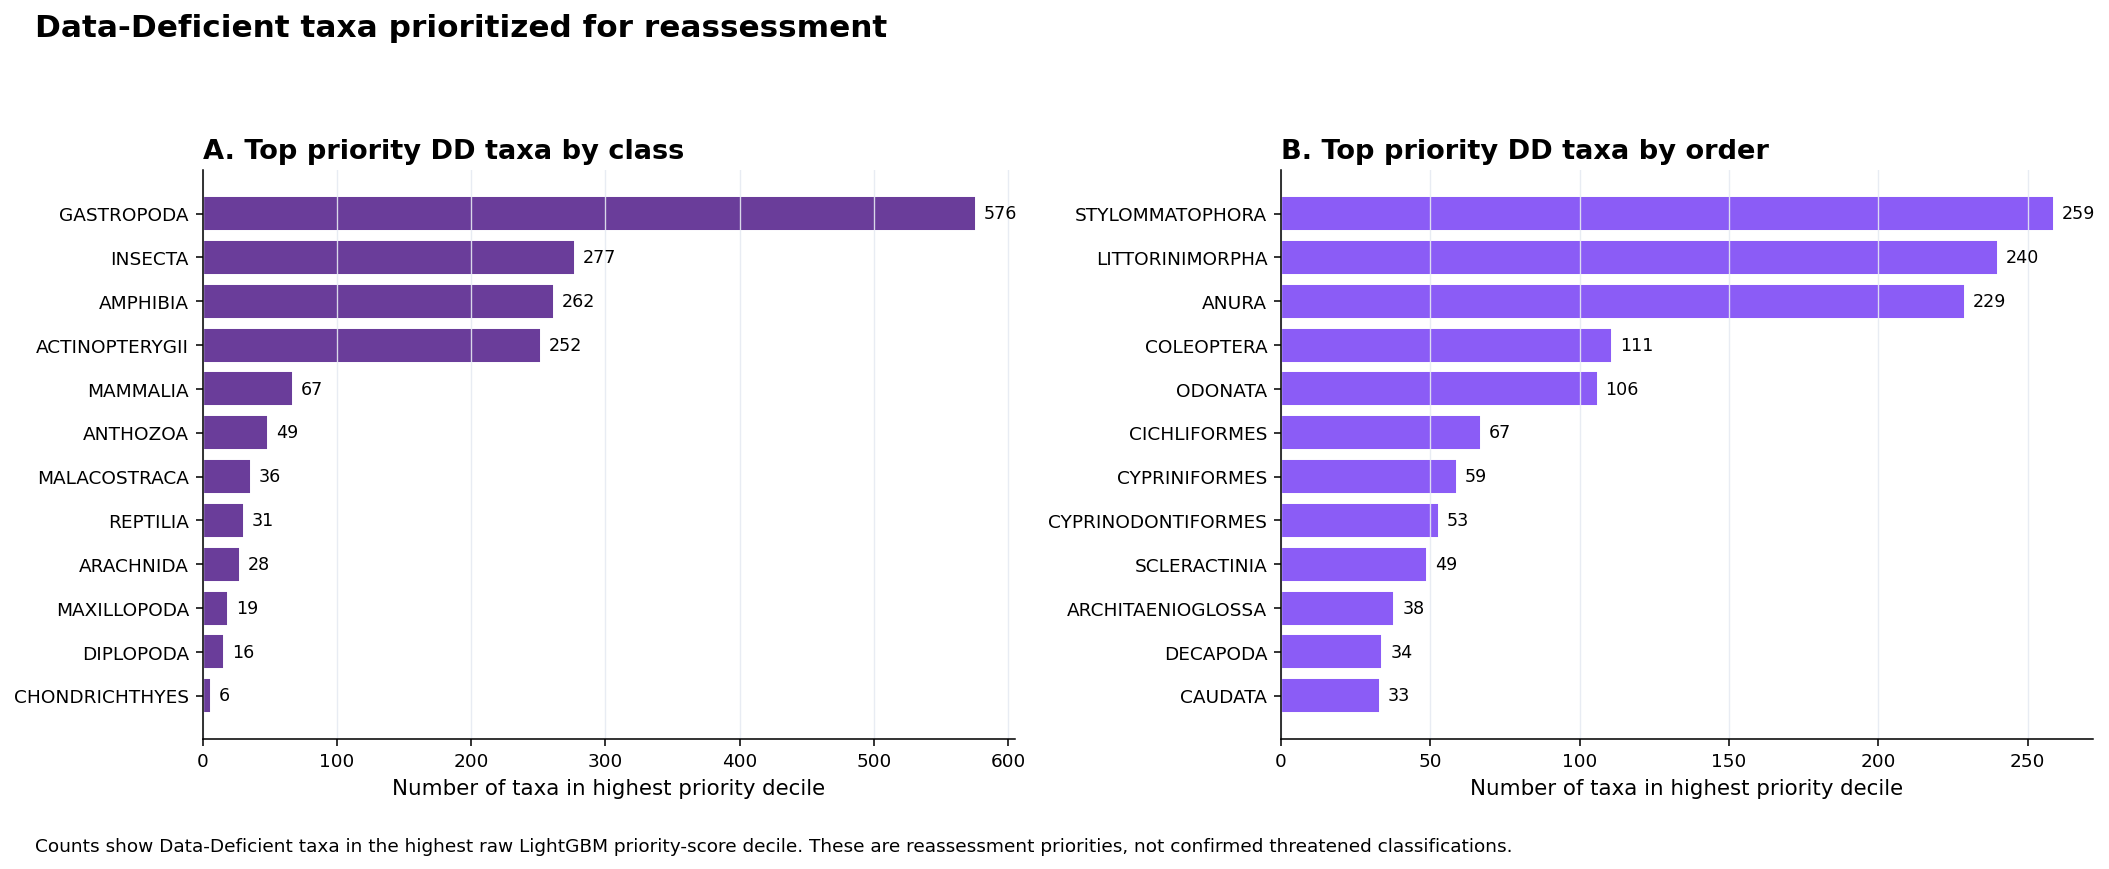

In [ ]:
# ================================================================
# CELL 20 | Figure 6: Data-Deficient priority summaries
# ================================================================
if len(dd_predictions):
    top_decile_label = dd_predictions["priority_decile"].cat.categories[-1] if hasattr(dd_predictions["priority_decile"], "cat") else "D10"
    dd_top = dd_predictions[dd_predictions["priority_decile"].astype(str).eq(str(top_decile_label))].copy()
    class_summary = (
        dd_top.groupby("class", dropna=False)
              .agg(n_top_priority=("scientificName", "size"), mean_priority_score=("priority_score_raw", "mean"))
              .reset_index()
              .sort_values("n_top_priority", ascending=False)
              .head(12)
    )
    order_summary_dd = (
        dd_top.groupby("order", dropna=False)
              .agg(n_top_priority=("scientificName", "size"), mean_priority_score=("priority_score_raw", "mean"))
              .reset_index()
              .sort_values("n_top_priority", ascending=False)
              .head(12)
    )
    class_summary.to_csv(TABLE_DIR / "top_decile_dd_priority_by_class.csv", index=False)
    order_summary_dd.to_csv(TABLE_DIR / "top_decile_dd_priority_by_order.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(15.2, 6.2))
    ax = axes[0]
    p = class_summary.sort_values("n_top_priority", ascending=True)
    ax.barh(p["class"].astype(str), p["n_top_priority"], color="#6A3D9A", edgecolor="white")
    for y, v in enumerate(p["n_top_priority"]):
        ax.text(v + max(p["n_top_priority"]) * 0.01, y, f"{int(v):,}", va="center", fontsize=9)
    ax.set_title("A. Top priority DD taxa by class", loc="left", fontweight="bold")
    ax.set_xlabel("Number of taxa in highest priority decile")
    clean_axis(ax)

    ax = axes[1]
    p = order_summary_dd.sort_values("n_top_priority", ascending=True)
    ax.barh(p["order"].astype(str), p["n_top_priority"], color="#8B5CF6", edgecolor="white")
    for y, v in enumerate(p["n_top_priority"]):
        ax.text(v + max(p["n_top_priority"]) * 0.01, y, f"{int(v):,}", va="center", fontsize=9)
    ax.set_title("B. Top priority DD taxa by order", loc="left", fontweight="bold")
    ax.set_xlabel("Number of taxa in highest priority decile")
    clean_axis(ax)

    fig.suptitle("Data-Deficient taxa prioritized for reassessment", fontsize=16, fontweight="bold", x=0.02, ha="left")
    fig.text(0.02, 0.015, "Counts show Data-Deficient taxa in the highest raw LightGBM priority-score decile. These are reassessment priorities, not confirmed threatened classifications.", fontsize=9.5)
    plt.tight_layout(rect=[0, 0.05, 1, 0.92])
    save_pubfig(fig, "figure_06_data_deficient_priority_summaries")
    plt.show()
else:
    print("No Data-Deficient taxa available for priority summaries.")

## 10.  visual summaries
These figures are descriptive and should be described carefully: mean GBIF coordinates are not official range maps.

# **CELL 21: RISK-SCORE SEPARATION ON HELD-OUT TEST SET**

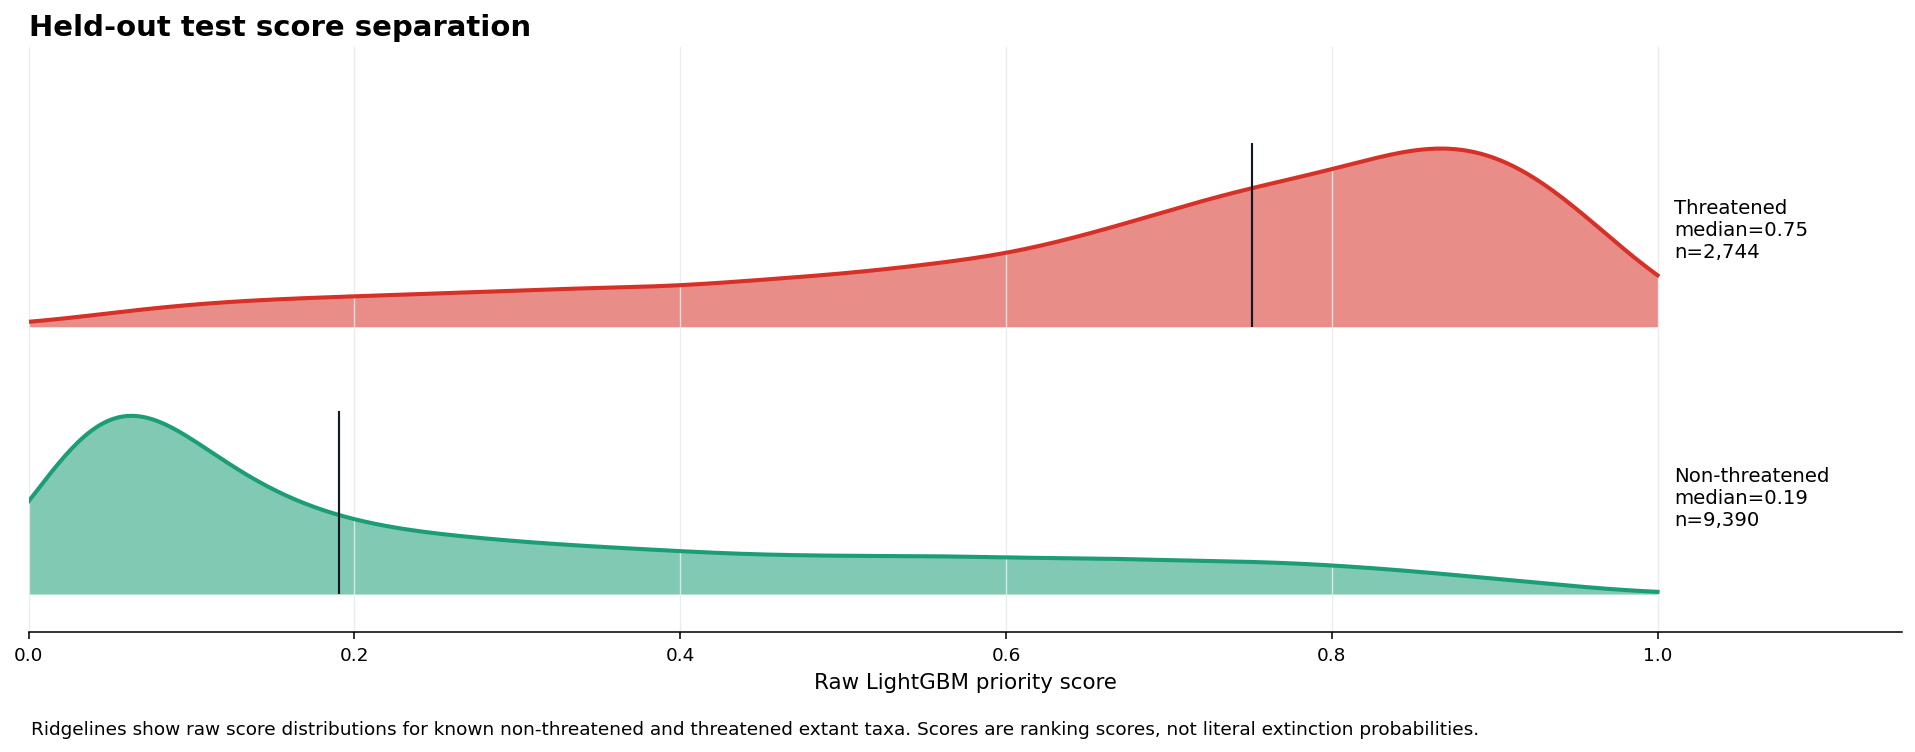

In [ ]:
# ================================================================
# CELL 21 | Figure 7: Risk-score separation on held-out test set
# ================================================================
test_scores = test_df[["target_risk_category"]].copy()
test_scores["priority_score_raw"] = primary_test_score
test_scores["conservation_group"] = test_scores["target_risk_category"].map(risk_group)
plot_order = ["Non-threatened", "Threatened"]
plot_scores = test_scores[test_scores["conservation_group"].isin(plot_order)].copy()
x_grid = np.linspace(0, 1, 500)

fig, ax = plt.subplots(figsize=(13.8, 5.8))
for i, g in enumerate(plot_order):
    vals = plot_scores.loc[plot_scores["conservation_group"].eq(g), "priority_score_raw"].dropna().values
    if len(vals) < 5:
        continue
    vals_j = np.clip(vals + np.random.default_rng(RANDOM_STATE + i).normal(0, 0.002, size=len(vals)), 0, 1)
    kde = gaussian_kde(vals_j)
    y = kde(x_grid)
    y = y / y.max() * 0.7
    base = i * 1.05
    ax.fill_between(x_grid, base, base + y, color=GROUP_COLORS[g], alpha=0.55, linewidth=0)
    ax.plot(x_grid, base + y, color=GROUP_COLORS[g], linewidth=2.1)
    med = np.median(vals)
    ax.vlines(med, base, base + 0.72, color="#111827", linewidth=1.1)
    ax.text(1.01, base + 0.38, f"{g}\nmedian={med:.2f}\nn={len(vals):,}", va="center", ha="left", fontsize=10.2)

ax.set_yticks([])
ax.set_xlim(0, 1.15)
ax.set_ylim(-0.15, 2.15)
ax.set_xlabel("Raw LightGBM priority score")
ax.set_title("Held-out test score separation", loc="left", fontweight="bold", fontsize=15)
ax.grid(True, axis="x", color="#E6EAF2")
ax.grid(False, axis="y")
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
fig.text(0.02, 0.025, "Ridgelines show raw score distributions for known non-threatened and threatened extant taxa. Scores are ranking scores, not literal extinction probabilities.", fontsize=9.5)
plt.tight_layout(rect=[0, 0.05, 1, 0.94])
save_pubfig(fig, "figure_07_test_score_separation")
plt.show()

# **CELL 22: TAXONOMIC RISK LANDSCAPE**

Taxonomic orders shown: 76
Minimum labeled extant taxa per order: 120


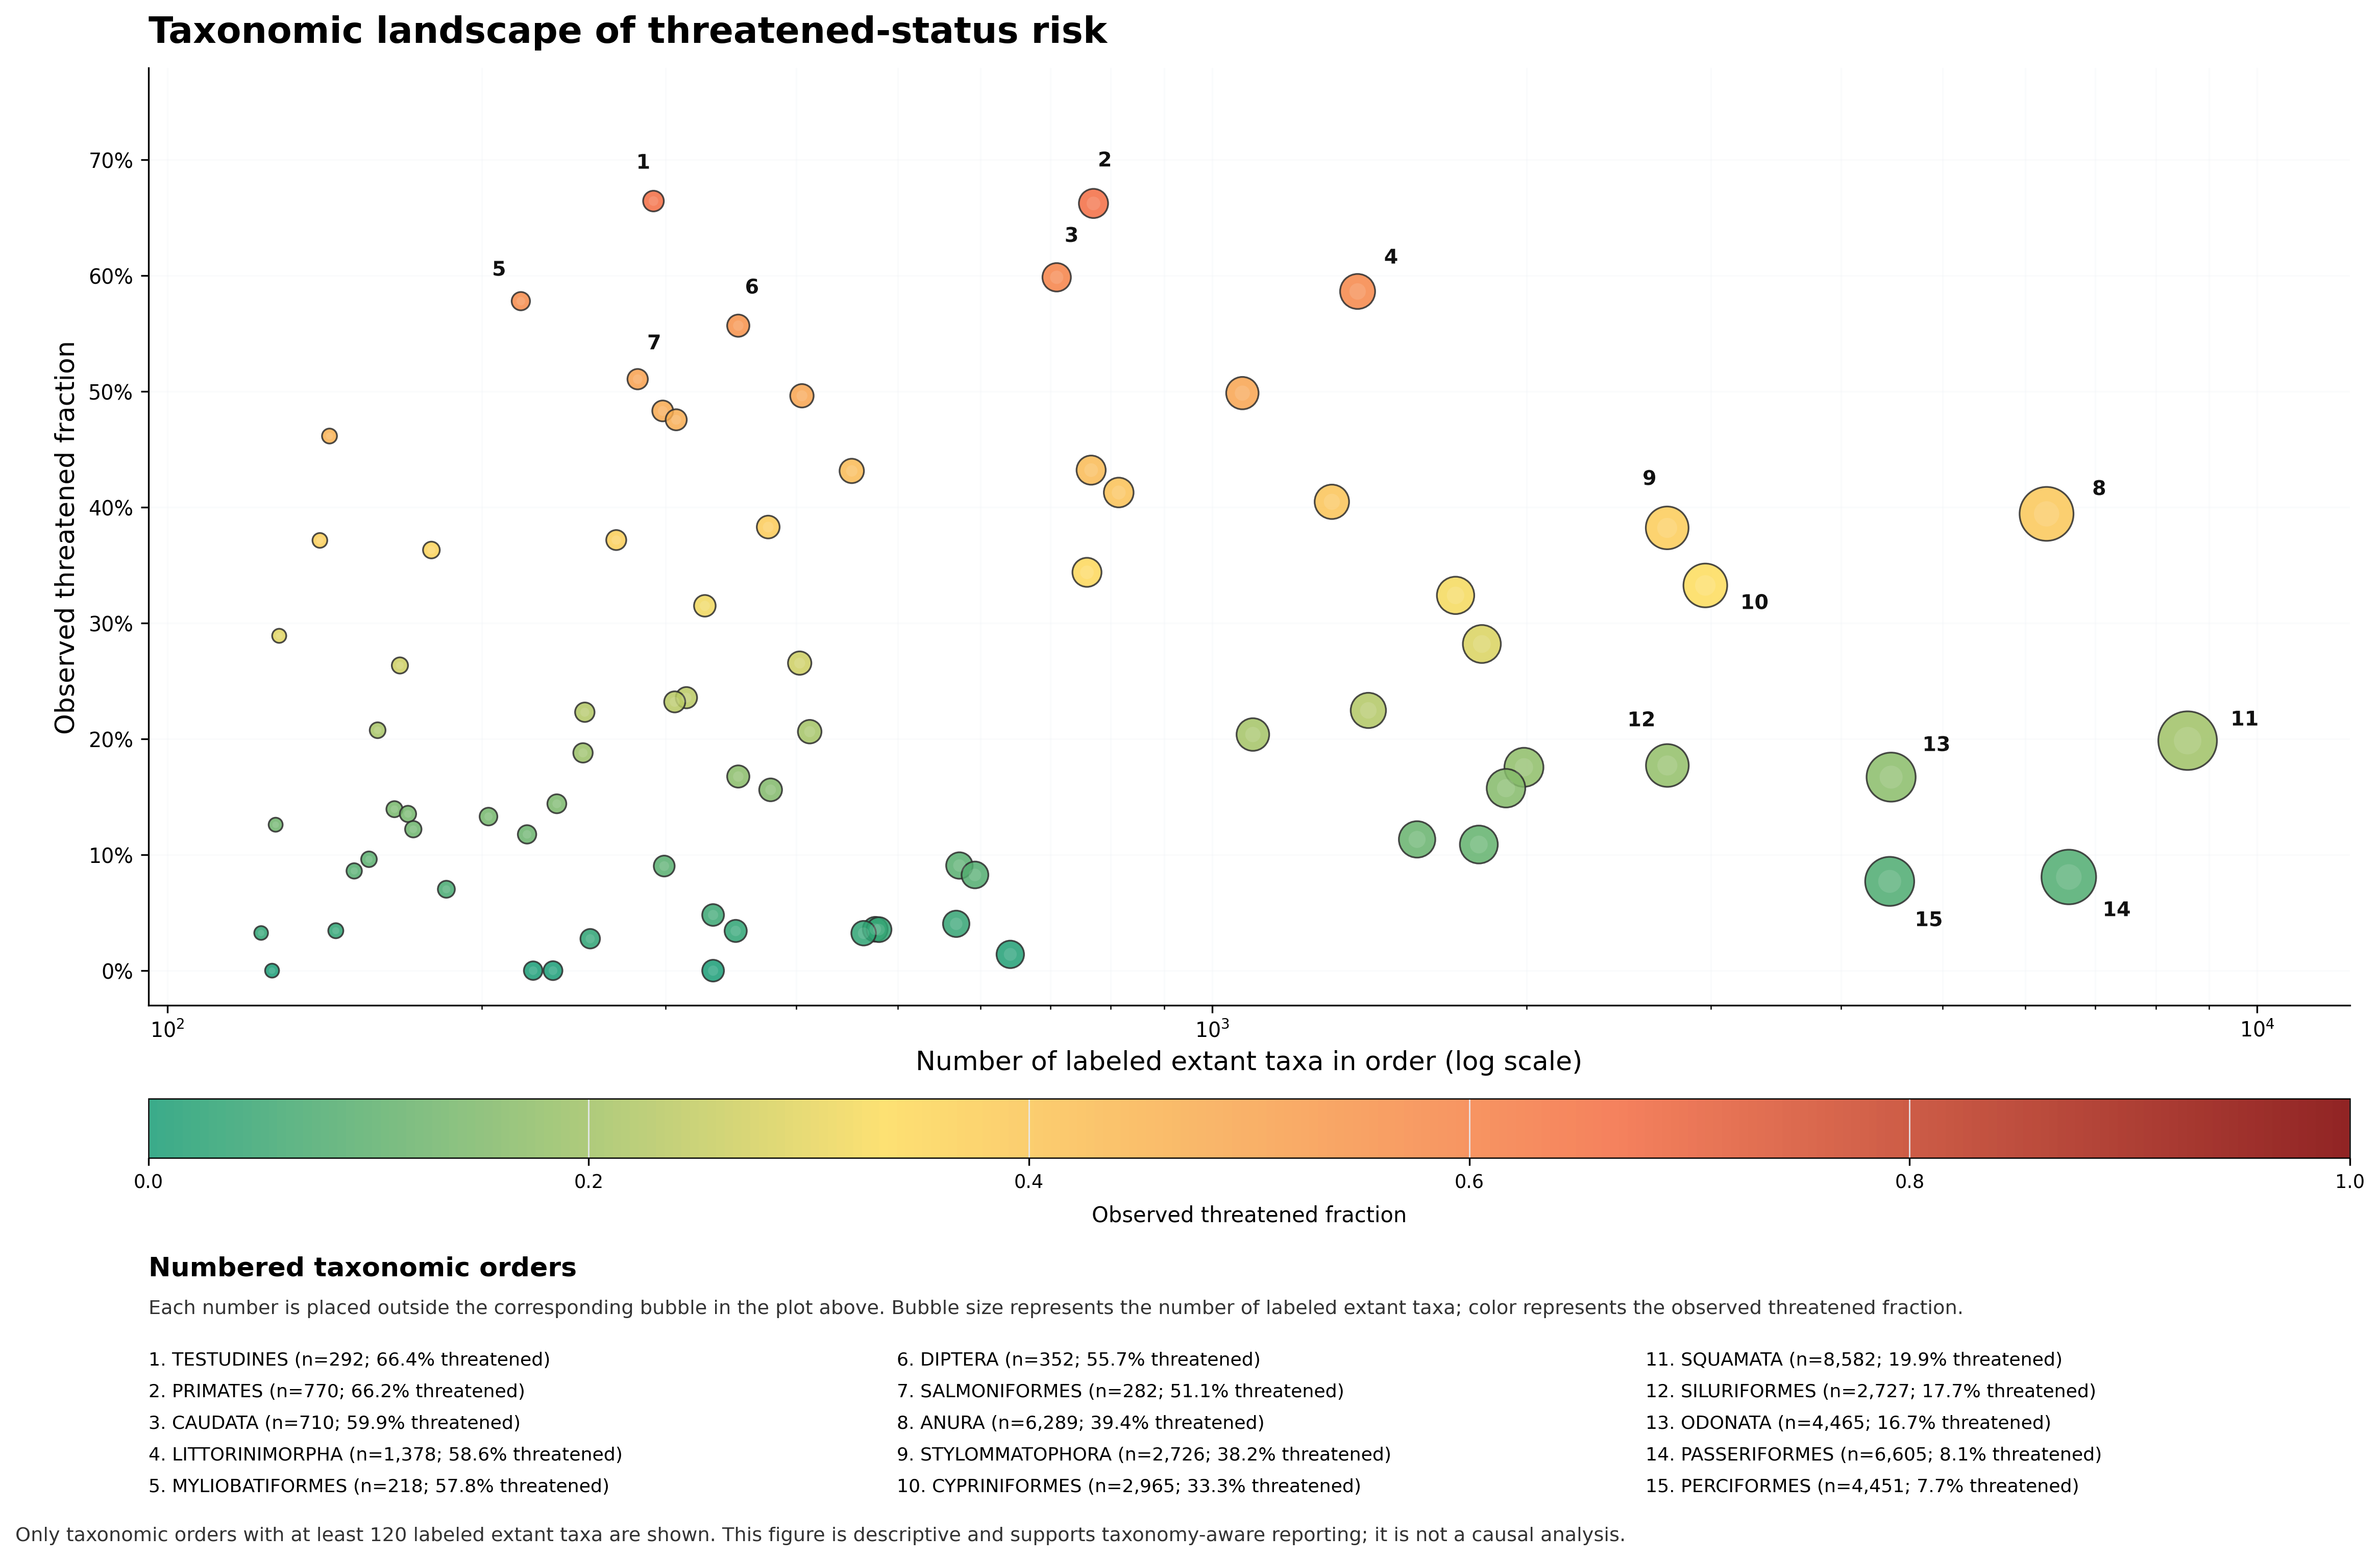

In [ ]:
# ================================================================
# CELL 22 | TAXONOMIC RISK LANDSCAPE
#          + numbered-order key below the figure
# ================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter

# ------------------------------------------------------------
# 1. Prepare labeled extant taxa
# ------------------------------------------------------------
if "df_labeled" not in globals():
    raise NameError("df_labeled not found. Run the data preparation cells first.")

if "TARGET" not in globals():
    TARGET = "target_threatened_extant"

plot_df = df_labeled.copy()

plot_df = plot_df[
    plot_df["order"].notna() &
    plot_df[TARGET].notna()
].copy()

if "target_is_extinct" in plot_df.columns:
    plot_df = plot_df[plot_df["target_is_extinct"].fillna(0).astype(int).eq(0)].copy()

if "target_is_data_deficient" in plot_df.columns:
    plot_df = plot_df[plot_df["target_is_data_deficient"].fillna(0).astype(int).eq(0)].copy()

# ------------------------------------------------------------
# 2. Summarize by taxonomic order
# ------------------------------------------------------------
order_summary = (
    plot_df.groupby("order")
    .agg(
        n_labeled_extant=(TARGET, "size"),
        threatened_fraction=(TARGET, "mean")
    )
    .reset_index()
)

min_n = 120
order_summary = order_summary[order_summary["n_labeled_extant"] >= min_n].copy()

order_summary = order_summary.sort_values(
    ["threatened_fraction", "n_labeled_extant"],
    ascending=[False, False]
).reset_index(drop=True)

print(f"Taxonomic orders shown: {len(order_summary):,}")
print(f"Minimum labeled extant taxa per order: {min_n:,}")

# ------------------------------------------------------------
# 3. Bubble sizes
# ------------------------------------------------------------
n_min = order_summary["n_labeled_extant"].min()
n_max = order_summary["n_labeled_extant"].max()

size_min = 42
size_max = 760

order_summary["bubble_size"] = np.interp(
    np.sqrt(order_summary["n_labeled_extant"]),
    (np.sqrt(n_min), np.sqrt(n_max)),
    (size_min, size_max)
)

# ------------------------------------------------------------
# 4. Select important orders to number
# ------------------------------------------------------------
high_risk_labels = set(
    order_summary.loc[
        order_summary["threatened_fraction"] >= 0.50,
        "order"
    ]
)

large_order_labels = set(
    order_summary.nlargest(8, "n_labeled_extant")["order"]
)

must_label = {
    "ANURA",
    "SQUAMATA",
    "PASSERIFORMES",
    "PRIMATES",
    "CAUDATA",
    "TESTUDINES",
    "MYLIOBATIFORMES",
    "DIPTERA",
    "CYPRINIFORMES",
    "LITTORINIMORPHA",
    "STYLOMMATOPHORA",
    "ODONATA",
    "PERCIFORMES",
}

highlight_orders = high_risk_labels | large_order_labels | must_label

highlight_df = order_summary[
    order_summary["order"].isin(highlight_orders)
].copy()

# Limit to avoid visual crowding
highlight_df = highlight_df.sort_values(
    ["threatened_fraction", "n_labeled_extant"],
    ascending=[False, False]
).head(15).reset_index(drop=True)

highlight_df["callout_id"] = np.arange(1, len(highlight_df) + 1)

order_summary = order_summary.merge(
    highlight_df[["order", "callout_id"]],
    on="order",
    how="left"
)

# ------------------------------------------------------------
# 5. Output folder and color scale
# ------------------------------------------------------------
FIGOUT = str(FIG_DIR) if "FIG_DIR" in globals() else "extinction_risk_outputs/figures"
os.makedirs(FIGOUT, exist_ok=True)

risk_cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "risk_teal_gold_red",
    ["#1B9E77", "#FDDC5C", "#F46D43", "#7F0000"],
    N=256
)

norm = mpl.colors.Normalize(vmin=0, vmax=1)

# ------------------------------------------------------------
# 6. Figure layout
# Main plot on top; colorbar and numbered key below.
# ------------------------------------------------------------
fig = plt.figure(figsize=(15.8, 10.4), dpi=300)

gs = GridSpec(
    nrows=3,
    ncols=1,
    height_ratios=[7.1, 0.45, 1.65],
    hspace=0.23,
    figure=fig
)

ax = fig.add_subplot(gs[0, 0])
cax = fig.add_subplot(gs[1, 0])
key_ax = fig.add_subplot(gs[2, 0])
key_ax.axis("off")

# ------------------------------------------------------------
# 7. Bubble plot
# ------------------------------------------------------------
sc = ax.scatter(
    order_summary["n_labeled_extant"],
    order_summary["threatened_fraction"],
    s=order_summary["bubble_size"],
    c=order_summary["threatened_fraction"],
    cmap=risk_cmap,
    norm=norm,
    alpha=0.86,
    edgecolor="#2F2F2F",
    linewidth=0.8,
    zorder=3
)

# Small white highlight inside bubbles
ax.scatter(
    order_summary["n_labeled_extant"],
    order_summary["threatened_fraction"],
    s=order_summary["bubble_size"] * 0.22,
    color="white",
    alpha=0.12,
    linewidth=0,
    zorder=4
)

# ------------------------------------------------------------
# 8. Uncircled numbers outside selected bubbles
# ------------------------------------------------------------
special_angles = {
    "TESTUDINES": 105,
    "PRIMATES": 75,
    "CAUDATA": 70,
    "LITTORINIMORPHA": 45,
    "MYLIOBATIFORMES": 125,
    "DIPTERA": 70,
    "ANURA": 25,
    "CYPRINIFORMES": -20,
    "SQUAMATA": 20,
    "ODONATA": 35,
    "PERCIFORMES": -45,
    "PASSERIFORMES": -35,
    "STYLOMMATOPHORA": 110,
}

fallback_angles = [65, 120, 35, -35, 90, -90, 150, -150]
fallback_i = 0

for _, row in order_summary.dropna(subset=["callout_id"]).iterrows():
    x = row["n_labeled_extant"]
    y = row["threatened_fraction"]
    s = row["bubble_size"]
    name = row["order"]
    cid = int(row["callout_id"])

    radius_pts = np.sqrt(s / np.pi)
    dist_pts = radius_pts + 13

    if name in special_angles:
        angle_deg = special_angles[name]
    else:
        angle_deg = fallback_angles[fallback_i % len(fallback_angles)]
        fallback_i += 1

    theta = np.deg2rad(angle_deg)
    dx = dist_pts * np.cos(theta)
    dy = dist_pts * np.sin(theta)

    ax.annotate(
        str(cid),
        xy=(x, y),
        xycoords="data",
        xytext=(dx, dy),
        textcoords="offset points",
        ha="center",
        va="center",
        fontsize=9.5,
        fontweight="bold",
        color="#111111",
        zorder=8,
        path_effects=[
            pe.withStroke(linewidth=2.6, foreground="white")
        ]
    )

# ------------------------------------------------------------
# 9. Axis formatting
# ------------------------------------------------------------
ax.set_xscale("log")

ax.set_xlabel(
    "Number of labeled extant taxa in order (log scale)",
    fontsize=12.5
)

ax.set_ylabel(
    "Observed threatened fraction",
    fontsize=12.5
)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f"{100*y:.0f}%")
)

ax.grid(
    True,
    which="both",
    axis="both",
    alpha=0.16,
    linewidth=0.8
)

ax.set_axisbelow(True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

xmin = max(90, order_summary["n_labeled_extant"].min() * 0.78)
xmax = order_summary["n_labeled_extant"].max() * 1.43

ymin = max(-0.03, order_summary["threatened_fraction"].min() - 0.035)
ymax = min(1.0, order_summary["threatened_fraction"].max() + 0.115)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.set_title(
    "Taxonomic landscape of threatened-status risk",
    fontsize=17,
    fontweight="bold",
    loc="left",
    pad=12
)

# ------------------------------------------------------------
# 10. Horizontal colorbar
# ------------------------------------------------------------
cb = fig.colorbar(
    sc,
    cax=cax,
    orientation="horizontal"
)

cb.set_label(
    "Observed threatened fraction",
    fontsize=10,
    labelpad=6
)

cb.ax.tick_params(labelsize=8.8)
cb.outline.set_linewidth(0.6)

# ------------------------------------------------------------
# 11. Clean numbered-order key below the plot
# ------------------------------------------------------------
key_ax.text(
    0.00,
    0.98,
    "Numbered taxonomic orders",
    fontsize=12.5,
    fontweight="bold",
    ha="left",
    va="top",
    transform=key_ax.transAxes
)

key_ax.text(
    0.00,
    0.78,
    "Each number is placed outside the corresponding bubble in the plot above. "
    "Bubble size represents the number of labeled extant taxa; color represents the observed threatened fraction.",
    fontsize=9.2,
    ha="left",
    va="top",
    color="#333333",
    transform=key_ax.transAxes
)

key_df = highlight_df[["callout_id", "order", "n_labeled_extant", "threatened_fraction"]].copy()

# Split key into three clean columns
n_cols = 3
rows_per_col = int(np.ceil(len(key_df) / n_cols))

x_positions = [0.00, 0.34, 0.68]
y_start = 0.54
dy = 0.145

for col in range(n_cols):
    sub = key_df.iloc[col * rows_per_col:(col + 1) * rows_per_col]

    for i, (_, r) in enumerate(sub.iterrows()):
        y = y_start - i * dy
        x = x_positions[col]

        key_text = (
            f"{int(r['callout_id'])}. {r['order']} "
            f"(n={int(r['n_labeled_extant']):,}; "
            f"{100*r['threatened_fraction']:.1f}% threatened)"
        )

        key_ax.text(
            x,
            y,
            key_text,
            fontsize=8.7,
            ha="left",
            va="top",
            transform=key_ax.transAxes
        )

# ------------------------------------------------------------
# 12. Figure note and save
# ------------------------------------------------------------
fig.text(
    0.02,
    0.015,
    f"Only taxonomic orders with at least {min_n:,} labeled extant taxa are shown. "
    "This figure is descriptive and supports taxonomy-aware reporting; it is not a causal analysis.",
    fontsize=9.2,
    ha="left",
    color="#333333"
)

out_png = os.path.join(FIGOUT, "figure_08_taxonomic_risk_landscape_clean_numbered_key_below.png")
out_pdf = os.path.join(FIGOUT, "figure_08_taxonomic_risk_landscape_clean_numbered_key_below.pdf")

fig.subplots_adjust(
    left=0.075,
    right=0.985,
    top=0.94,
    bottom=0.06
)

fig.savefig(out_png, dpi=450, bbox_inches="tight", facecolor="white")
fig.savefig(out_pdf, bbox_inches="tight", facecolor="white")
plt.show()


# **CELL 23: GLOBAL MAP OF DATA-DEFICIENT PRIORITY SCORES**

In [ ]:
# ================================================================
# CELL 23 | GLOBAL MAP OF DATA-DEFICIENT PRIORITY SCORES
#          WITH CIRCLED REGION NUMBERS
# ================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, PowerNorm

# ------------------------------------------------------------
# 1. Select the scored Data-Deficient prediction table
# ------------------------------------------------------------
if "dd_predictions" not in globals():
    raise NameError(
        "dd_predictions was not found. Run the Data-Deficient scoring cell before this map cell."
    )

map_df = dd_predictions.copy()

# ------------------------------------------------------------
# 2. Detect the raw LightGBM priority-score column
# ------------------------------------------------------------
candidate_score_cols = [
    "raw_lightgbm_priority_score",
    "risk_score_raw",
    "priority_score_raw",
    "lightgbm_raw_score",
    "risk_score",
    "priority_score",
]

score_col = None
for c in candidate_score_cols:
    if c in map_df.columns:
        score_col = c
        break

if score_col is None:
    raise ValueError(
        "Could not find a raw priority-score column in dd_predictions. "
        "Expected one of: " + ", ".join(candidate_score_cols)
    )

# ------------------------------------------------------------
# 3. Keep taxa with usable mean GBIF coordinates
# ------------------------------------------------------------
map_df["lat_mean"] = pd.to_numeric(map_df["lat_mean"], errors="coerce")
map_df["lon_mean"] = pd.to_numeric(map_df["lon_mean"], errors="coerce")
map_df[score_col] = pd.to_numeric(map_df[score_col], errors="coerce")

map_df = map_df.dropna(subset=["lat_mean", "lon_mean", score_col]).copy()
map_df = map_df[
    map_df["lat_mean"].between(-90, 90) &
    map_df["lon_mean"].between(-180, 180)
].copy()

# Plot low-priority points first, high-priority points on top
map_df = map_df.sort_values(score_col, ascending=True)

print(f"Mapped Data-Deficient taxa with coordinates: {len(map_df):,}")
print(f"Score column used: {score_col}")

# ------------------------------------------------------------
# 4. Region labels
# ------------------------------------------------------------
REGION_LABELS = [
    (1, "North America", -103, 48),
    (2, "Central America & Caribbean", -78, 17),
    (3, "South America", -60, -18),
    (4, "Europe", 15, 54),
    (5, "Africa", 22, 2),
    (6, "Middle East", 45, 27),
    (7, "South Asia", 78, 22),
    (8, "East Asia", 115, 38),
    (9, "Southeast Asia", 112, 6),
    (10, "Australasia & Pacific", 135, -27),
]

# ------------------------------------------------------------
# 5. Output folder and stronger color scale
# ------------------------------------------------------------
FIGOUT = str(FIG_DIR) if "FIG_DIR" in globals() else "extinction_risk_outputs/figures"
os.makedirs(FIGOUT, exist_ok=True)

# Richer / denser / more vivid colormap
risk_cmap = LinearSegmentedColormap.from_list(
    "priority_dense",
    [
        "#2166AC",  # deep blue
        "#67A9CF",  # blue-cyan
        "#7FCDBB",  # turquoise
        "#FEE08B",  # warm yellow
        "#FDAE61",  # orange
        "#F46D43",  # orange-red
        "#D73027",  # strong red
        "#A50026",  # deep crimson
    ],
    N=512
)

# Power normalization: makes mid/high values more visually pronounced
risk_norm = PowerNorm(gamma=0.82, vmin=0, vmax=1)

# ------------------------------------------------------------
# 6. Figure layout
# Region key on right; horizontal colorbar below map
# ------------------------------------------------------------
fig = plt.figure(figsize=(19.5, 10.2), dpi=300)

gs = fig.add_gridspec(
    nrows=2,
    ncols=2,
    width_ratios=[6.8, 1.55],
    height_ratios=[1.0, 0.075],
    wspace=0.025,
    hspace=0.08
)

# ------------------------------------------------------------
# 7. Map panel
# ------------------------------------------------------------
if "CARTOPY_AVAILABLE" in globals() and CARTOPY_AVAILABLE:
    ax = fig.add_subplot(gs[0, 0], projection=ccrs.Robinson())
    ax.set_global()

    ax.add_feature(
        cfeature.OCEAN.with_scale("110m"),
        facecolor="#EEF5FB",
        edgecolor="none",
        zorder=0
    )
    ax.add_feature(
        cfeature.LAND.with_scale("110m"),
        facecolor="#F2EEE5",
        edgecolor="none",
        zorder=1
    )
    ax.add_feature(
        cfeature.LAKES.with_scale("110m"),
        facecolor="#EEF5FB",
        edgecolor="none",
        zorder=1
    )
    ax.add_feature(
        cfeature.COASTLINE.with_scale("110m"),
        linewidth=0.45,
        edgecolor="#444444",
        zorder=3
    )
    ax.add_feature(
        cfeature.BORDERS.with_scale("110m"),
        linewidth=0.18,
        edgecolor="#888888",
        alpha=0.45,
        zorder=3
    )

    transform = ccrs.PlateCarree()

    sc = ax.scatter(
        map_df["lon_mean"],
        map_df["lat_mean"],
        c=map_df[score_col],
        cmap=risk_cmap,
        norm=risk_norm,
        s=10.5,          # slightly larger
        alpha=0.86,      # more visible / denser
        linewidths=0,
        transform=transform,
        zorder=4,
    )

    # Circled region numbers on map
    for num, region, lon, lat in REGION_LABELS:
        ax.scatter(
            lon,
            lat,
            s=350,
            facecolor="white",
            edgecolor="#111111",
            linewidth=1.35,
            transform=transform,
            zorder=8,
        )
        ax.text(
            lon,
            lat,
            str(num),
            transform=transform,
            ha="center",
            va="center",
            fontsize=8.9,
            fontweight="bold",
            color="#111111",
            zorder=9,
        )

else:
    ax = fig.add_subplot(gs[0, 0])
    ax.set_facecolor("#EEF5FB")

    sc = ax.scatter(
        map_df["lon_mean"],
        map_df["lat_mean"],
        c=map_df[score_col],
        cmap=risk_cmap,
        norm=risk_norm,
        s=10.5,
        alpha=0.86,
        linewidths=0,
        zorder=4,
    )

    ax.set_xlim(-180, 180)
    ax.set_ylim(-60, 85)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, color="#DDE7F0", linewidth=0.6, linestyle="--", alpha=0.8)

    for num, region, lon, lat in REGION_LABELS:
        ax.scatter(
            lon,
            lat,
            s=350,
            facecolor="white",
            edgecolor="#111111",
            linewidth=1.35,
            zorder=8,
        )
        ax.text(
            lon,
            lat,
            str(num),
            ha="center",
            va="center",
            fontsize=8.9,
            fontweight="bold",
            color="#111111",
            zorder=9,
        )

# ------------------------------------------------------------
# 8. Right-side region key only
# ------------------------------------------------------------
side = fig.add_subplot(gs[0, 1])
side.axis("off")

side.text(
    0.00,
    0.98,
    "Region key",
    fontsize=13,
    fontweight="bold",
    ha="left",
    va="top",
    transform=side.transAxes,
)

y0 = 0.92
dy = 0.058

for i, (num, region, lon, lat) in enumerate(REGION_LABELS):
    y = y0 - i * dy

    side.scatter(
        0.060,
        y,
        s=220,
        facecolor="white",
        edgecolor="#111111",
        linewidth=1.15,
        transform=side.transAxes,
        clip_on=False,
        zorder=5,
    )
    side.text(
        0.060,
        y,
        str(num),
        fontsize=8.1,
        fontweight="bold",
        ha="center",
        va="center",
        transform=side.transAxes,
        zorder=6,
    )
    side.text(
        0.140,
        y,
        region,
        fontsize=9.4,
        ha="left",
        va="center",
        transform=side.transAxes,
    )

side.text(
    0.00,
    0.22,
    "Interpretation note",
    fontsize=11,
    fontweight="bold",
    ha="left",
    va="top",
    transform=side.transAxes,
)

side.text(
    0.00,
    0.175,
    "Points show mean GBIF\ncoordinates, not official\nspecies range maps.\n\nScores are reassessment-\npriority ranking values,\nnot literal extinction\nprobabilities.",
    fontsize=8.6,
    ha="left",
    va="top",
    linespacing=1.25,
    color="#333333",
    transform=side.transAxes,
)

# Blank lower-right cell
blank = fig.add_subplot(gs[1, 1])
blank.axis("off")

# ------------------------------------------------------------
# 9. Horizontal colorbar below map
# ------------------------------------------------------------
cax = fig.add_subplot(gs[1, 0])

cb = fig.colorbar(
    sc,
    cax=cax,
    orientation="horizontal"
)

cb.set_label(
    "Raw LightGBM priority score",
    fontsize=9.5,
    labelpad=6
)
cb.ax.tick_params(labelsize=8.5)
cb.outline.set_linewidth(0.6)

# ------------------------------------------------------------
# 10. Title, footnote, save
# ------------------------------------------------------------
fig.suptitle(
    "Global distribution of Data-Deficient animal taxa by reassessment-priority score",
    fontsize=16.5,
    fontweight="bold",
    x=0.02,
    y=0.985,
    ha="left",
)

fig.text(
    0.02,
    0.018,
    "Data-Deficient taxa are ranked using the raw LightGBM threatened-status priority score. "
    "Circled numbers identify broad geographic regions for visual orientation.",
    fontsize=9.5,
    ha="left",
    color="#333333",
)

out_png = os.path.join(FIGOUT, "figure_09_dd_priority_map_numbered_regions_densecolor.png")
out_pdf = os.path.join(FIGOUT, "figure_09_dd_priority_map_numbered_regions_densecolor.pdf")

fig.subplots_adjust(
    left=0.025,
    right=0.985,
    top=0.935,
    bottom=0.075
)

fig.savefig(out_png, dpi=450, bbox_inches="tight", facecolor="white")
fig.savefig(out_pdf, bbox_inches="tight", facecolor="white")
plt.show()


Output hidden; open in https://colab.research.google.com to view.

# **CELL 24: CONSERVATION IMPLICATIONS: ALL DATA-DEFICIENT TAXA**

Total Data-Deficient taxa included in reassessment-priority plots: 16,293
Score column used: priority_score_raw


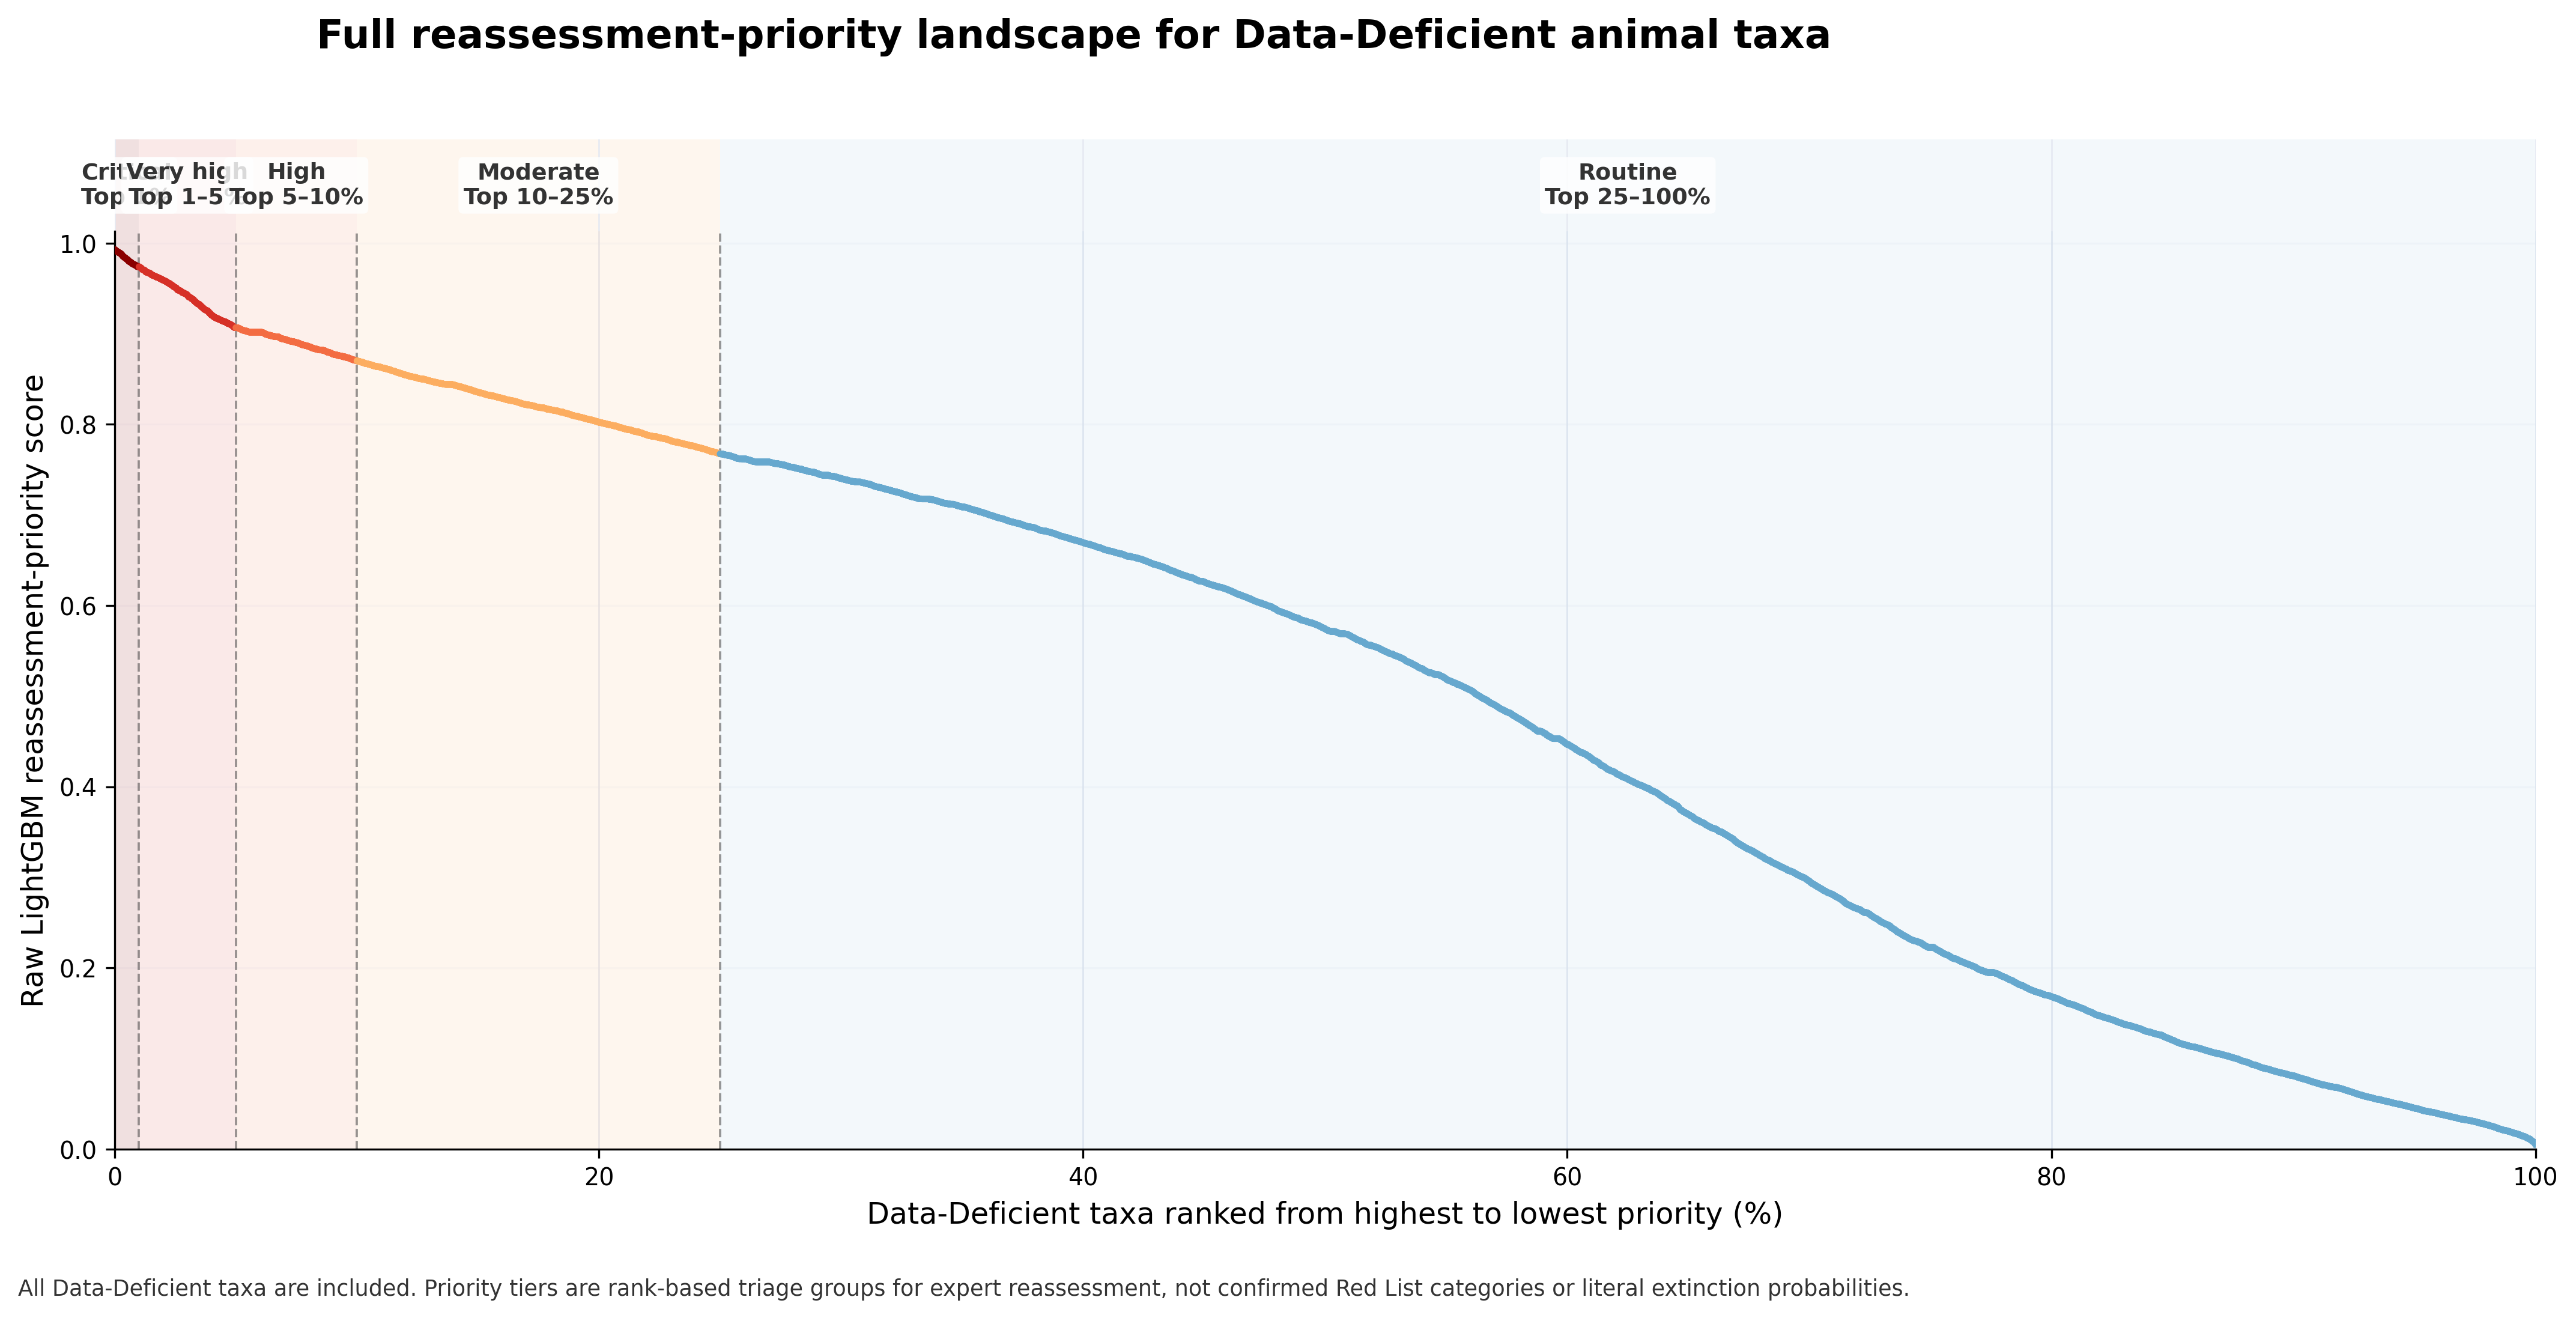

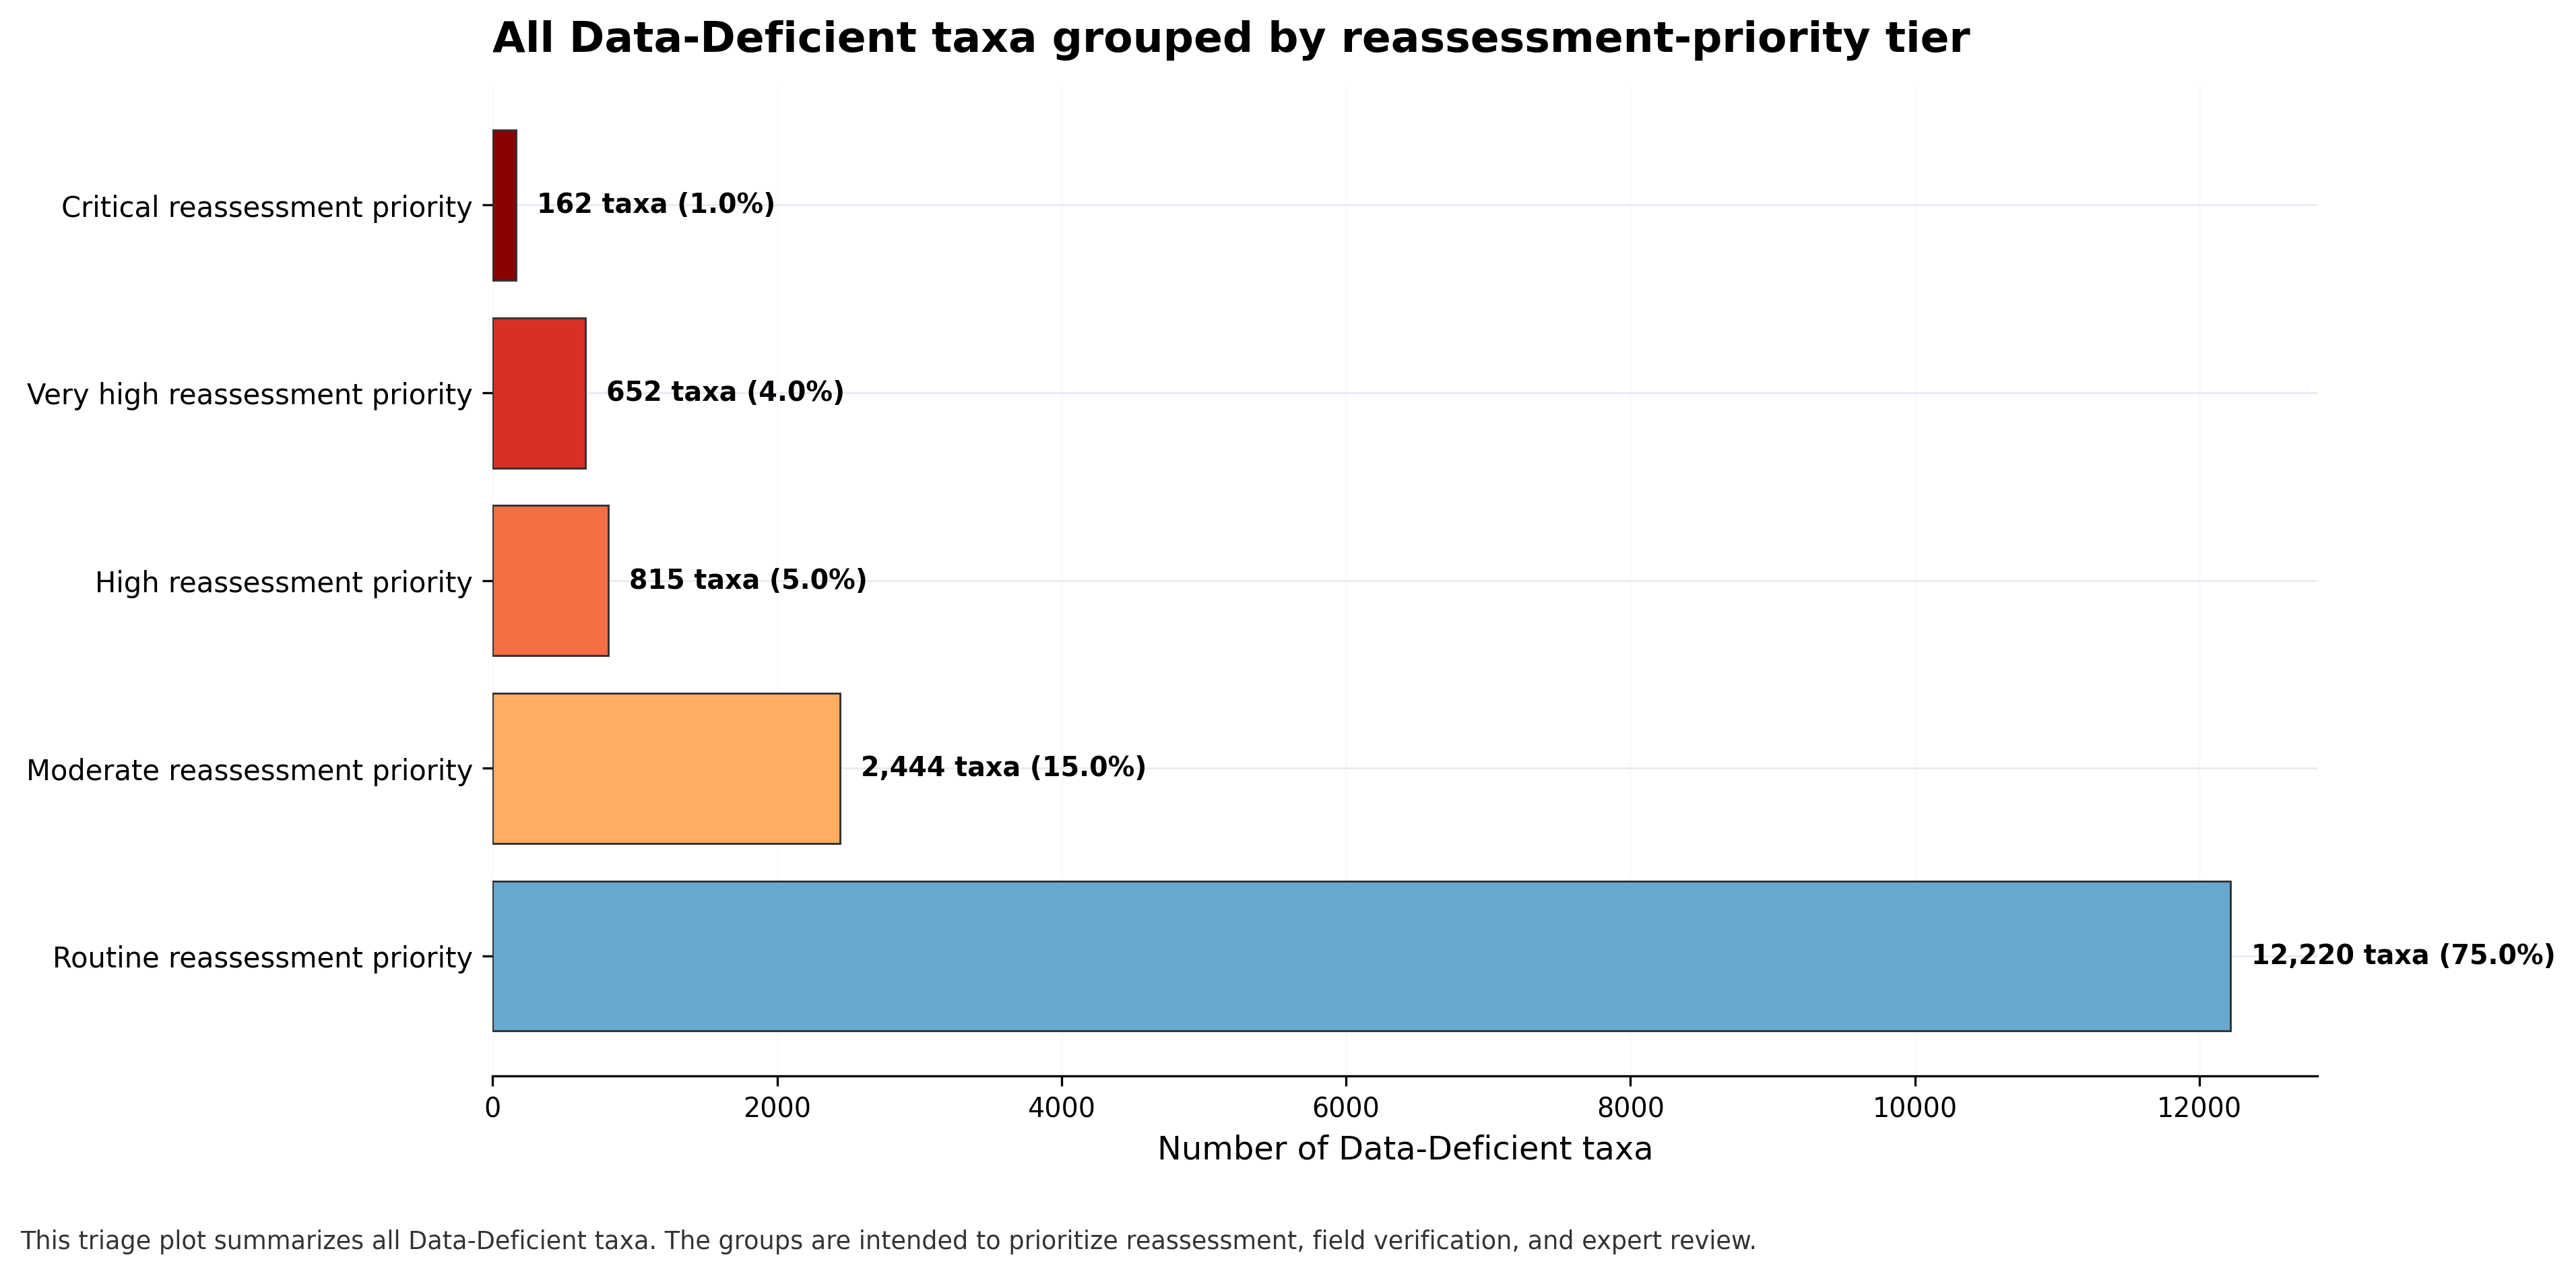

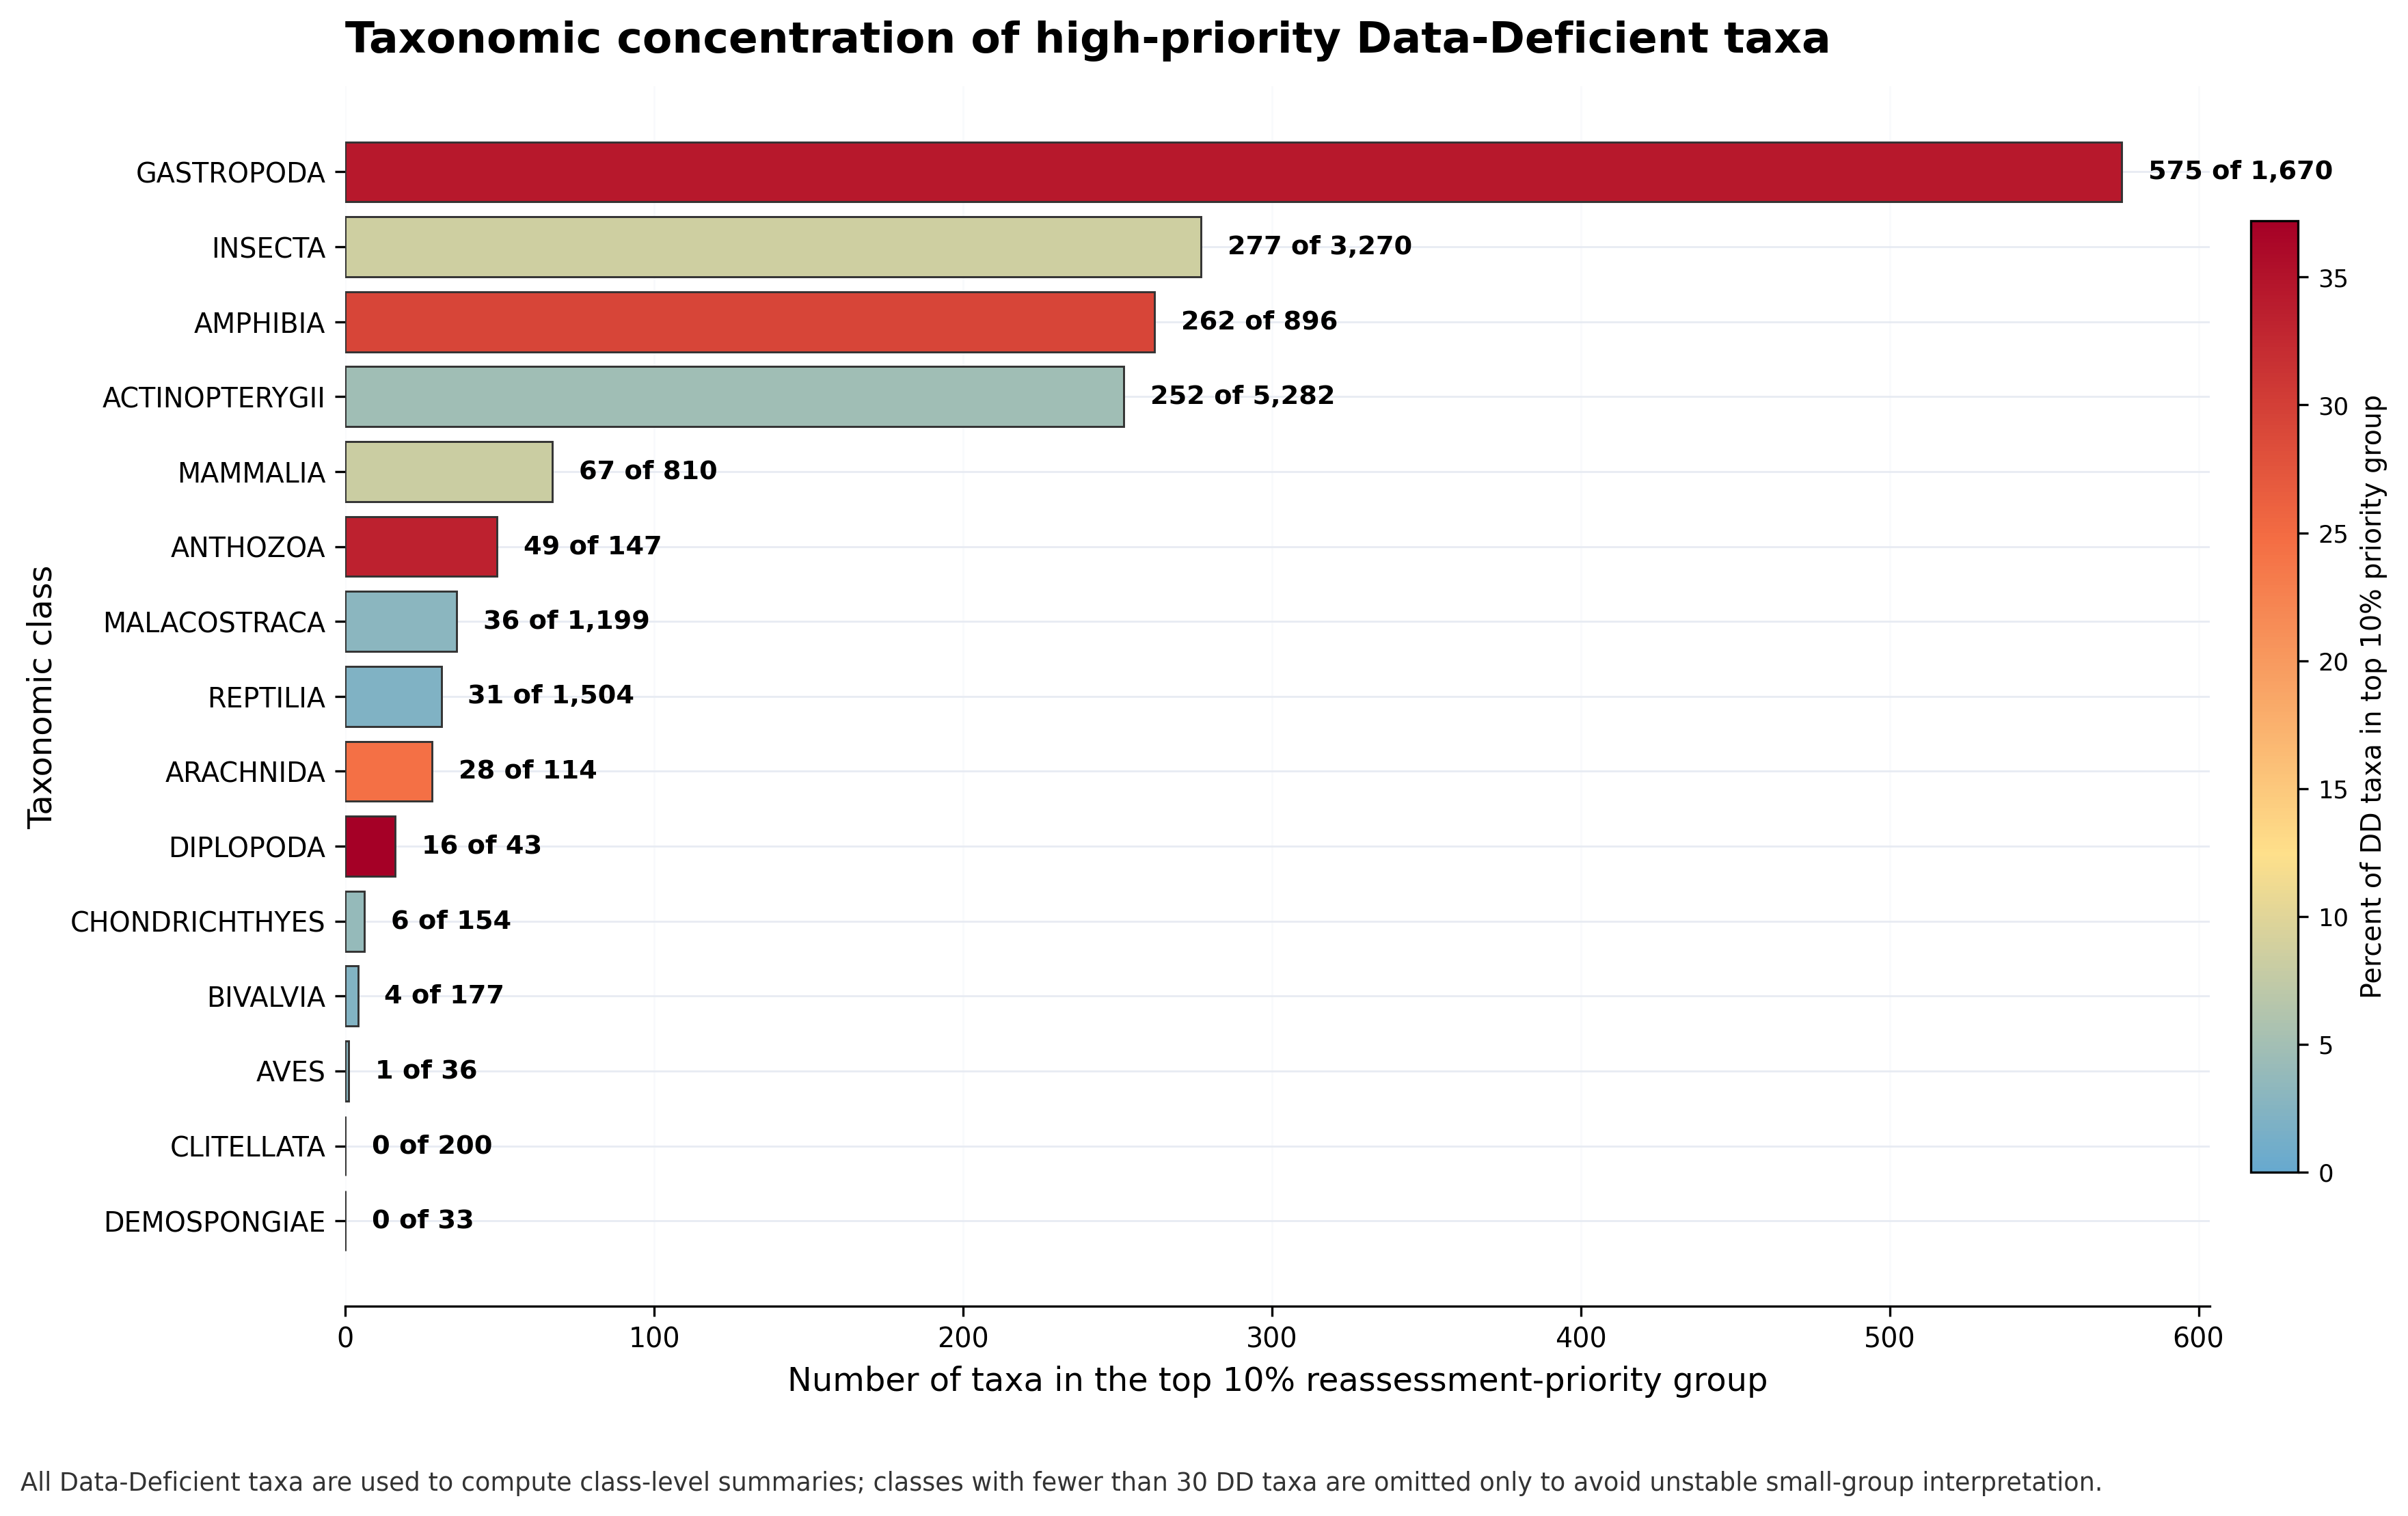



These figures summarize **all Data-Deficient taxa**, not only a small top-ranked subset. They should be interpreted as a **reassessment-priority triage framework**. High-priority taxa may warrant earlier expert reassessment, targeted field surveys, occurrence-record verification, and population-status review. These figures do **not** prescribe species-specific conservation management plans and do **not** estimate literal future extinction probability.


In [ ]:
# ================================================================
# CELL 24 | CONSERVATION IMPLICATIONS: ALL DATA-DEFICIENT TAXA
#          - No table preview
#          - Plot 2 and Plot 3 included
# ================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
from IPython.display import display, Markdown
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

# ------------------------------------------------------------
# 1. Required object
# ------------------------------------------------------------
if "dd_predictions" not in globals():
    raise NameError(
        "dd_predictions was not found. Run the Data-Deficient scoring/ranking cell first."
    )

rec_df = dd_predictions.copy()

# ------------------------------------------------------------
# 2. Output folders
# ------------------------------------------------------------
if "OUT_DIR" in globals():
    OUT_BASE = Path(OUT_DIR)
else:
    OUT_BASE = Path("extinction_risk_outputs")

if "FIG_DIR" in globals():
    FIGOUT = Path(FIG_DIR)
else:
    FIGOUT = OUT_BASE / "figures"

FIGOUT.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 3. Detect raw LightGBM priority-score column
# ------------------------------------------------------------
candidate_score_cols = [
    "raw_lightgbm_priority_score",
    "risk_score_raw",
    "priority_score_raw",
    "lightgbm_raw_score",
    "raw_score",
    "risk_score",
    "priority_score",
]

score_col = None
for c in candidate_score_cols:
    if c in rec_df.columns:
        score_col = c
        break

if score_col is None:
    raise ValueError(
        "Could not find a priority-score column in dd_predictions. "
        "Expected one of: " + ", ".join(candidate_score_cols)
    )

rec_df[score_col] = pd.to_numeric(rec_df[score_col], errors="coerce")
rec_df = rec_df.dropna(subset=[score_col]).copy()

# ------------------------------------------------------------
# 4. Rank all Data-Deficient taxa
# ------------------------------------------------------------
rec_df = rec_df.sort_values(score_col, ascending=False).reset_index(drop=True)

rec_df["priority_rank"] = np.arange(1, len(rec_df) + 1)
rec_df["rank_fraction"] = rec_df["priority_rank"] / len(rec_df)
rec_df["rank_percentile_from_top"] = 100 * rec_df["rank_fraction"]

def assign_priority_tier(rank_fraction):
    if rank_fraction <= 0.01:
        return "Critical reassessment priority"
    elif rank_fraction <= 0.05:
        return "Very high reassessment priority"
    elif rank_fraction <= 0.10:
        return "High reassessment priority"
    elif rank_fraction <= 0.25:
        return "Moderate reassessment priority"
    else:
        return "Routine reassessment priority"

rec_df["reassessment_priority_tier"] = rec_df["rank_fraction"].apply(assign_priority_tier)

tier_order = [
    "Critical reassessment priority",
    "Very high reassessment priority",
    "High reassessment priority",
    "Moderate reassessment priority",
    "Routine reassessment priority",
]

tier_colors = {
    "Critical reassessment priority": "#8B0000",
    "Very high reassessment priority": "#D73027",
    "High reassessment priority": "#F46D43",
    "Moderate reassessment priority": "#FDAE61",
    "Routine reassessment priority": "#67A9CF",
}

print(f"Total Data-Deficient taxa included in reassessment-priority plots: {len(rec_df):,}")
print(f"Score column used: {score_col}")

# ================================================================
# PLOT 1: Full priority-score landscape for ALL DD taxa
# ================================================================

bands = [
    (0, 1, "Critical\nTop 1%", "#8B0000", 0.12),
    (1, 5, "Very high\nTop 1–5%", "#D73027", 0.10),
    (5, 10, "High\nTop 5–10%", "#F46D43", 0.10),
    (10, 25, "Moderate\nTop 10–25%", "#FDAE61", 0.10),
    (25, 100, "Routine\nTop 25–100%", "#67A9CF", 0.08),
]

fig = plt.figure(figsize=(14.4, 7.4), dpi=300)
outer = GridSpec(2, 1, height_ratios=[0.62, 6.2], hspace=0.0, figure=fig)

ax_top = fig.add_subplot(outer[0, 0])
ax = fig.add_subplot(outer[1, 0], sharex=ax_top)

# Background bands in both axes
for x0, x1, label, color, alpha in bands:
    ax_top.axvspan(x0, x1, color=color, alpha=alpha, linewidth=0)
    ax.axvspan(x0, x1, color=color, alpha=alpha, linewidth=0)

# Header strip labels (separate axis = no overlap with plot)
for x0, x1, label, color, alpha in bands:
    xmid = (x0 + x1) / 2
    ax_top.text(
        xmid,
        0.5,
        label,
        ha="center",
        va="center",
        fontsize=9.1,
        fontweight="bold",
        color="#333333",
        bbox=dict(
            boxstyle="round,pad=0.22",
            facecolor="white",
            edgecolor="none",
            alpha=0.82
        )
    )

ax_top.set_xlim(0, 100)
ax_top.set_ylim(0, 1)
ax_top.set_yticks([])
ax_top.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
for spine in ["top", "right", "left", "bottom"]:
    ax_top.spines[spine].set_visible(False)

# Main curve data
x = rec_df["rank_percentile_from_top"].values
y = rec_df[score_col].values
scatter_colors = rec_df["reassessment_priority_tier"].map(tier_colors).values

# Smooth rank curve + dense scatter
ax.plot(
    x,
    y,
    color="#262626",
    linewidth=1.7,
    alpha=0.9,
    zorder=3
)

ax.scatter(
    x,
    y,
    c=scatter_colors,
    s=7,
    alpha=0.62,
    linewidths=0,
    zorder=4
)

# Tier cut lines
for cutoff in [1, 5, 10, 25]:
    ax.axvline(
        cutoff,
        color="#444444",
        linestyle="--",
        linewidth=0.9,
        alpha=0.55,
        zorder=2
    )

ax.set_xlim(0, 100)
ax.set_ylim(max(0, y.min() - 0.04), min(1.02, y.max() + 0.02))

ax.set_xlabel(
    "Data-Deficient taxa ranked from highest to lowest priority (%)",
    fontsize=11.8
)
ax.set_ylabel(
    "Raw LightGBM reassessment-priority score",
    fontsize=11.8
)

fig.suptitle(
    "Full reassessment-priority landscape for Data-Deficient animal taxa",
    fontsize=15.8,
    fontweight="bold",
    x=0.125,
    ha="left",
    y=0.97
)

ax.grid(axis="y", alpha=0.22, linewidth=0.8)
ax.set_axisbelow(True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.text(
    0.01,
    0.012,
    "All Data-Deficient taxa are included. Priority tiers are rank-based triage groups for expert reassessment, "
    "not confirmed Red List categories or literal extinction probabilities.",
    fontsize=8.8,
    color="#333333"
)

out_png = FIGOUT / "figure_10_all_dd_priority_score_landscape_finalclean.png"
out_pdf = FIGOUT / "figure_10_all_dd_priority_score_landscape_finalclean.pdf"

fig.tight_layout(rect=[0, 0.04, 1, 0.95])
fig.savefig(out_png, dpi=450, bbox_inches="tight", facecolor="white")
fig.savefig(out_pdf, bbox_inches="tight", facecolor="white")
plt.show()


# ================================================================
# PLOT 2: Full DD reassessment-priority tier distribution
# ================================================================

tier_summary = (
    rec_df["reassessment_priority_tier"]
    .value_counts()
    .reindex(tier_order)
    .fillna(0)
    .astype(int)
    .reset_index()
)

tier_summary.columns = ["reassessment_priority_tier", "n_taxa"]
tier_summary["percent"] = 100 * tier_summary["n_taxa"] / tier_summary["n_taxa"].sum()

fig, ax = plt.subplots(figsize=(12.8, 6.3), dpi=300)

plot_df = tier_summary.copy()
bar_colors = [tier_colors[t] for t in plot_df["reassessment_priority_tier"]]
y_pos = np.arange(len(plot_df))

ax.barh(
    y_pos,
    plot_df["n_taxa"],
    color=bar_colors,
    edgecolor="#333333",
    linewidth=0.7
)

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["reassessment_priority_tier"], fontsize=10)
ax.invert_yaxis()

ax.set_xlabel("Number of Data-Deficient taxa", fontsize=11.5)

ax.set_title(
    "All Data-Deficient taxa grouped by reassessment-priority tier",
    fontsize=15.2,
    fontweight="bold",
    loc="left",
    pad=12
)

for i, row in plot_df.iterrows():
    ax.text(
        row["n_taxa"] + max(plot_df["n_taxa"]) * 0.012,
        i,
        f"{int(row['n_taxa']):,} taxa ({row['percent']:.1f}%)",
        va="center",
        ha="left",
        fontsize=9.5,
        fontweight="bold"
    )

ax.grid(axis="x", alpha=0.22, linewidth=0.8)
ax.set_axisbelow(True)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

fig.text(
    0.01,
    0.01,
    "This triage plot summarizes all Data-Deficient taxa. The groups are intended to prioritize reassessment, "
    "field verification, and expert review.",
    fontsize=8.8,
    color="#333333"
)

out_png = FIGOUT / "figure_11_all_dd_reassessment_priority_tiers_finalclean.png"
out_pdf = FIGOUT / "figure_11_all_dd_reassessment_priority_tiers_finalclean.pdf"

fig.tight_layout(rect=[0, 0.05, 1, 1])
fig.savefig(out_png, dpi=450, bbox_inches="tight", facecolor="white")
fig.savefig(out_pdf, bbox_inches="tight", facecolor="white")
plt.show()


# ================================================================
# PLOT 3: Taxonomic concentration using ALL DD taxa
#         Shows class-level burden and high-priority share
# ================================================================

if "class" in rec_df.columns:

    class_summary = (
        rec_df.dropna(subset=["class"])
        .groupby("class")
        .agg(
            n_dd_taxa=("priority_rank", "size"),
            n_top10_priority=("rank_fraction", lambda s: int((s <= 0.10).sum())),
            median_priority_score=(score_col, "median")
        )
        .reset_index()
    )

    class_summary["top10_priority_percent"] = (
        100 * class_summary["n_top10_priority"] / class_summary["n_dd_taxa"]
    )

    # Filter tiny groups to avoid unstable interpretation
    class_summary = class_summary[class_summary["n_dd_taxa"] >= 30].copy()

    class_summary = class_summary.sort_values(
        ["n_top10_priority", "median_priority_score"],
        ascending=[False, False]
    ).head(15)

    class_summary = class_summary.sort_values("n_top10_priority", ascending=True)

    fig, ax = plt.subplots(figsize=(12.8, 7.4), dpi=300)

    color_norm = mpl.colors.Normalize(
        vmin=class_summary["top10_priority_percent"].min(),
        vmax=class_summary["top10_priority_percent"].max()
    )

    cmap = mpl.colors.LinearSegmentedColormap.from_list(
        "class_priority",
        ["#67A9CF", "#FEE08B", "#F46D43", "#A50026"],
        N=256
    )

    colors = cmap(color_norm(class_summary["top10_priority_percent"].values))

    ax.barh(
        class_summary["class"],
        class_summary["n_top10_priority"],
        color=colors,
        edgecolor="#333333",
        linewidth=0.7
    )

    for i, row in enumerate(class_summary.itertuples()):
        ax.text(
            row.n_top10_priority + max(class_summary["n_top10_priority"]) * 0.015,
            i,
            f"{int(row.n_top10_priority):,} of {int(row.n_dd_taxa):,}",
            va="center",
            ha="left",
            fontsize=9.2,
            fontweight="bold"
        )

    ax.set_xlabel("Number of taxa in the top 10% reassessment-priority group", fontsize=11.5)
    ax.set_ylabel("Taxonomic class", fontsize=11.5)

    ax.set_title(
        "Taxonomic concentration of high-priority Data-Deficient taxa",
        fontsize=15.2,
        fontweight="bold",
        loc="left",
        pad=12
    )

    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=color_norm)
    sm.set_array([])

    cb = fig.colorbar(sm, ax=ax, pad=0.018, shrink=0.78)
    cb.set_label("Percent of DD taxa in top 10% priority group", fontsize=9.5)
    cb.ax.tick_params(labelsize=8.5)

    ax.grid(axis="x", alpha=0.22)
    ax.set_axisbelow(True)

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    fig.text(
        0.01,
        0.01,
        "All Data-Deficient taxa are used to compute class-level summaries; classes with fewer than 30 DD taxa are omitted "
        "only to avoid unstable small-group interpretation.",
        fontsize=8.8,
        color="#333333"
    )

    out_png = FIGOUT / "figure_12_all_dd_taxonomic_priority_concentration_finalclean.png"
    out_pdf = FIGOUT / "figure_12_all_dd_taxonomic_priority_concentration_finalclean.pdf"

    fig.tight_layout(rect=[0, 0.05, 1, 1])
    fig.savefig(out_png, dpi=450, bbox_inches="tight", facecolor="white")
    fig.savefig(out_pdf, bbox_inches="tight", facecolor="white")
    plt.show()


else:
    print("Skipped taxonomic class plot because column 'class' was not found.")

# ------------------------------------------------------------
# ------------------------------------------------------------
display(Markdown(
"""

These figures summarize **all Data-Deficient taxa**, not only a small top-ranked subset. They should be interpreted as a **reassessment-priority triage framework**. High-priority taxa may warrant earlier expert reassessment, targeted field surveys, occurrence-record verification, and population-status review. These figures do **not** prescribe species-specific conservation management plans and do **not** estimate literal future extinction probability.
"""
))

# **CELL 25: CONSERVATION ACTION CONTEXT FOR REASSESSMENT CANDIDATES**

Action columns found in df_labeled: 6
Threat columns found in df_labeled: 12
Assessed threatened taxa: 19,066
Assessed non-threatened taxa: 59,675
Total Data-Deficient taxa scored: 16,293
Top 10% high-priority DD taxa: 1,629
Score column used: priority_score_raw


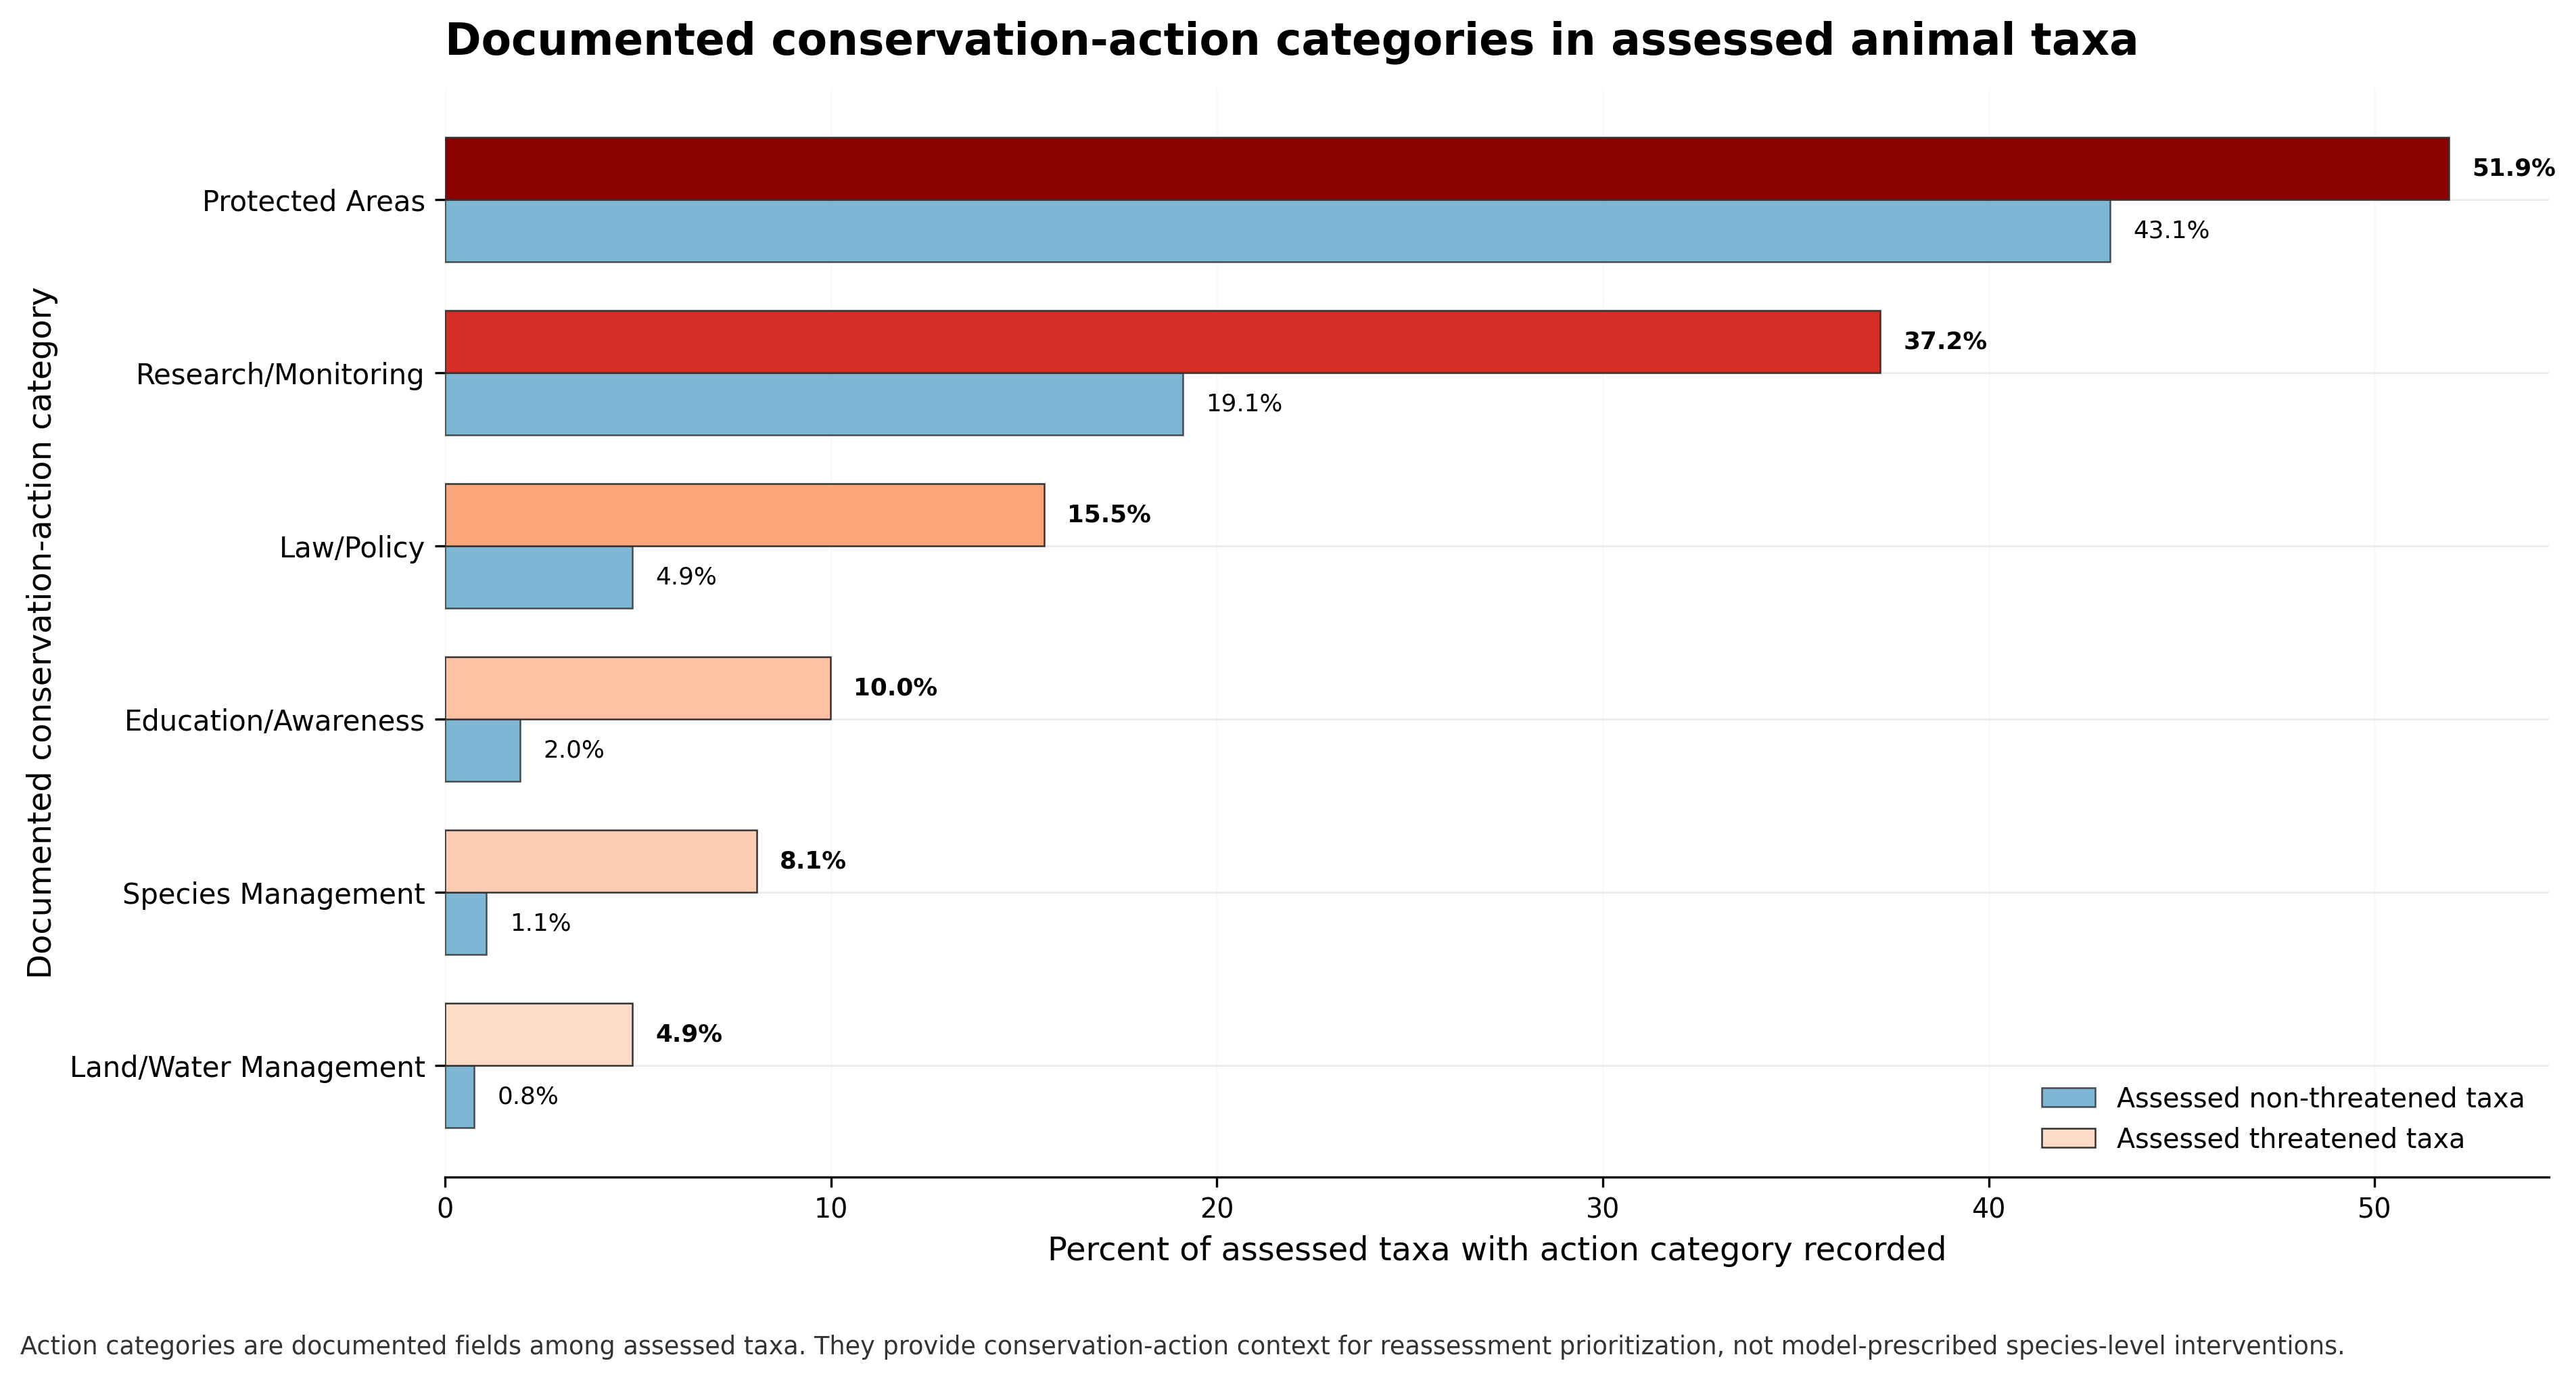

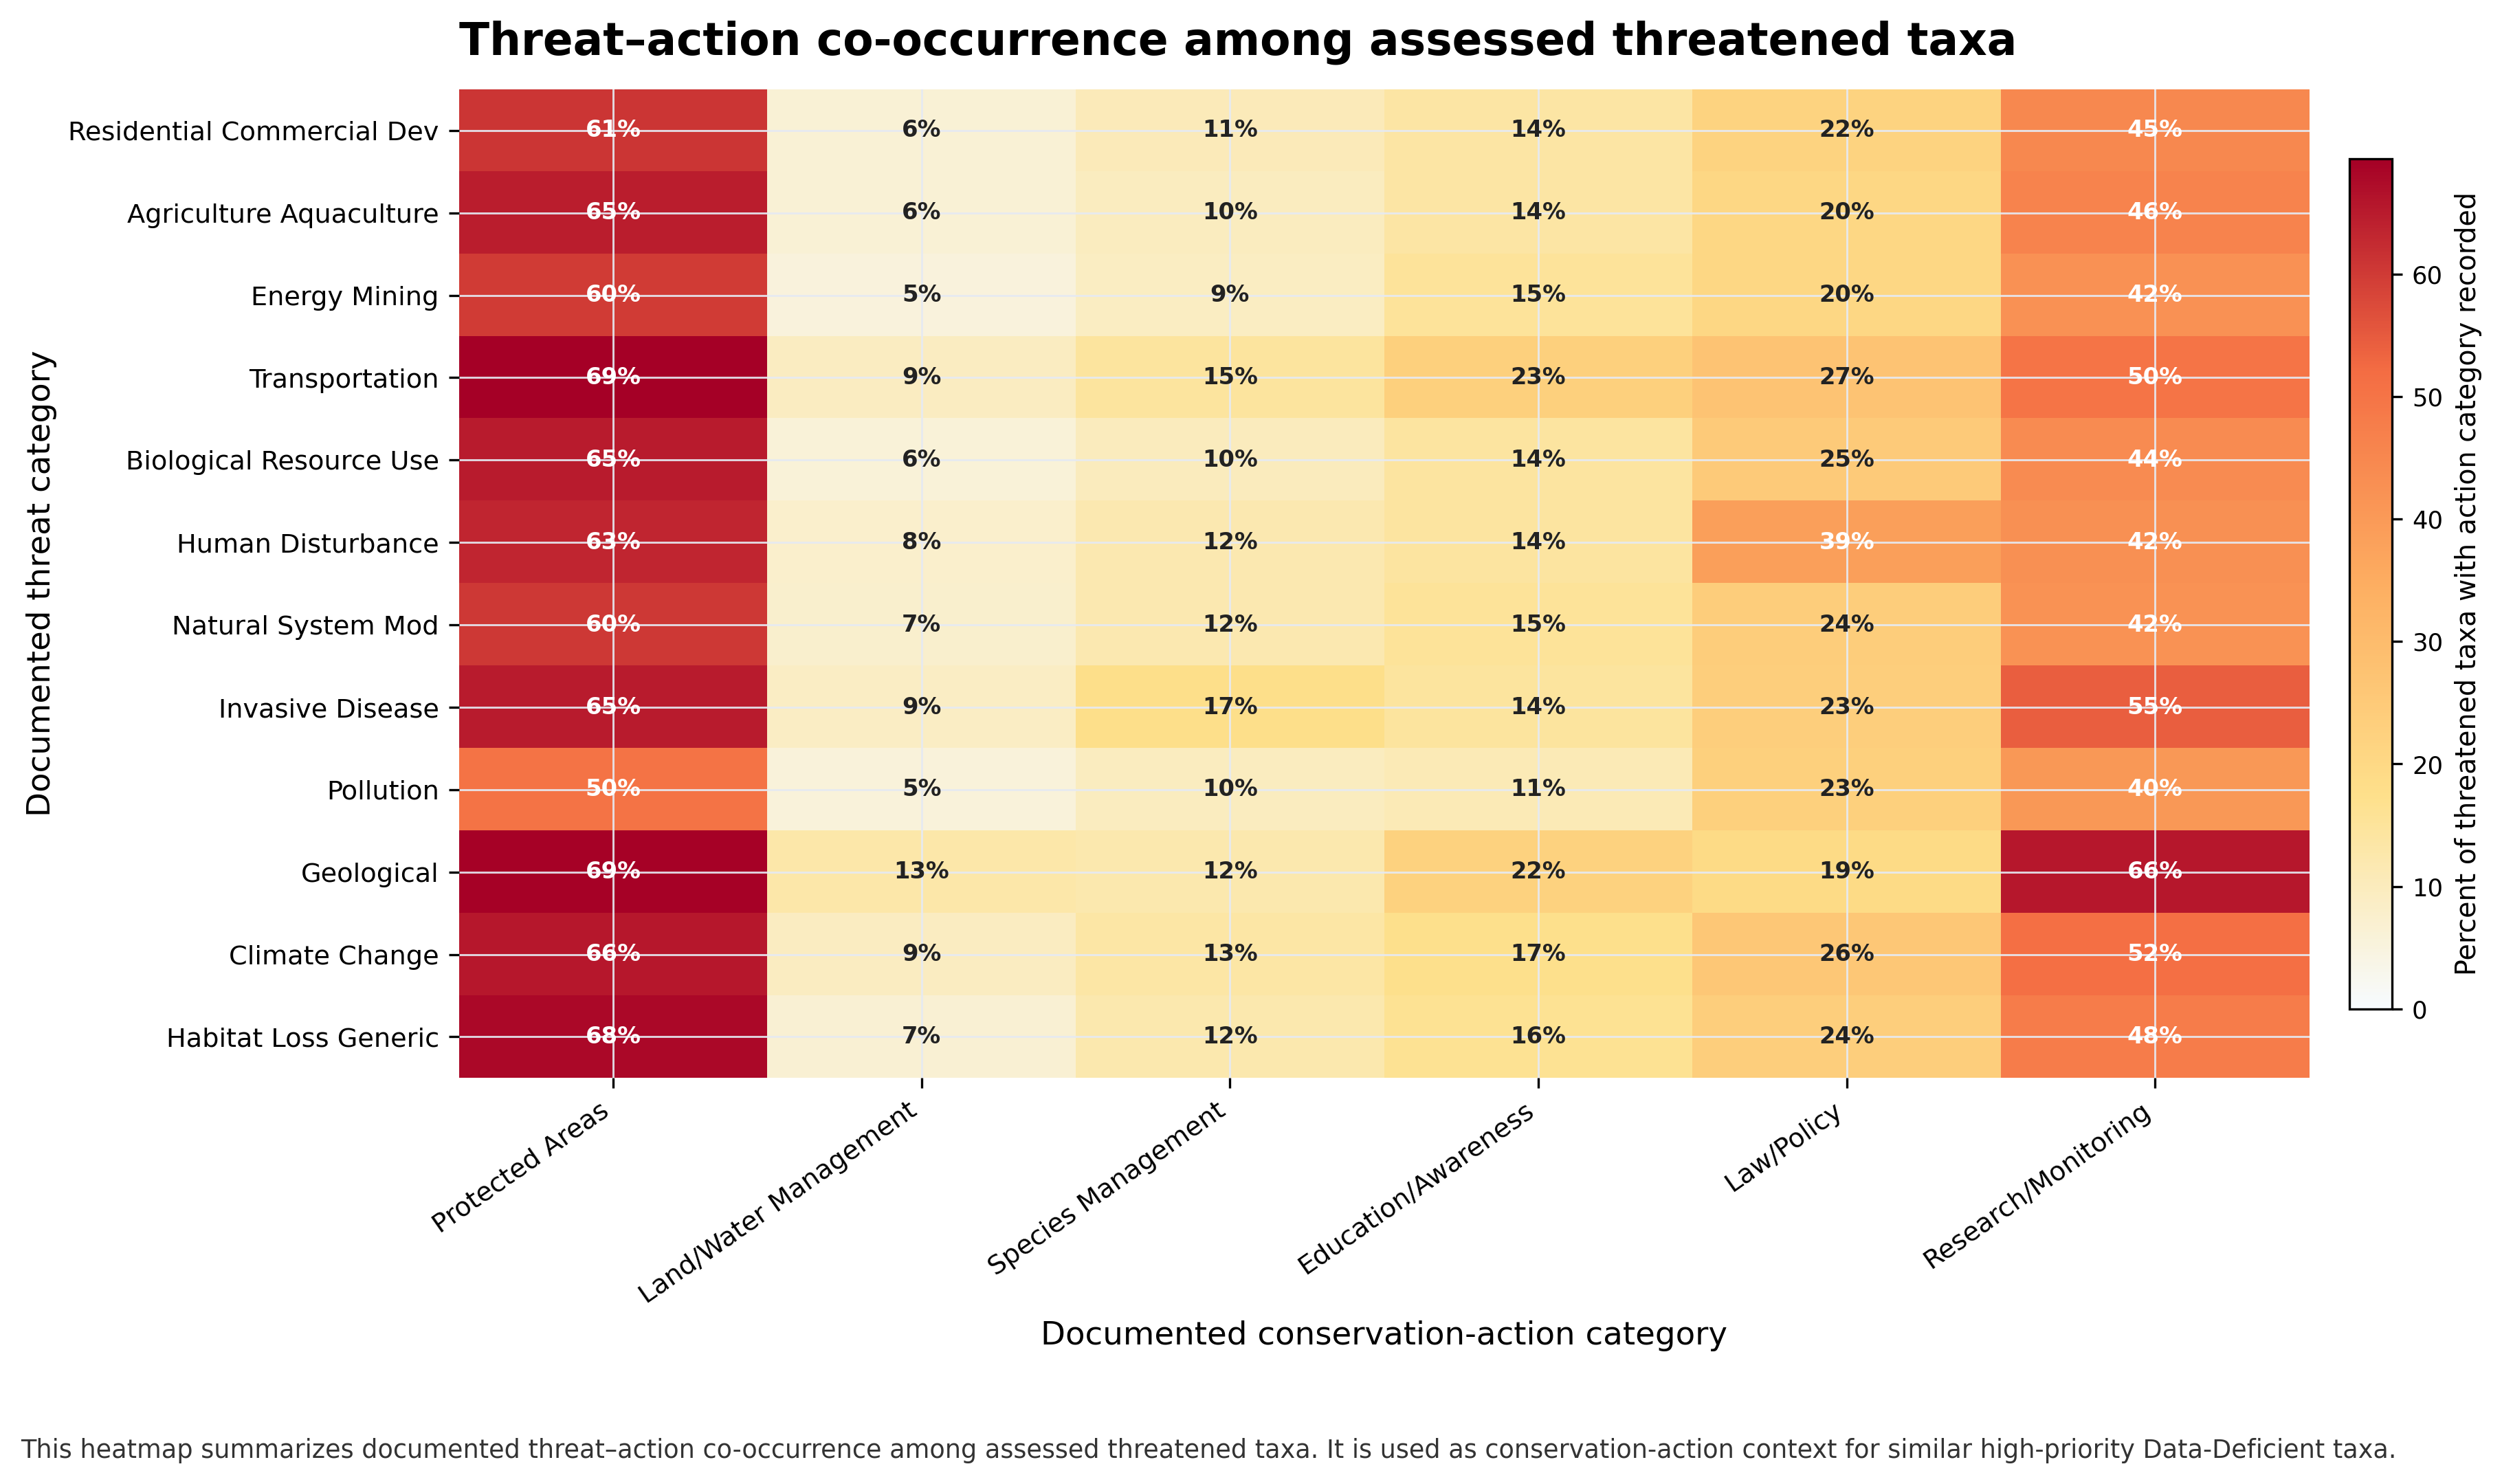

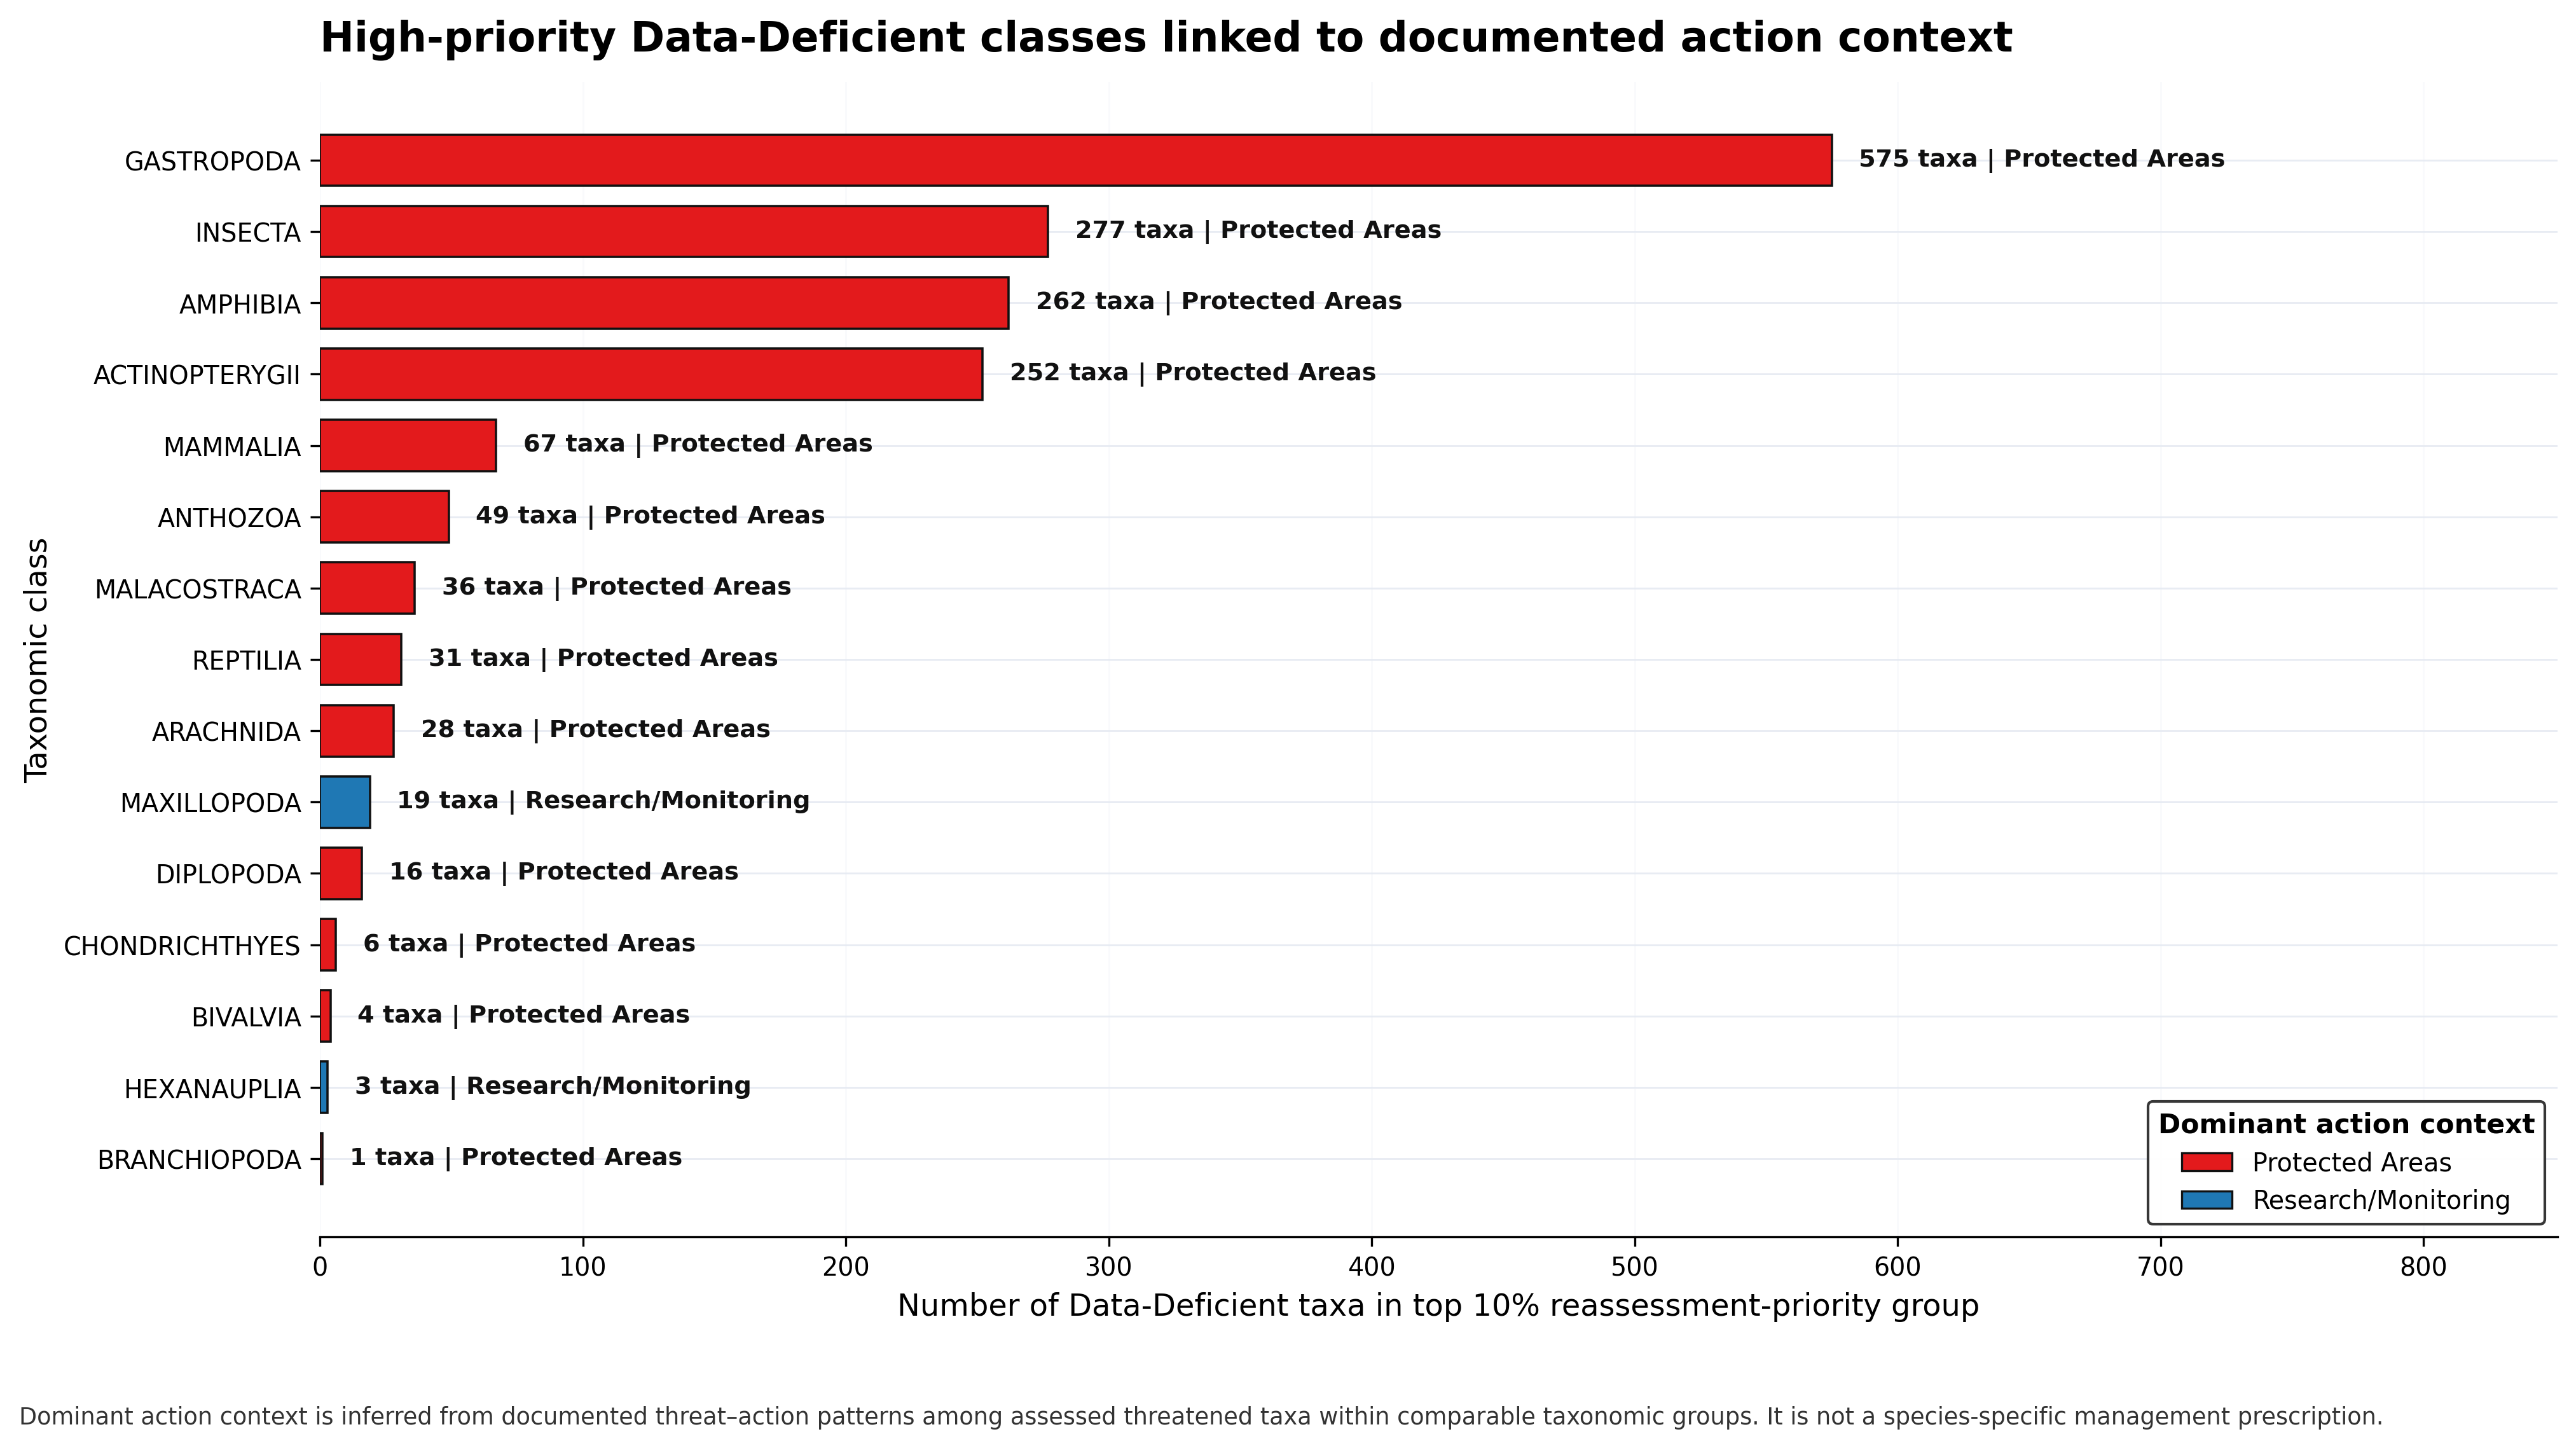



These figures use documented conservation-action and threat fields from assessed taxa to provide **conservation-action context** for Data-Deficient reassessment prioritization. They do not assign definitive Red List categories and do not prescribe species-specific management plans.

The strongest interpretation is that high-priority Data-Deficient taxa may warrant earlier expert reassessment, targeted evidence collection, and review of relevant conservation-action contexts such as protected areas, land/water management, species management, law/policy, education/awareness, and research/monitoring.


In [ ]:
# ================================================================
# CELL 25 | CONSERVATION-ACTION CONTEXT FOR REASSESSMENT PRIORITIES
#
#
# This cell uses documented action/threat fields from assessed labeled taxa
# to provide conservation-action CONTEXT for high-priority Data-Deficient taxa.
#
# It does NOT claim that the model prescribes exact species-level management plans.
# ================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
from IPython.display import display, Markdown

# ------------------------------------------------------------
# 1. Required objects
# ------------------------------------------------------------
if "df_labeled" not in globals():
    raise NameError("df_labeled was not found. Run the data preparation cells first.")

if "dd_predictions" not in globals():
    raise NameError("dd_predictions was not found. Run the DD scoring/ranking cells first.")

if "TARGET" not in globals():
    TARGET = "target_threatened_extant"

# ------------------------------------------------------------
# 2. Output folder
# ------------------------------------------------------------
if "OUT_DIR" in globals():
    OUT_BASE = Path(OUT_DIR)
else:
    OUT_BASE = Path("extinction_risk_outputs")

if "FIG_DIR" in globals():
    FIGOUT = Path(FIG_DIR)
else:
    FIGOUT = OUT_BASE / "figures"

FIGOUT.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 3. Identify action and threat columns from labeled assessed taxa
# ------------------------------------------------------------
ACTION_COLS = [c for c in df_labeled.columns if c.startswith("target_action_")]
THREAT_COLS = [c for c in df_labeled.columns if c.startswith("target_threat_")]

print(f"Action columns found in df_labeled: {len(ACTION_COLS)}")
print(f"Threat columns found in df_labeled: {len(THREAT_COLS)}")

if len(ACTION_COLS) == 0:
    raise ValueError("No target_action_* columns were found in df_labeled.")

def readable_action(col):
    label = (
        col.replace("target_action_", "")
           .replace("_", " ")
           .replace("mgmt", "management")
           .title()
           .strip()
    )

    # Standardize common names
    label = label.replace("Land Water Management", "Land/Water Management")
    label = label.replace("Education Awareness", "Education/Awareness")
    label = label.replace("Law Policy", "Law/Policy")
    label = label.replace("Research Monitoring", "Research/Monitoring")

    return label

def readable_threat(col):
    return (
        col.replace("target_threat_", "")
           .replace("_", " ")
           .replace(" Generic", "")
           .title()
           .strip()
    )

ACTION_LABELS = {c: readable_action(c) for c in ACTION_COLS}
THREAT_LABELS = {c: readable_threat(c) for c in THREAT_COLS}

# ------------------------------------------------------------
# 4. Labeled assessed threatened vs non-threatened groups
# ------------------------------------------------------------
work_labeled = df_labeled.copy()
work_labeled[TARGET] = pd.to_numeric(work_labeled[TARGET], errors="coerce")

threatened_df = work_labeled[work_labeled[TARGET].astype(float).eq(1)].copy()
nonthreat_df = work_labeled[work_labeled[TARGET].astype(float).eq(0)].copy()

print(f"Assessed threatened taxa: {len(threatened_df):,}")
print(f"Assessed non-threatened taxa: {len(nonthreat_df):,}")

# Convert action/threat columns to numeric binary-like values
for c in ACTION_COLS + THREAT_COLS:
    work_labeled[c] = pd.to_numeric(work_labeled[c], errors="coerce")

for c in ACTION_COLS:
    threatened_df[c] = pd.to_numeric(threatened_df[c], errors="coerce").fillna(0).clip(0, 1)
    nonthreat_df[c] = pd.to_numeric(nonthreat_df[c], errors="coerce").fillna(0).clip(0, 1)

for c in THREAT_COLS:
    threatened_df[c] = pd.to_numeric(threatened_df[c], errors="coerce").fillna(0).clip(0, 1)

# ------------------------------------------------------------
# 5. Detect DD priority-score column
# ------------------------------------------------------------
dd_df = dd_predictions.copy()

candidate_score_cols = [
    "raw_lightgbm_priority_score",
    "risk_score_raw",
    "priority_score_raw",
    "lightgbm_raw_score",
    "raw_score",
    "risk_score",
    "priority_score",
]

score_col = None
for c in candidate_score_cols:
    if c in dd_df.columns:
        score_col = c
        break

if score_col is None:
    raise ValueError(
        "Could not find a priority-score column in dd_predictions. "
        "Expected one of: " + ", ".join(candidate_score_cols)
    )

dd_df[score_col] = pd.to_numeric(dd_df[score_col], errors="coerce")
dd_df = dd_df.dropna(subset=[score_col]).copy()
dd_df = dd_df.sort_values(score_col, ascending=False).reset_index(drop=True)

dd_df["priority_rank"] = np.arange(1, len(dd_df) + 1)
dd_df["rank_fraction"] = dd_df["priority_rank"] / len(dd_df)

top10_dd = dd_df[dd_df["rank_fraction"] <= 0.10].copy()

print(f"Total Data-Deficient taxa scored: {len(dd_df):,}")
print(f"Top 10% high-priority DD taxa: {len(top10_dd):,}")
print(f"Score column used: {score_col}")

# ================================================================
# PLOT 1 | Conservation-action prevalence in assessed taxa
# ================================================================

action_prev_threat = (
    threatened_df[ACTION_COLS]
    .fillna(0)
    .astype(float)
    .mean()
    .rename(ACTION_LABELS)
    .sort_values(ascending=True)
)

action_prev_nonthreat = (
    nonthreat_df[ACTION_COLS]
    .fillna(0)
    .astype(float)
    .mean()
    .rename(ACTION_LABELS)
    .reindex(action_prev_threat.index)
)

fig, ax = plt.subplots(figsize=(12.8, 6.8), dpi=300)

y_pos = np.arange(len(action_prev_threat))
bar_h = 0.36

cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "action_red",
    ["#FDDBC7", "#FC8D59", "#D73027", "#8B0000"],
    N=256
)

norm = mpl.colors.Normalize(
    vmin=action_prev_threat.min(),
    vmax=max(action_prev_threat.max(), 0.01)
)

threat_colors = cmap(norm(action_prev_threat.values))

ax.barh(
    y_pos - bar_h / 2,
    action_prev_nonthreat.values * 100,
    height=bar_h,
    color="#67A9CF",
    edgecolor="#333333",
    linewidth=0.6,
    alpha=0.85,
    label="Assessed non-threatened taxa"
)

ax.barh(
    y_pos + bar_h / 2,
    action_prev_threat.values * 100,
    height=bar_h,
    color=threat_colors,
    edgecolor="#333333",
    linewidth=0.6,
    label="Assessed threatened taxa"
)

ax.set_yticks(y_pos)
ax.set_yticklabels(action_prev_threat.index, fontsize=10)

for i, label in enumerate(action_prev_threat.index):
    nt_val = action_prev_nonthreat.loc[label] * 100
    th_val = action_prev_threat.loc[label] * 100

    ax.text(
        nt_val + 0.6,
        i - bar_h / 2,
        f"{nt_val:.1f}%",
        va="center",
        ha="left",
        fontsize=8.6
    )

    ax.text(
        th_val + 0.6,
        i + bar_h / 2,
        f"{th_val:.1f}%",
        va="center",
        ha="left",
        fontsize=8.6,
        fontweight="bold"
    )

ax.set_xlabel("Percent of assessed taxa with action category recorded", fontsize=11.5)
ax.set_ylabel("Documented conservation-action category", fontsize=11.5)

ax.set_title(
    "Documented conservation-action categories in assessed animal taxa",
    fontsize=15.5,
    fontweight="bold",
    loc="left",
    pad=12
)

ax.legend(frameon=False, fontsize=9.5, loc="lower right")

ax.grid(axis="x", alpha=0.22)
ax.set_axisbelow(True)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

fig.text(
    0.01,
    0.01,
    "Action categories are documented fields among assessed taxa. "
    "They provide conservation-action context for reassessment prioritization, not model-prescribed species-level interventions.",
    fontsize=8.8,
    color="#333333"
)

out_png = FIGOUT / "figure_13_assessed_action_prevalence_context.png"
out_pdf = FIGOUT / "figure_13_assessed_action_prevalence_context.pdf"

fig.tight_layout(rect=[0, 0.05, 1, 1])
fig.savefig(out_png, dpi=450, bbox_inches="tight", facecolor="white")
fig.savefig(out_pdf, bbox_inches="tight", facecolor="white")
plt.show()


# ================================================================
# PLOT 2 | Threat-action co-occurrence among assessed threatened taxa
# ================================================================

if len(THREAT_COLS) > 0:

    threat_action = pd.DataFrame(
        index=[THREAT_LABELS[c] for c in THREAT_COLS],
        columns=[ACTION_LABELS[c] for c in ACTION_COLS],
        dtype=float
    )

    for tc in THREAT_COLS:
        threat_label = THREAT_LABELS[tc]
        mask = threatened_df[tc].fillna(0).astype(float).gt(0)
        sub = threatened_df[mask]

        for ac in ACTION_COLS:
            action_label = ACTION_LABELS[ac]

            if len(sub) > 0:
                threat_action.loc[threat_label, action_label] = (
                    sub[ac].fillna(0).astype(float).mean()
                )
            else:
                threat_action.loc[threat_label, action_label] = np.nan

    threat_action = threat_action.fillna(0)

    # Remove empty threat rows
    threat_action = threat_action.loc[threat_action.sum(axis=1) > 0].copy()

    fig, ax = plt.subplots(figsize=(13.2, 7.2), dpi=300)

    heat_values = threat_action.values * 100

    heat_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        "threat_action_heat",
        ["#F7FBFF", "#FEE08B", "#FDAE61", "#F46D43", "#A50026"],
        N=256
    )

    vmax = np.nanmax(heat_values)
    if not np.isfinite(vmax) or vmax <= 0:
        vmax = 1

    im = ax.imshow(
        heat_values,
        aspect="auto",
        cmap=heat_cmap,
        vmin=0,
        vmax=vmax
    )

    ax.set_xticks(np.arange(len(threat_action.columns)))
    ax.set_xticklabels(
        threat_action.columns,
        rotation=35,
        ha="right",
        fontsize=9.2
    )

    ax.set_yticks(np.arange(len(threat_action.index)))
    ax.set_yticklabels(threat_action.index, fontsize=9.2)

    for i in range(heat_values.shape[0]):
        for j in range(heat_values.shape[1]):
            val = heat_values[i, j]

            if val >= 1:
                text_color = "white" if val > vmax * 0.55 else "#222222"

                ax.text(
                    j,
                    i,
                    f"{val:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=8.1,
                    fontweight="bold",
                    color=text_color
                )

    ax.set_title(
        "Threat–action co-occurrence among assessed threatened taxa",
        fontsize=15.5,
        fontweight="bold",
        loc="left",
        pad=12
    )

    ax.set_xlabel("Documented conservation-action category", fontsize=11.2)
    ax.set_ylabel("Documented threat category", fontsize=11.2)

    cb = fig.colorbar(im, ax=ax, pad=0.018, shrink=0.86)
    cb.set_label("Percent of threatened taxa with action category recorded", fontsize=9.5)
    cb.ax.tick_params(labelsize=8.5)

    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)

    fig.text(
        0.01,
        0.01,
        "This heatmap summarizes documented threat–action co-occurrence among assessed threatened taxa. "
        "It is used as conservation-action context for similar high-priority Data-Deficient taxa.",
        fontsize=8.8,
        color="#333333"
    )

    out_png = FIGOUT / "figure_14_threat_action_cooccurrence_context.png"
    out_pdf = FIGOUT / "figure_14_threat_action_cooccurrence_context.pdf"

    fig.tight_layout(rect=[0, 0.06, 1, 1])
    fig.savefig(out_png, dpi=450, bbox_inches="tight", facecolor="white")
    fig.savefig(out_pdf, bbox_inches="tight", facecolor="white")
    plt.show()


else:
    print("Skipped threat-action heatmap because no target_threat_* columns were found.")

# ================================================================
# PLOT 3 | High-priority DD classes and dominant action context
#          HIGH-CONTRAST VERSION
# ================================================================

if "class" in top10_dd.columns and len(THREAT_COLS) > 0:

    # ------------------------------------------------------------
    # Dominant threat by class among assessed threatened taxa
    # ------------------------------------------------------------
    class_dominant_threat = {}

    for cls in top10_dd["class"].dropna().unique():
        sub = threatened_df[threatened_df["class"] == cls]

        if len(sub) > 0:
            threat_means = sub[THREAT_COLS].fillna(0).astype(float).mean()

            if threat_means.max() > 0:
                dominant_threat_col = threat_means.idxmax()
                class_dominant_threat[cls] = THREAT_LABELS[dominant_threat_col]
            else:
                class_dominant_threat[cls] = "Insufficient threat evidence"
        else:
            class_dominant_threat[cls] = "Insufficient threat evidence"

    # ------------------------------------------------------------
    # Most common action by threat among assessed threatened taxa
    # ------------------------------------------------------------
    threat_to_action = {}

    for tc in THREAT_COLS:
        threat_label = THREAT_LABELS[tc]
        mask = threatened_df[tc].fillna(0).astype(float).gt(0)
        sub = threatened_df[mask]

        if len(sub) > 0:
            action_means = sub[ACTION_COLS].fillna(0).astype(float).mean()

            if action_means.max() > 0:
                dominant_action_col = action_means.idxmax()
                threat_to_action[threat_label] = ACTION_LABELS[dominant_action_col]
            else:
                threat_to_action[threat_label] = "Research/Monitoring"
        else:
            threat_to_action[threat_label] = "Research/Monitoring"

    class_summary = (
        top10_dd.dropna(subset=["class"])
        .groupby("class")
        .agg(
            n_top_priority_dd=("priority_rank", "size"),
            median_priority_score=(score_col, "median")
        )
        .reset_index()
    )

    class_summary["dominant_threat_context"] = class_summary["class"].map(class_dominant_threat)

    class_summary["dominant_action_context"] = (
        class_summary["dominant_threat_context"]
        .map(threat_to_action)
        .fillna("Research/Monitoring")
    )

    class_summary = (
        class_summary
        .sort_values(["n_top_priority_dd", "median_priority_score"], ascending=[False, False])
        .head(15)
        .sort_values("n_top_priority_dd", ascending=True)
        .reset_index(drop=True)
    )

    # ------------------------------------------------------------
    # High-contrast action palette
    # ------------------------------------------------------------
    action_palette = {
        "Protected Areas": "#E31A1C",          # strong red
        "Research/Monitoring": "#1F78B4",      # strong blue
        "Land/Water Management": "#33A02C",    # green
        "Species Management": "#6A3D9A",       # purple
        "Education/Awareness": "#FF7F00",      # orange
        "Law/Policy": "#B15928",               # brown
        "Insufficient threat evidence": "#6C757D"
    }

    unique_actions = list(class_summary["dominant_action_context"].dropna().unique())

    fallback_palette = [
        "#E31A1C",
        "#1F78B4",
        "#33A02C",
        "#6A3D9A",
        "#FF7F00",
        "#B15928",
        "#A6CEE3",
        "#FB9A99",
    ]

    color_lookup = {}
    for i, action in enumerate(unique_actions):
        color_lookup[action] = action_palette.get(
            action,
            fallback_palette[i % len(fallback_palette)]
        )

    bar_colors = class_summary["dominant_action_context"].map(color_lookup)

    fig, ax = plt.subplots(figsize=(13.6, 7.6), dpi=300)

    bars = ax.barh(
        class_summary["class"],
        class_summary["n_top_priority_dd"],
        color=bar_colors,
        edgecolor="#111111",
        linewidth=0.85,
        height=0.72
    )

    max_n = class_summary["n_top_priority_dd"].max()

    for i, row in enumerate(class_summary.itertuples()):
        label = f"{int(row.n_top_priority_dd):,} taxa | {row.dominant_action_context}"

        ax.text(
            row.n_top_priority_dd + max_n * 0.018,
            i,
            label,
            va="center",
            ha="left",
            fontsize=9.2,
            fontweight="bold",
            color="#111111"
        )

    ax.set_xlabel(
        "Number of Data-Deficient taxa in top 10% reassessment-priority group",
        fontsize=11.5
    )

    ax.set_ylabel("Taxonomic class", fontsize=11.5)

    ax.set_title(
        "High-priority Data-Deficient classes linked to documented action context",
        fontsize=15.5,
        fontweight="bold",
        loc="left",
        pad=12
    )

    # Give enough room for labels
    ax.set_xlim(0, max_n * 1.48)

    ax.grid(axis="x", alpha=0.22)
    ax.set_axisbelow(True)

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    # ------------------------------------------------------------
    # High-contrast legend
    # ------------------------------------------------------------
    handles = [
        mpl.patches.Patch(
            facecolor=color_lookup[a],
            edgecolor="#111111",
            linewidth=0.8,
            label=a
        )
        for a in unique_actions
    ]

    leg = ax.legend(
        handles=handles,
        title="Dominant action context",
        frameon=True,
        facecolor="white",
        edgecolor="#333333",
        framealpha=0.98,
        fontsize=9.5,
        title_fontsize=10.2,
        loc="lower right"
    )

    leg.get_title().set_fontweight("bold")

    fig.text(
        0.01,
        0.01,
        "Dominant action context is inferred from documented threat–action patterns among assessed threatened taxa "
        "within comparable taxonomic groups. It is not a species-specific management prescription.",
        fontsize=8.8,
        color="#333333"
    )

    out_png = FIGOUT / "figure_15_high_priority_dd_action_context_by_class_highcontrast.png"
    out_pdf = FIGOUT / "figure_15_high_priority_dd_action_context_by_class_highcontrast.pdf"

    fig.tight_layout(rect=[0, 0.06, 1, 1])
    fig.savefig(out_png, dpi=450, bbox_inches="tight", facecolor="white")
    fig.savefig(out_pdf, bbox_inches="tight", facecolor="white")
    plt.show()


else:
    print("Skipped DD class action-context plot because class or threat columns were missing.")

# ------------------------------------------------------------
# ------------------------------------------------------------
display(Markdown(
"""

These figures use documented conservation-action and threat fields from assessed taxa to provide **conservation-action context** for Data-Deficient reassessment prioritization. They do not assign definitive Red List categories and do not prescribe species-specific management plans.

The strongest interpretation is that high-priority Data-Deficient taxa may warrant earlier expert reassessment, targeted evidence collection, and review of relevant conservation-action contexts such as protected areas, land/water management, species management, law/policy, education/awareness, and research/monitoring.
"""
))

## 11. Explainability
SHAP is applied to the primary LightGBM model. Interpretations are predictive, not causal.

# **CELL 26: SHAP EXPLAINABILITY FOR PRIMARY LIGHTGBM MODEL**

Explaining model: LightGBM


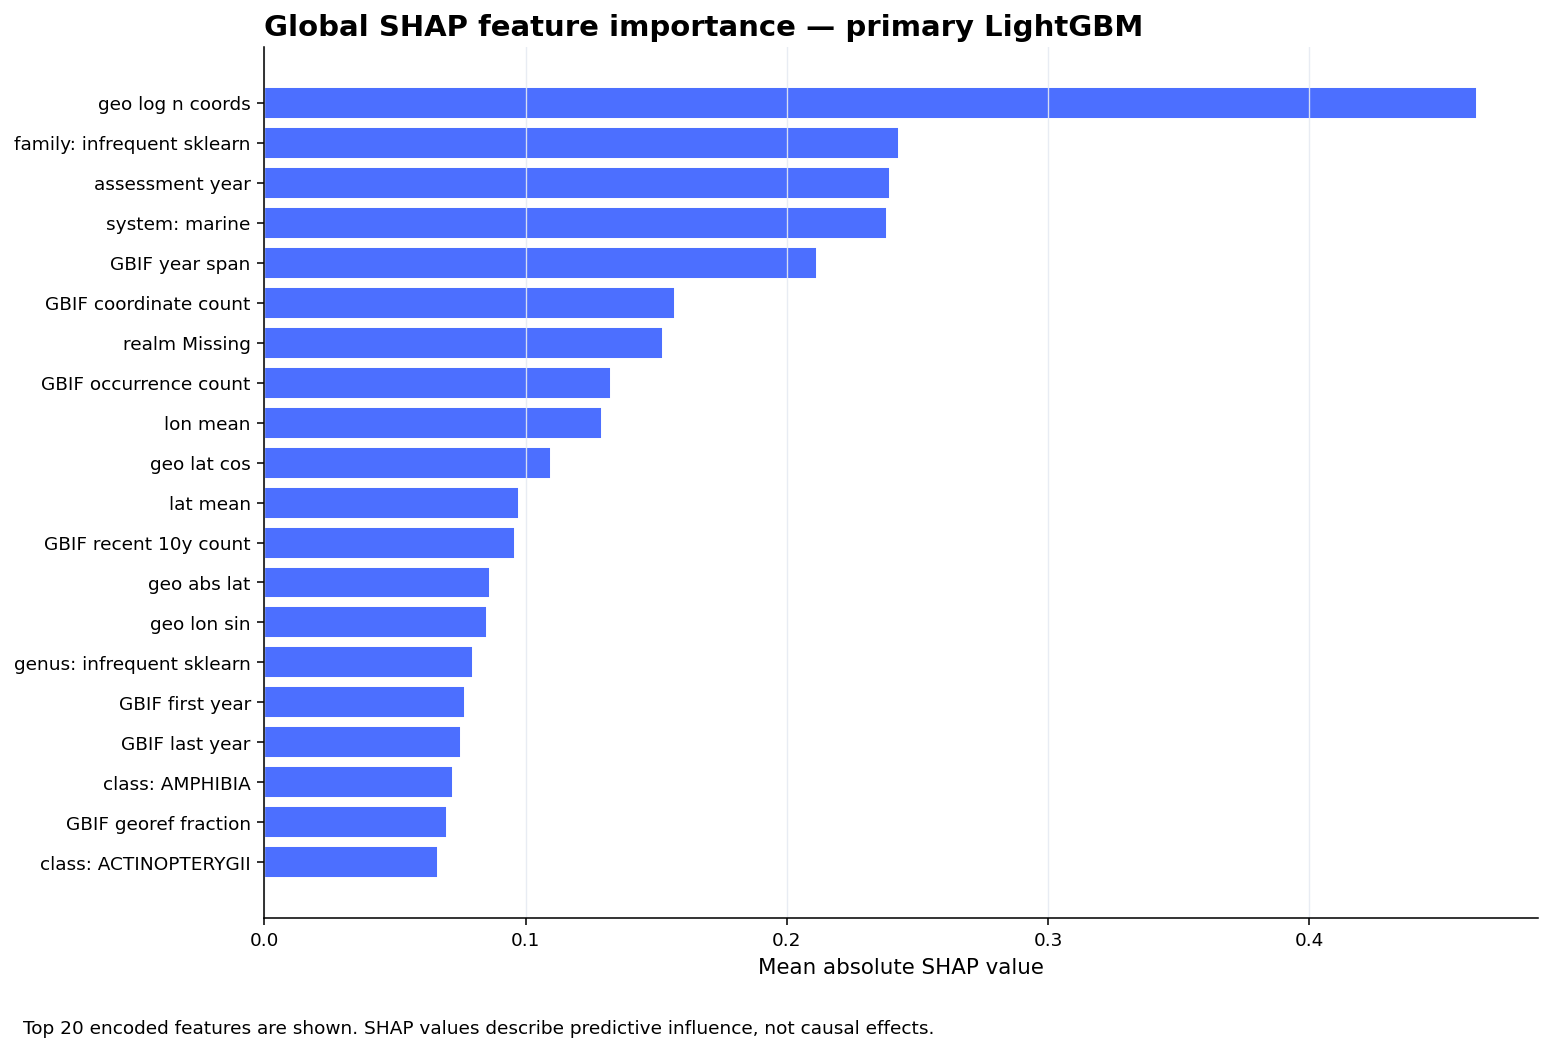

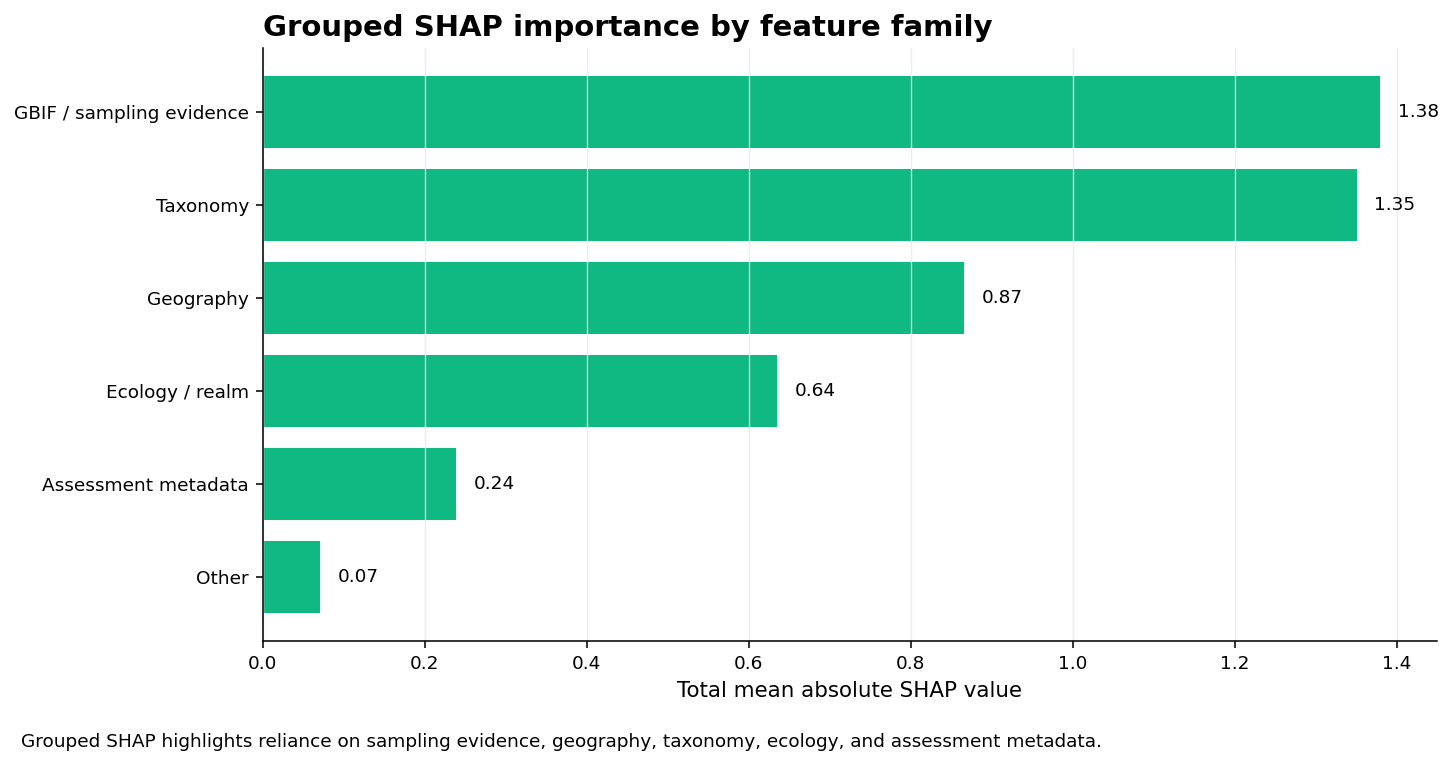

,feature,mean_abs_shap,feature_family,feature_clean
22,num__geo_log_n_coords,0.464262,GBIF / sampling evidence,geo log n coords
548,cat__family_infrequent_sklearn,0.242945,Taxonomy,family: infrequent sklearn
17,num__feat_assessment_year,0.239335,Assessment metadata,assessment year
16,num__feat_system_marine,0.238247,Ecology / realm,system: marine
7,num__feat_gbif_year_span,0.211489,GBIF / sampling evidence,GBIF year span
3,num__feat_gbif_coordinate_count,0.157287,GBIF / sampling evidence,GBIF coordinate count
1938,cat__feat_realm_Missing,0.152652,Ecology / realm,realm Missing
2,num__feat_gbif_occurrence_count,0.132829,GBIF / sampling evidence,GBIF occurrence count
19,num__lon_mean,0.129249,Geography,lon mean
27,num__geo_lat_cos,0.109708,Geography,geo lat cos


In [ ]:
# ================================================================
# CELL 26 | SHAP explainability for primary LightGBM
# ================================================================
def feature_family(name):
    s = str(name)
    if "gbif" in s or "geo_log_n_coords" in s or "geo_n_coords" in s:
        return "GBIF / sampling evidence"
    if any(k in s for k in ["lat", "lon", "country", "hemisphere", "geo_"]):
        return "Geography"
    if any(k in s for k in ["phylum", "class", "order", "family", "genus"]):
        return "Taxonomy"
    if any(k in s for k in ["system", "realm", "functional_group"]):
        return "Ecology / realm"
    if "assessment_year" in s:
        return "Assessment metadata"
    return "Other"

if SHAP_AVAILABLE:
    print("Explaining model:", PRIMARY_MODEL_NAME)
    shap_pipe = primary_model
    pre = shap_pipe.named_steps["pre"]
    clf = shap_pipe.named_steps["clf"]
    sample_n = min(1200, len(X_test))
    X_shap_raw = X_test.sample(sample_n, random_state=RANDOM_STATE)
    X_shap_trans = pre.transform(X_shap_raw)
    try:
        feature_names = pre.get_feature_names_out()
    except Exception:
        feature_names = np.array([f"feature_{i}" for i in range(X_shap_trans.shape[1])])
    X_shap_matrix = X_shap_trans.toarray() if sparse.issparse(X_shap_trans) else np.asarray(X_shap_trans)

    try:
        explainer = shap.TreeExplainer(clf)
        shap_values = explainer.shap_values(X_shap_matrix)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        shap_abs = np.abs(shap_values).mean(axis=0)
        shap_df = pd.DataFrame({"feature": feature_names, "mean_abs_shap": shap_abs})
        shap_df["feature_family"] = shap_df["feature"].map(feature_family)
        shap_df["feature_clean"] = shap_df["feature"].map(shorten_feature_name)
        shap_df = shap_df.sort_values("mean_abs_shap", ascending=False)
        shap_df.to_csv(TABLE_DIR / "shap_feature_importance_primary_lightgbm.csv", index=False)

        top = shap_df.head(20).sort_values("mean_abs_shap", ascending=True)
        fig, ax = plt.subplots(figsize=(11.2, 8.0))
        ax.barh(top["feature_clean"], top["mean_abs_shap"], color="#4C6FFF", edgecolor="white")
        ax.set_title("Global SHAP feature importance — primary LightGBM", loc="left", fontweight="bold", fontsize=15)
        ax.set_xlabel("Mean absolute SHAP value")
        ax.set_ylabel("")
        clean_axis(ax)
        fig.text(0.02, 0.02, "Top 20 encoded features are shown. SHAP values describe predictive influence, not causal effects.", fontsize=9.5)
        plt.tight_layout(rect=[0, 0.05, 1, 0.95])
        save_pubfig(fig, "figure_10A_shap_top_features_lightgbm")
        plt.show()

        fam = shap_df.groupby("feature_family", as_index=False)["mean_abs_shap"].sum()
        fam = fam.sort_values("mean_abs_shap", ascending=True)
        fam.to_csv(TABLE_DIR / "shap_grouped_feature_family_importance_primary_lightgbm.csv", index=False)
        fig, ax = plt.subplots(figsize=(10.5, 5.8))
        ax.barh(fam["feature_family"], fam["mean_abs_shap"], color="#10B981", edgecolor="white")
        for y, v in enumerate(fam["mean_abs_shap"]):
            ax.text(v + fam["mean_abs_shap"].max() * 0.015, y, f"{v:.2f}", va="center", fontsize=9.5)
        ax.set_title("Grouped SHAP importance by feature family", loc="left", fontweight="bold", fontsize=15)
        ax.set_xlabel("Total mean absolute SHAP value")
        ax.set_ylabel("")
        clean_axis(ax)
        fig.text(0.02, 0.02, "Grouped SHAP highlights reliance on sampling evidence, geography, taxonomy, ecology, and assessment metadata.", fontsize=9.5)
        plt.tight_layout(rect=[0, 0.05, 1, 0.95])
        save_pubfig(fig, "figure_10B_shap_grouped_feature_families_lightgbm")
        plt.show()

        display(shap_df.head(30))
    except Exception as e:
        print("SHAP explanation failed:", e)
else:
    print("SHAP was not available in this environment.")

## 12. Descriptive threat-label context among assessed taxa
This section is optional for the manuscript. It is descriptive only and should not be called a causal analysis. Threat labels are not used as predictors.

# **CELL 27: DESCRIPTIVE THREAT-LABEL PROFILE AMONG ASSESSED TAXA**

Threat columns found: 12


,Threat label,% threatened taxa affected,% non-threatened taxa affected,prevalence_ratio
0,Agriculture Aquaculture,52.4,19.7,2.65
1,Biological Resource Use,45.9,23.3,1.97
2,Residential Commercial Dev,31.6,12.3,2.56
3,Habitat Loss,29.2,11.9,2.44
4,Natural System Mod,26.2,9.4,2.78
5,Pollution,24.7,10.5,2.35
6,Invasive Disease,23.5,5.8,4.03
7,Climate Change,23.2,6.3,3.63
8,Energy Mining,18.3,7.1,2.57
9,Transportation,9.4,3.2,2.89


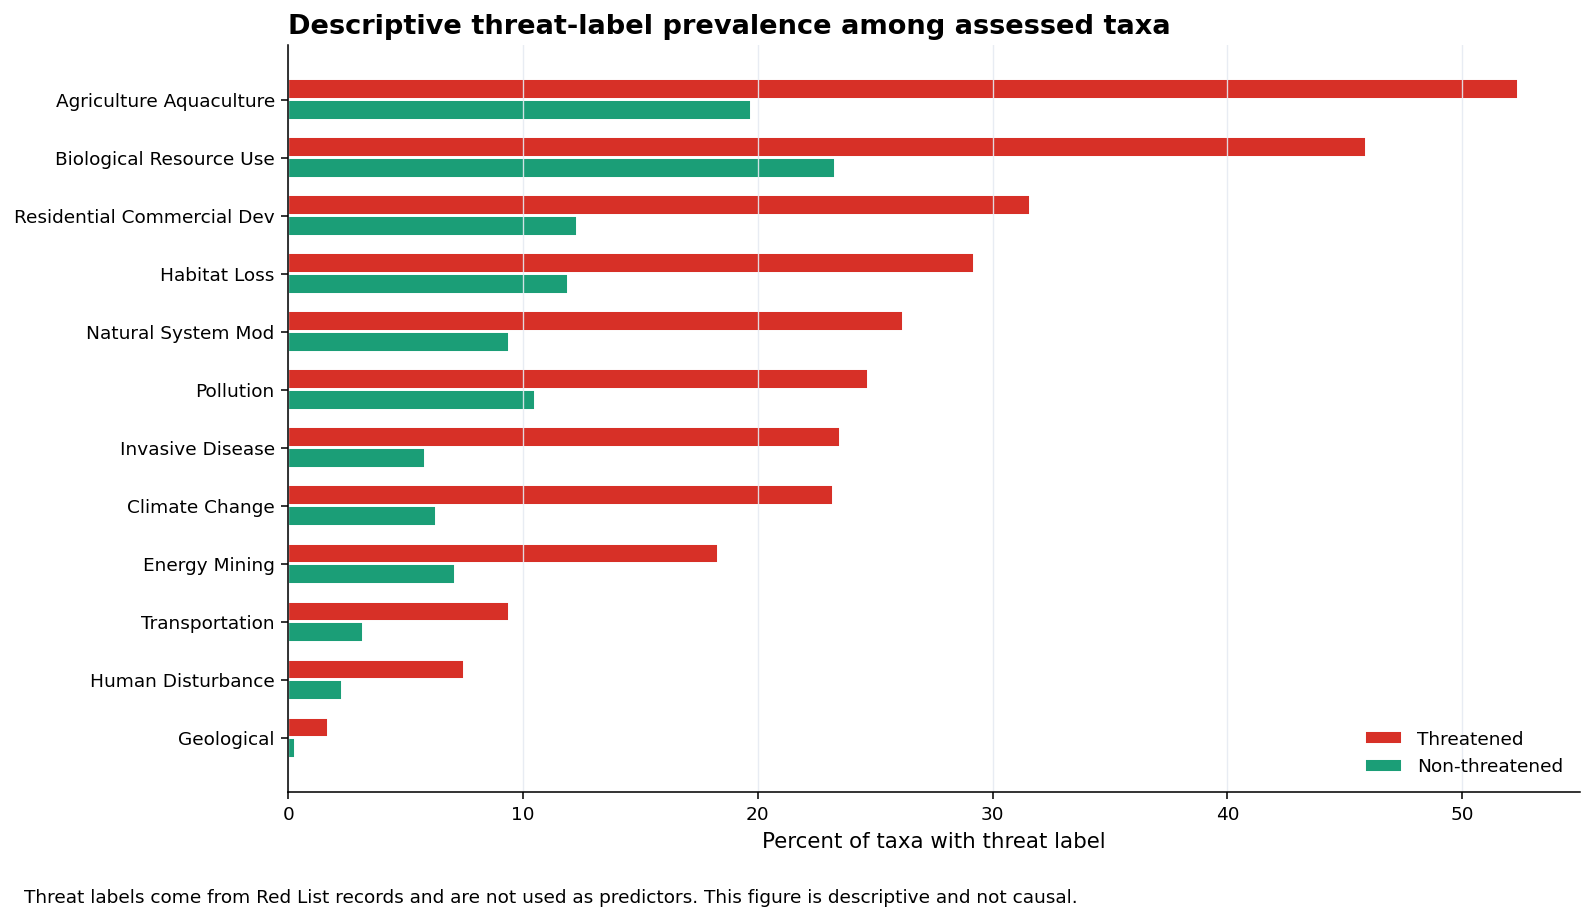

In [ ]:
# ================================================================
# CELL 27 | Descriptive threat-label profile among assessed taxa
# ================================================================
THREAT_COLS = [c for c in df_labeled.columns if c.startswith("target_threat_")]
print(f"Threat columns found: {len(THREAT_COLS)}")

def readable_threat(col):
    return col.replace("target_threat_", "").replace("_", " ").title().replace(" Generic", "").strip()

if len(THREAT_COLS) > 0:
    THREAT_LABELS = {c: readable_threat(c) for c in THREAT_COLS}
    threatened_df = df_labeled[df_labeled[TARGET].astype(int).eq(1)].copy()
    nonthreat_df = df_labeled[df_labeled[TARGET].astype(int).eq(0)].copy()

    threat_prev = (threatened_df[THREAT_COLS]
                   .apply(lambda col: col.fillna(0).astype(bool).mean())
                   .rename(THREAT_LABELS).sort_values(ascending=False))
    nonthreat_prev = (nonthreat_df[THREAT_COLS]
                      .apply(lambda col: col.fillna(0).astype(bool).mean())
                      .rename(THREAT_LABELS).reindex(threat_prev.index))
    summary = pd.DataFrame({
        "Threat label": threat_prev.index,
        "% threatened taxa affected": (threat_prev.values * 100).round(1),
        "% non-threatened taxa affected": (nonthreat_prev.values * 100).round(1),
        "prevalence_ratio": ((threat_prev.values + 0.001) / (nonthreat_prev.values + 0.001)).round(2),
    }).sort_values("% threatened taxa affected", ascending=False)
    display(summary)
    summary.to_csv(TABLE_DIR / "descriptive_threat_label_profile.csv", index=False)

    plot_df = summary.sort_values("% threatened taxa affected", ascending=True)
    fig, ax = plt.subplots(figsize=(11.5, 7.0))
    y = np.arange(len(plot_df))
    ax.barh(y + 0.18, plot_df["% threatened taxa affected"], height=0.34, color="#D73027", edgecolor="white", label="Threatened")
    ax.barh(y - 0.18, plot_df["% non-threatened taxa affected"], height=0.34, color="#1B9E77", edgecolor="white", label="Non-threatened")
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["Threat label"])
    ax.set_xlabel("Percent of taxa with threat label")
    ax.set_title("Descriptive threat-label prevalence among assessed taxa", loc="left", fontweight="bold")
    ax.legend(frameon=False, loc="lower right")
    clean_axis(ax)
    fig.text(0.02, 0.02, "Threat labels come from Red List records and are not used as predictors. This figure is descriptive and not causal.", fontsize=9.5)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    save_pubfig(fig, "figure_11_descriptive_threat_label_profile")
    plt.show()
else:
    print("No threat-label columns found. Skipping descriptive threat profile.")

# CELL 28 | Export tables, figures, and project summary as a ZIP

In [ ]:
# ================================================================
# CELL 28 | Export tables, figures, and project summary as a ZIP
# ================================================================
import shutil

project_summary = {
    "notebook": "Animal threatened-status risk prediction and Data-Deficient reassessment prioritization",
    "created": datetime.now().isoformat(timespec="seconds"),
    "main_data_file": str(BASE_PATH),
    "geo_data_file": str(GEO_PATH),
    "n_rows_main": int(df_raw.shape[0]),
    "n_rows_geo": int(geo_raw.shape[0]),
    "n_labeled_extant": int(len(df_labeled)),
    "n_data_deficient_scored": int(len(df_dd)),
    "selected_feature_set": feature_set_name,
    "selected_feature_count": int(len(selected_features)),
    "primary_model": PRIMARY_MODEL_NAME,
    "benchmark_models": list(benchmark_models.keys()),
    "final_threshold": float(FINAL_THRESHOLD),
    "test_metrics": final_test_summary.to_dict(orient="records")[0],
    "analysis_note": "Predictions are threatened-status risk proxy scores and reassessment priorities, not literal extinction probabilities."
}
with open(OUTPUT_DIR / "project_summary.json", "w") as f:
    json.dump(project_summary, f, indent=2)

zip_name = "animal_extinction_risk_outputs.zip"
if Path(zip_name).exists():
    Path(zip_name).unlink()
shutil.make_archive(zip_name.replace(".zip", ""), "zip", OUTPUT_DIR)
print("Created:", zip_name)

try:
    from google.colab import files
    files.download(zip_name)
except Exception:
    print("Download manually from the notebook file browser:", Path(zip_name).resolve())

# **CELL 29: EXPORT NOTEBOOK AS HTML**

In [ ]:
# ================================================================
# CELL 29 | Export current Colab notebook as HTML
# ================================================================

from google.colab import files
from google.colab import _message
import json
import os
from pathlib import Path

# ------------------------------------------------------------
# 1. Get the currently open Colab notebook
# ------------------------------------------------------------
notebook_data = _message.blocking_request(
    "get_ipynb",
    timeout_sec=120
)["ipynb"]

# ------------------------------------------------------------
# 2. Save temporary notebook inside Colab
# ------------------------------------------------------------
ipynb_path = "/content/Animal_Extinction_Risk_Analysis_Notebook.ipynb"
html_name = "Animal_Extinction_Risk_Analysis_Notebook"
html_path = f"/content/{html_name}.html"

with open(ipynb_path, "w", encoding="utf-8") as f:
    json.dump(notebook_data, f)

print(f"Temporary notebook saved at: {ipynb_path}")

# ------------------------------------------------------------
# 3. Convert notebook to HTML
# ------------------------------------------------------------
!jupyter nbconvert --to html "$ipynb_path" --output "$html_name" --output-dir "/content"

# ------------------------------------------------------------
# 4. Check that HTML was created
# ------------------------------------------------------------
if not os.path.exists(html_path):
    raise FileNotFoundError(f"HTML file was not created: {html_path}")

print(f"HTML file created at: {html_path}")

# ------------------------------------------------------------
# 5. Download HTML directly to laptop
# ------------------------------------------------------------
files.download(html_path)

Temporary notebook saved at: /content/Animal_Extinction_Risk_Analysis_Notebook.ipynb
[NbConvertApp] Converting notebook /content/Animal_Extinction_Risk_Analysis_Notebook.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 18 image(s).
[NbConvertApp] Writing 10464648 bytes to /content/Animal_Extinction_Risk_Analysis_Notebook.html
HTML file created at: /content/Animal_Extinction_Risk_Analysis_Notebook.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>